# CREATE KAGGLE SUBMISSION NOTEBOOK


Zusätzliche Anforderungen gemäss pdf-Dokument:
1. Trainieren Sie drei verschiedene Modelle mit unterschiedlichen Algorithmen zur Vorhersage von Gebrauchtwagenpreisen!
2. Wenden Sie bei einem Modell Grid Search und Cross Validation an, um die Hyperparamterzutunen!
3. Entwickeln Sie eine Visualisierung, mit der Sie die Performance der drei Modelle vergleichen können!
4. Überlegen Sie sich eine konkrete Empfehlung, wie Sie die Vorhersagequalität versuchen würden weiter zu steigern.
5. Fassen Sie Ihre Arbeit in 2-3 Powerpoint-Folien zusammen. Gehen Sie dabei auf Ihre Vorgehensweise und Ihre Ergebnisse ein.

### FOR GOOGLE COLLAB USERS ONLY: Mount Drive


### FOR ANACONDA USERS ONLY: Define local path


In [ ]:
path = ''

# Import Data


In [165]:
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import numpy as np
from datetime import datetime
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures, SplineTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV, RidgeCV
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error as mae, root_mean_squared_error as rmse, r2_score, make_scorer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
import xgboost as xgb
from skopt import BayesSearchCV
from sklearn.ensemble import RandomForestRegressor
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

# Required packages
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [166]:
import pandas as pd
train = pd.read_csv("train.csv")
comp_data = pd.read_csv("test.csv")

In [167]:
comp_data

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,brand,ID
0,Golf,2015,Manual,40000,Petrol,205,39.8,2.0,VW,1
1,GLA Class,2017,Automatic,30112,Petrol,145,43.5,2.0,Mercedes,4
2,1 Series,2015,Semi-Auto,19168,Petrol,145,49.6,1.6,BMW,10
3,B Class,2019,Semi-Auto,14700,Petrol,145,45.6,1.3,Mercedes,13
4,A3,2010,Manual,64800,Petrol,200,40.9,1.6,Audi,16
...,...,...,...,...,...,...,...,...,...,...
15891,4 Series,2015,Automatic,73150,Diesel,160,50.4,3.0,BMW,46738
15892,Touareg,2011,Automatic,68686,Diesel,260,38.2,3.0,VW,46744
15893,A Class,2015,Manual,37883,Diesel,20,70.6,1.5,Mercedes,46746
15894,T-Roc,2020,Manual,501,Petrol,145,44.1,1.0,VW,46748


In [168]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30857 entries, 0 to 30856
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         30857 non-null  object 
 1   year          30857 non-null  int64  
 2   price         30857 non-null  int64  
 3   transmission  30857 non-null  object 
 4   mileage       30857 non-null  int64  
 5   fuelType      30857 non-null  object 
 6   tax           30857 non-null  int64  
 7   mpg           30857 non-null  float64
 8   engineSize    30857 non-null  float64
 9   brand         30857 non-null  object 
 10  ID            30857 non-null  int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 2.6+ MB


In [169]:
comp_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15896 entries, 0 to 15895
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         15896 non-null  object 
 1   year          15896 non-null  int64  
 2   transmission  15896 non-null  object 
 3   mileage       15896 non-null  int64  
 4   fuelType      15896 non-null  object 
 5   tax           15896 non-null  int64  
 6   mpg           15896 non-null  float64
 7   engineSize    15896 non-null  float64
 8   brand         15896 non-null  object 
 9   ID            15896 non-null  int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 1.2+ MB


In [170]:
train

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand,ID
0,Tiguan,2020,29999,Automatic,2728,Diesel,145,47.9,2.0,VW,40452
1,Up,2018,8750,Manual,12500,Petrol,145,64.2,1.0,VW,33997
2,2 Series,2019,22646,Manual,123,Petrol,145,52.3,1.5,BMW,24566
3,1 Series,2019,21950,Manual,5013,Petrol,145,44.1,1.5,BMW,30438
4,X3,2013,13100,Automatic,64455,Diesel,160,50.4,2.0,BMW,22552
...,...,...,...,...,...,...,...,...,...,...,...
30852,Q3,2014,15880,Automatic,19000,Diesel,200,47.9,2.0,Audi,35289
30853,Tiguan,2018,25495,Manual,14790,Diesel,150,50.4,2.0,VW,15434
30854,A4,2015,12698,Manual,36081,Diesel,145,55.4,2.0,Audi,26408
30855,Polo,2016,7740,Manual,69548,Petrol,20,60.1,1.2,VW,17439


## Kontrolle, ob `model` im **train** und **comp_data** gleich sind

In [171]:
train['model'].nunique()

43

In [172]:
comp_data['model'].nunique()

43

In [173]:
unqiue_models = []

for i in range(0, len(train['model'].unique())):
    for j in range(0, len(comp_data['model'].unique())):
        if train['model'].unique()[i] == comp_data['model'].unique()[j]:
            unqiue_models.append(train['model'].unique()[i])

In [174]:
count = 0
for i in unqiue_models:
    count += 1


In [175]:
count

43

Wir sehen, dass wir in beiden Datasets dieselben Modelle haben.

**Dasselbe nun für das Featue *brand***:

In [176]:
train['brand'].unique()

array(['VW', 'BMW', 'Audi', 'Mercedes'], dtype=object)

In [177]:
comp_data['brand'].unique()

array(['VW', 'Mercedes', 'BMW', 'Audi'], dtype=object)

Wir sehen auch hier, dass wir sowohl im Train als auch Comp_data dieselben Kategorien haben. Dies ist nützlich, wenn wir später entweder Dummy-Encoding oder Textmining anwenden.

## Analysis Features

In [178]:
train['engineSize'].unique()

array([2. , 1. , 1.5, 2.5, 1.4, 1.2, 2.1, 1.6, 3. , 1.8, 1.3, 2.9, 4. ,
       2.2, 0. , 1.9, 2.7, 4.4, 6.2, 5.5, 3.2, 3.5, 4.7, 5.2, 4.1, 5. ,
       2.8, 3.7, 5.4])

Wir müssen herausfinden, wie das Engine Size mit dem Preis korrelliert, um zu verstehen, ob wir daraus eine Dummy-Variable oder eine numerische Variable machen. Dazu plotten wir eine Korrelationsmatrix zwischen dem `engineSize` und dem `price`.

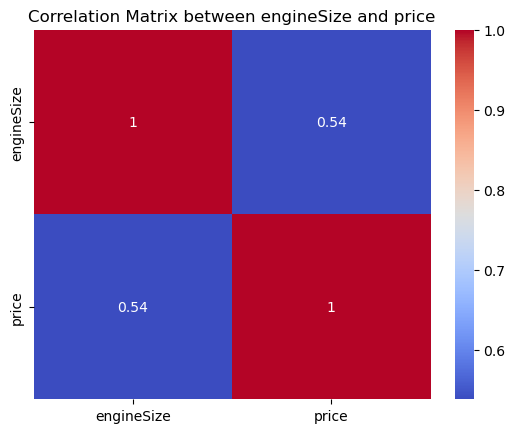

In [179]:
import seaborn as sns

import matplotlib.pyplot as plt

# Berechne die Korrelation
correlation_matrix = train[['engineSize', 'price']].corr()

# Plot die Korrelationsmatrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix between engineSize and price')
plt.show()

<Axes: title={'center': 'Scatterplot of engineSize and price'}, xlabel='engineSize', ylabel='price'>

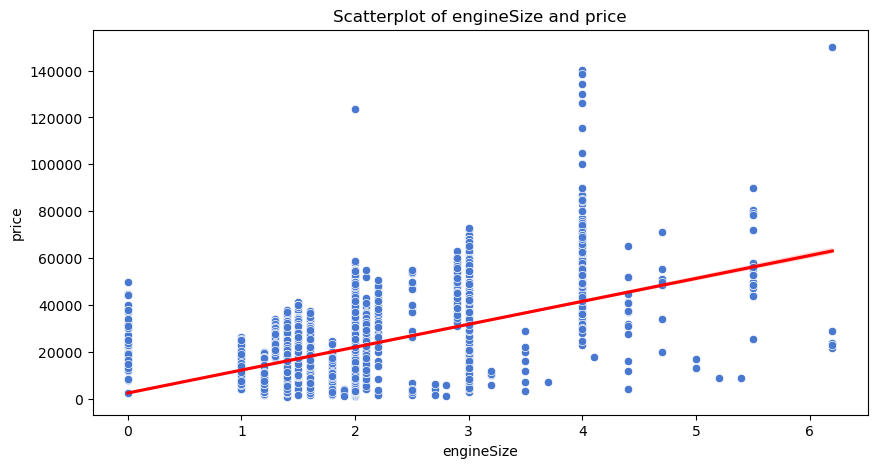

In [180]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.scatterplot(x='engineSize', y='price', data=train, ax=ax)
plt.title('Scatterplot of engineSize and price')
sns.regplot(x='engineSize', y='price', data=train, scatter=False, ax=ax, color='red')

## Analyse des Labels Preis

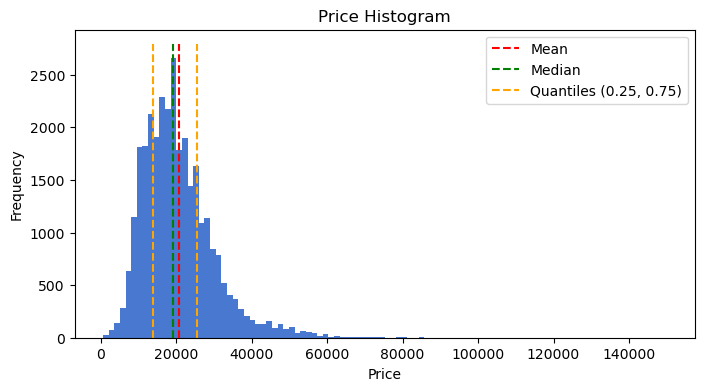

count     30857.000000
mean      20758.643452
std        9786.994817
min         650.000000
25%       13990.000000
50%       19250.000000
75%       25491.000000
max      149948.000000
Name: price, dtype: float64

In [181]:
# Recall, there is no price column in the test data

fig, ax = plt.subplots(figsize=(8, 4))

# Draw the histogram
ax.hist(train["price"], bins=100)

# Draw the mean and median lines
ymax = ax.get_ylim()[1] # Maximum of the y-axis
ax.vlines([train["price"].mean()], ymin=0, ymax=ymax, linestyles="dashed", 
          colors=["red"], label="Mean")
ax.vlines([train["price"].median()], ymin=0, ymax=ymax, linestyles="dashed",
            colors=["green"], label="Median")
# Draw 0.25, 0.75 quantiles (25% of the data is less than the 0.25th quantile, 
# 75% is less than the 0.75th quantile)
ax.vlines([train["price"].quantile(0.25), train["price"].quantile(0.75)], ymin=0, ymax=ymax,
            linestyles="dashed", colors=["orange", "orange"], label="Quantiles (0.25, 0.75)")


# ax.vlines([cars["price"].mean(), cars["price"].quantile(0.75)], ymin=0, ymax=ax.get_ylim()[1],
#             linestyles="dashed", colors=["red", "green"], label=["Mean", "Median"])
ax.legend()
ax.set_xlabel("Price")
ax.set_ylabel("Frequency")
ax.set_title("Price Histogram")

plt.show()
train["price"].describe()

Wir sehen, dass der Mittelwert ägnlich wie der Median ist. Dh. unsere Daten sind weder links- noch rechtsschief.

Wenn wir die Verteilung unserer Preisdaten untersuchen, deuten mehrere wichtige Beobachtungen darauf hin, dass keine logarithmische Transformation vorteilhaft ist:

+ Die Verteilung ist weder links- noch rechtsschief, was durch einen ähnlichen Mean wie auch Median angezeigt wird. Wir haben also kein Problem mit Modellen, die Normalität voraussetzen.
+ Das Vorhandensein starker Ausreißer kann die Regressionsanalyse unverhältnismäßig beeinflussen und zu einem ungenauen Modell führen. Jedoch haben sehen wir keine grossen Ausreisse (90% der Autos haben einen Preis kleiner als 32'444.-)

In [182]:
# Look at the 0, 0.1, 0.2, ..., 1 quantiles
train["price"].quantile([0.1*i for i in range(11)])

0.0       650.0
0.1     10298.0
0.2     12829.4
0.3     14999.0
0.4     17223.8
0.5     19250.0
0.6     21315.0
0.7     23990.0
0.8     27000.0
0.9     32444.0
1.0    149948.0
Name: price, dtype: float64

## Simple Approach: Only Dummy-Encoding

In [183]:
train

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand,ID
0,Tiguan,2020,29999,Automatic,2728,Diesel,145,47.9,2.0,VW,40452
1,Up,2018,8750,Manual,12500,Petrol,145,64.2,1.0,VW,33997
2,2 Series,2019,22646,Manual,123,Petrol,145,52.3,1.5,BMW,24566
3,1 Series,2019,21950,Manual,5013,Petrol,145,44.1,1.5,BMW,30438
4,X3,2013,13100,Automatic,64455,Diesel,160,50.4,2.0,BMW,22552
...,...,...,...,...,...,...,...,...,...,...,...
30852,Q3,2014,15880,Automatic,19000,Diesel,200,47.9,2.0,Audi,35289
30853,Tiguan,2018,25495,Manual,14790,Diesel,150,50.4,2.0,VW,15434
30854,A4,2015,12698,Manual,36081,Diesel,145,55.4,2.0,Audi,26408
30855,Polo,2016,7740,Manual,69548,Petrol,20,60.1,1.2,VW,17439


Wir definieren folgende Variablen als Dummy:
+ `model`
+ `transmission`
+ `fuelType`
+ `brand` 

Die restlichen Features sehen wir als numerisch an
Die `ID` droppen wir.

In [184]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [185]:
# Definiere die Features und das Ziel
X = train.drop(columns=['price', 'ID'], axis=1)
y = train['price']

# Split in Trainings- und Testdaten
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Numerische und kategorische Features definieren
numeric_features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
categorical_features = ['model', 'transmission', 'fuelType', 'brand']

# ColumnTransformer: Transformation für numerische und kategoriale Features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),  # Numerische Features skalieren
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)  # Kategoriale Features one-hot-encodieren
    ]
)

# Pipeline erstellen: Preprocessor + Lineare Regression
pipe = Pipeline([
    ('preprocessor', preprocessor),  # Preprocessing-Schritt
    ('regressor', LinearRegression())  # Modell
])

# Pipeline trainieren
pipe.fit(X_train, y_train)

# Vorhersagen machen
y_pred = pipe.predict(X_test)

# MSE berechnen
mse_1 = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse_1)


Mean Squared Error: 17737554.80313445


In [186]:
from datetime import datetime

train['year'] = pd.to_datetime(train['year'], format='%Y')
comp_data['year'] = pd.to_datetime(comp_data['year'], format='%Y')


# Create the age column and drop the year column
train["age"] = (datetime.now().year - train["year"].dt.year)
comp_data["age"] = (datetime.now().year - comp_data["year"].dt.year)

train.drop("year", axis=1, inplace=True)
comp_data.drop("year", axis=1, inplace=True)

In [187]:
# Definiere die Features und das Ziel
X = train.drop(columns=['price', 'ID'], axis=1)
y = train['price']

# Split in Trainings- und Testdaten
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Numerische und kategorische Features definieren
numeric_features = ['age', 'mileage', 'tax', 'mpg', 'engineSize']
categorical_features = ['model', 'transmission', 'fuelType', 'brand']

# ColumnTransformer: Transformation für numerische und kategoriale Features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),  # Numerische Features skalieren
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)  # Kategoriale Features one-hot-encodieren
    ]
)

# Pipeline erstellen: Preprocessor + Lineare Regression
pipe = Pipeline([
    ('preprocessor', preprocessor),  # Preprocessing-Schritt
    ('regressor', LinearRegression())  # Modell
])

# Pipeline trainieren
pipe.fit(X_train, y_train)

# Vorhersagen machen
y_pred = pipe.predict(X_test)

# MSE berechnen
mse_2 = mean_squared_error(y_test, y_pred)
print("Mean Squared Error Modell 1:", mse_1)
print("Mean Squared Error Modell 2:", mse_2)

Mean Squared Error Modell 1: 17737554.80313445
Mean Squared Error Modell 2: 17737550.639321573


Wir sehen, dass der MSE leicht besser ist, wenn wir `engineSize` als numerische Variable nehmen.

In [188]:
import numpy as np
np.sqrt(mse_1)

4211.597654469672

In [189]:
np.sqrt(mse_2)

4211.597160142643

## Polynomial Regression

In [190]:
X

,model,transmission,mileage,fuelType,tax,mpg,engineSize,brand,age
0,Tiguan,Automatic,2728,Diesel,145,47.9,2.0,VW,4
1,Up,Manual,12500,Petrol,145,64.2,1.0,VW,6
2,2 Series,Manual,123,Petrol,145,52.3,1.5,BMW,5
3,1 Series,Manual,5013,Petrol,145,44.1,1.5,BMW,5
4,X3,Automatic,64455,Diesel,160,50.4,2.0,BMW,11
...,...,...,...,...,...,...,...,...,...
30852,Q3,Automatic,19000,Diesel,200,47.9,2.0,Audi,10
30853,Tiguan,Manual,14790,Diesel,150,50.4,2.0,VW,6
30854,A4,Manual,36081,Diesel,145,55.4,2.0,Audi,9
30855,Polo,Manual,69548,Petrol,20,60.1,1.2,VW,8


In [191]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
"""
# Beispiel-Daten: Features (X) und Zielwert (y)
X = train.drop(columns=['price', 'ID'], axis=1)
y = train['price']

# Split in Trainings- und Testdaten
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definiere numerische und kategoriale Features
numeric_features = ['mileage', 'tax', 'mpg', 'engineSize']  # Nur diese sollen Polynom-Features bekommen
categorical_features = ['model', 'transmission', 'fuelType', 'brand']

# ColumnTransformer: Verschiedene Transformationen für numerische und kategoriale Features
preprocessor = ColumnTransformer(
    transformers=[
        ('poly', PolynomialFeatures(include_bias=False), numeric_features),  # Polynome nur für ausgewählte numerische Features
        ('cat', OneHotEncoder(), categorical_features),  # OneHot-Encoding für kategoriale Features
        ('scaler', StandardScaler(), numeric_features)  # Skalierung für numerische Features
    ]
)

# Pipeline: Preprocessing und Ridge Regression
pipe = Pipeline([
    ('preprocessor', preprocessor),  # Transformationen (Polynome, Skalierung, OneHotEncoding)
    ('regressor', Ridge())           # Ridge Regression
])

# GridSearch: Teste Polynom-Grad und Regularisierungsparameter
param_grid = {
    'preprocessor__poly__degree': range(1, 15),  # Polynom-Grad nur für ausgewählte numerische Features
    'regressor__alpha': [0.01, 0.1, 1, 10, 100]
}

# GridSearchCV mit 5-facher Kreuzvalidierung
grid_search = GridSearchCV(pipe, param_grid, scoring='neg_mean_squared_error', cv=5, verbose=2, n_jobs=2)
grid_search.fit(X_train, y_train)

# Beste Parameter
print("Beste Parameter:", grid_search.best_params_)

# Vorhersagen auf dem Testdatensatz
y_pred = grid_search.best_estimator_.predict(X_test)

# Mean Squared Error auf den Testdaten
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

"""

'\n# Beispiel-Daten: Features (X) und Zielwert (y)\nX = train.drop(columns=[\'price\', \'ID\'], axis=1)\ny = train[\'price\']\n\n# Split in Trainings- und Testdaten\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)\n\n# Definiere numerische und kategoriale Features\nnumeric_features = [\'mileage\', \'tax\', \'mpg\', \'engineSize\']  # Nur diese sollen Polynom-Features bekommen\ncategorical_features = [\'model\', \'transmission\', \'fuelType\', \'brand\']\n\n# ColumnTransformer: Verschiedene Transformationen für numerische und kategoriale Features\npreprocessor = ColumnTransformer(\n    transformers=[\n        (\'poly\', PolynomialFeatures(include_bias=False), numeric_features),  # Polynome nur für ausgewählte numerische Features\n        (\'cat\', OneHotEncoder(), categorical_features),  # OneHot-Encoding für kategoriale Features\n        (\'scaler\', StandardScaler(), numeric_features)  # Skalierung für numerische Features\n    ]\n)\n\n# Pipeli

In [192]:
# np.sqrt(mse)

In [193]:
# y_test

## New Approach

In [194]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Beispiel-Daten: Features (X) und Zielwert (y)
X = train.drop(columns=['price', 'ID'], axis=1)
y = train['price']

# Definiere numerische und kategoriale Features
numeric_features = ['mileage', 'tax', 'mpg', 'engineSize', 'age']
categorical_features = ['model', 'transmission', 'fuelType', 'brand']

# Process numeric features: scaling
scaler = StandardScaler()
X_numeric = X[numeric_features]
X_scaled = scaler.fit_transform(X_numeric)

# Process categorical features: dummy coding
encoder = OneHotEncoder(handle_unknown="ignore", drop="first")
X_categorical = X[categorical_features]
X_encoded = encoder.fit_transform(X_categorical).toarray()

In [195]:
# Combine numeric and categorical features back
X_encoded = pd.DataFrame(X_encoded, columns= encoder.get_feature_names_out())
X_scaled = pd.DataFrame(X_scaled, columns= scaler.get_feature_names_out())

X_p = pd.concat([X_scaled, X_encoded], axis=1)

# Check the result
print(f"X_processed shape: {X_p.shape}")

X_processed shape: (30857, 55)


In [196]:
X_p

,mileage,tax,mpg,engineSize,age,model_ 2 Series,model_ 3 Series,model_ 4 Series,model_ 5 Series,model_ A Class,...,model_ X3,model_ X5,transmission_Manual,transmission_Semi-Auto,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,brand_BMW,brand_Mercedes,brand_VW
0,-0.921975,0.399322,-0.439781,0.233934,-1.325889,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.484033,0.399322,0.656852,-1.620053,-0.367931,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,-1.038720,0.399322,-0.143758,-0.693059,-0.846910,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,-0.819570,0.399322,-0.695438,-0.693059,-0.846910,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,1.844382,0.646961,-0.271586,0.233934,2.026965,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30852,-0.192729,1.307333,-0.439781,0.233934,1.547986,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30853,-0.381404,0.481868,-0.271586,0.233934,-0.367931,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
30854,0.572773,0.399322,0.064804,0.233934,1.069007,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30855,2.072630,-1.664339,0.381011,-1.249255,0.590028,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [197]:
# Load our libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

# Set the default face colors to white
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'

# Now all plots will have a white background by default
plt.style.use("seaborn-v0_8-muted")

In [198]:
from sklearn.linear_model import LinearRegression

# Import mean_absolute_error from sklearn as mae for convenience
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import root_mean_squared_error as rmse 
from sklearn.metrics import r2_score # Import the R²

# Import the cross-validation utilities
from sklearn.model_selection import cross_validate, cross_val_score, KFold

# To compute our own scoring function (this will be useful to compute our 
# metrics on the price after log-scaling it)
from sklearn.metrics import make_scorer

In [199]:
# We are going to create many models, let us keep track of their performance on cross-validation
# We will use a dataframe to store the results (a dictionary would be fine, but 
# a dataframe is more convenient for plotting and computing statistics)
results = pd.DataFrame({"Model": [], "Train_CV": [], "RMSE": [], "R2": [], "MAE": []})

In [200]:
# Make a scorer that computes the given loss function (mse, mae, etc.) on the
# exponential of the predictions (since we log-scaled the y values)
# This is quite advanced, feel free to ignore it
def make_scorefunc(loss_func, exp_pred=False, greater_is_better=False):
    if exp_pred:
        def scorer(y, y_pred):
            return loss_func(np.exp(y), np.exp(y_pred))
    else:
        def scorer(y, y_pred):
            return loss_func(y, y_pred)
    return make_scorer(scorer, greater_is_better=greater_is_better)

In [201]:
# Create the scorer dictionaries for the cross_val_score function
exp_scorer = {
    "RMSE": make_scorefunc(rmse, exp_pred=True),
    "MAE": make_scorefunc(mae, exp_pred=True),
    "R2": make_scorefunc(r2_score, exp_pred=True, greater_is_better=True)
}

scorer = {
    "RMSE": make_scorefunc(rmse),
    "MAE": make_scorefunc(mae),
    "R2": make_scorefunc(r2_score, greater_is_better=True)
}

In [202]:
# Compute the metrics on the training set and on the cross-validation
def compute_metrics(model, X, y, scorer, model_name=None):
    # Extract the names from the scorer dictionary
    scorer_names = list(scorer.keys())

    # Fit the model to the training set
    model.fit(X, y)
    
    # Compute the metrics on the whole training set, and on the cross-validation
    
    # Create a dictionary for the pandas dataframe
    train_scores = {"Model": model_name, "CV_Train": "Train",}
    # Iterate over the scorers 
    for k in scorer_names:
        train_scores[k] = scorer[k](model, X, y)
    
    train_scores = pd.DataFrame(train_scores, index=[0])

    # Keep the same CV for all evaluations, for fair comparison
    cv = KFold(n_splits=5, shuffle=True, random_state=144)

    # Compute the cross-validation metrics
    cv_scores = cross_validate(model, X, y, cv=cv, 
                               scoring=scorer)
    
    # Compute means and standard deviation of the metrics on the cross-validation
    cv_scores_mean = {"Model": model_name, "CV_Train": "CV",}
    cv_scores_sd = {"Model": model_name, "CV_Train": "CV",}
    # Iterate over the scorers
    for k in scorer_names:
        cv_scores_mean[k] = cv_scores[f"test_{k}"].mean()
        cv_scores_sd[f"{k} (SD)"] = cv_scores[f"test_{k}"].std()
    
    cv_scores_mean = pd.DataFrame(cv_scores_mean, index=[0])
    cv_scores_sd = pd.DataFrame(cv_scores_sd, index=[0])

    cv_scores = pd.merge(cv_scores_mean, cv_scores_sd, on=["Model", "CV_Train"])

    # Aggregate the results
    full_scores = pd.concat([train_scores, cv_scores])

    return full_scores

In [203]:
linreg = LinearRegression()

# Compute the metrics for the linear regression model
linreg_scores = compute_metrics(linreg, X_p, y, scorer=scorer, model_name="Linear Regression")
# Compute the metrics for the log-linear model
linreg_log_scores = compute_metrics(linreg, X_p, np.log(y), scorer=exp_scorer, model_name="Log-Linear Regression")

In [204]:
results = pd.concat([results, linreg_scores, linreg_log_scores], axis=0)
results

,Model,Train_CV,RMSE,R2,MAE,CV_Train,RMSE (SD),MAE (SD),R2 (SD)
0,Linear Regression,NaN,-4122.464829,0.822569,-2648.981017,Train,NaN,NaN,NaN
0,Linear Regression,NaN,-4124.952527,0.822049,-2655.734613,CV,328.351100,50.382340,0.020441
0,Log-Linear Regression,NaN,-3431.593644,0.877056,-2063.542159,Train,NaN,NaN,NaN
0,Log-Linear Regression,NaN,-3423.336057,0.877175,-2068.087352,CV,356.664066,41.450274,0.020121


In [205]:
# Create a visualization function to help ourselves, once again this is tricky, 
# you can do plots manually, but this is more convenient
def visualize_results(results):
    # From CV, we have negative MAE/MSE
    for col in results.columns:
        if "MAE" in col or "RMSE" in col:
            results[col] = np.abs(results[col])
    # Reshape the data for RMSE, MAE, R2
    df_rmse = results.pivot(index='Model', columns='CV_Train', values='RMSE')
    df_mae = results.pivot(index='Model', columns='CV_Train', values='MAE')
    df_r2 = results.pivot(index='Model', columns='CV_Train', values='R2')

    df_rmse_sd =results.pivot(index='Model', columns='CV_Train', values='RMSE (SD)')
    df_mae_sd = results.pivot(index='Model', columns='CV_Train', values='MAE (SD)')
    df_r2_sd = results.pivot(index='Model', columns='CV_Train', values='R2 (SD)')

    all_dfs = [df_rmse, df_mae, df_r2]
    sd_dfs = [df_rmse_sd, df_mae_sd, df_r2_sd]

    # Create a figure with 2x3 subplots
    fig, axs = plt.subplots(2, 3, figsize=(16, 6))

    names = ["RMSE", "MAE", "R2"]

    # In the upper row, we plot the train MSE, MAE and R2
    for i, ax in enumerate(axs[0, :]):
        nm = names[i]
        df = all_dfs[i]
        ax.barh(df.index, df["Train"], color="C0", alpha=0.8, label="Train")
        ax.set_title(nm)
        ax.set_ylabel(nm)
        ax.set_xlabel("")
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        # ax.legend(title=False)

    # In the bottom row we plot the CV MSE, MAE and R2 (including errorbars)
    for i, ax in enumerate(axs[1, :]):
        nm = names[i]
        df = all_dfs[i]
        df_sd = sd_dfs[i]

        # Add barplot
        ax.barh(df.index, df["CV"], color="C1", alpha=0.8, label="CV")
        # Add error bars
        ax.errorbar(df["CV"], df.index, xerr=df_sd["CV"], fmt='none', color='black', capsize=5)

        ax.set_title(nm)
        ax.set_ylabel(nm)
        ax.set_xlabel("")
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        # ax.legend(title=False)°
        
    # Custom legend
    train_patch = mpatches.Patch(color="C0", alpha=0.8, label="Train")
    cv_patch = mpatches.Patch(color="C1", alpha=0.8, label="CV")
    fig.legend(handles=[train_patch, cv_patch], loc='upper center', bbox_to_anchor=(0.5, -0.05), 
           fancybox=True, shadow=True, ncol=3)
    plt.tight_layout()
    plt.show()

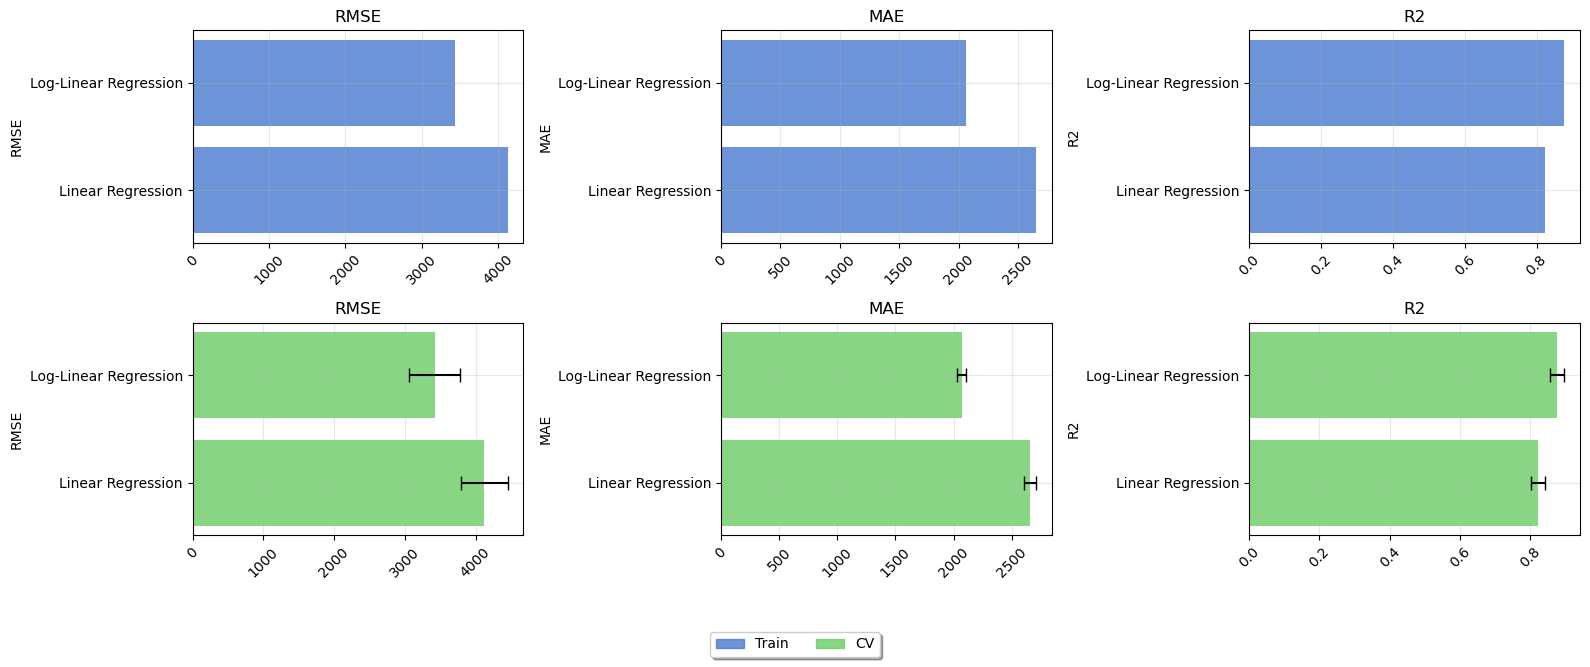

In [42]:
visualize_results(results)

Wir sehen, dass das Modell Log-Linear Regression besser performt.

Nun, da wir unsere Funktionen zur Visualisierung der Leistung eingerichtet haben, ist es an der Zeit, anspruchsvollere Modelle zu erstellen. Beginnen wir mit einer Lasso- und einer Ridge-Regression.

In [85]:
from sklearn.linear_model import Lasso, LassoCV, Ridge, RidgeCV

In [71]:
# Make our CV to select the best alpha on each model
cv = KFold(n_splits=5, shuffle=True, random_state=72)

In [72]:
from sklearn.linear_model import LassoCV, RidgeCV

# Lasso- und Ridge-Modelle mit Cross-Validation
lasso = LassoCV(cv=cv, tol=1e-2)  # Lasso mit Cross-Validation
ridge = RidgeCV(cv=cv)  # Ridge mit Cross-Validation

# Fit der Modelle auf die Daten
lasso.fit(X_p, y)
ridge.fit(X_p, y)

# Extrahiere die beste Regularisierungsstärke (Alpha)
alpha_lasso = lasso.alpha_  # Beste Alpha für Lasso
alpha_ridge = ridge.alpha_  # Beste Alpha für Ridge

print(f"Best Alpha (Lasso): {alpha_lasso}")
print(f"Best Alpha (Ridge): {alpha_ridge}")


Best Alpha (Lasso): 5.838966539835197
Best Alpha (Ridge): 1.0


In [73]:
# Set up lasso and ridge with best alpha according to CV
lasso_best = Lasso(alpha=alpha_lasso)
ridge_best = Ridge(alpha=alpha_ridge)

In [74]:
# Compute the metrics for the lasso model
lasso_scores = compute_metrics(lasso_best, X_p, y, scorer=scorer, model_name="Lasso")
# Compute the metrics for the ridge model
ridge_scores = compute_metrics(ridge_best, X_p, y, scorer=scorer, model_name="Ridge")

In [75]:
results = pd.concat([results, lasso_scores, ridge_scores], axis=0)

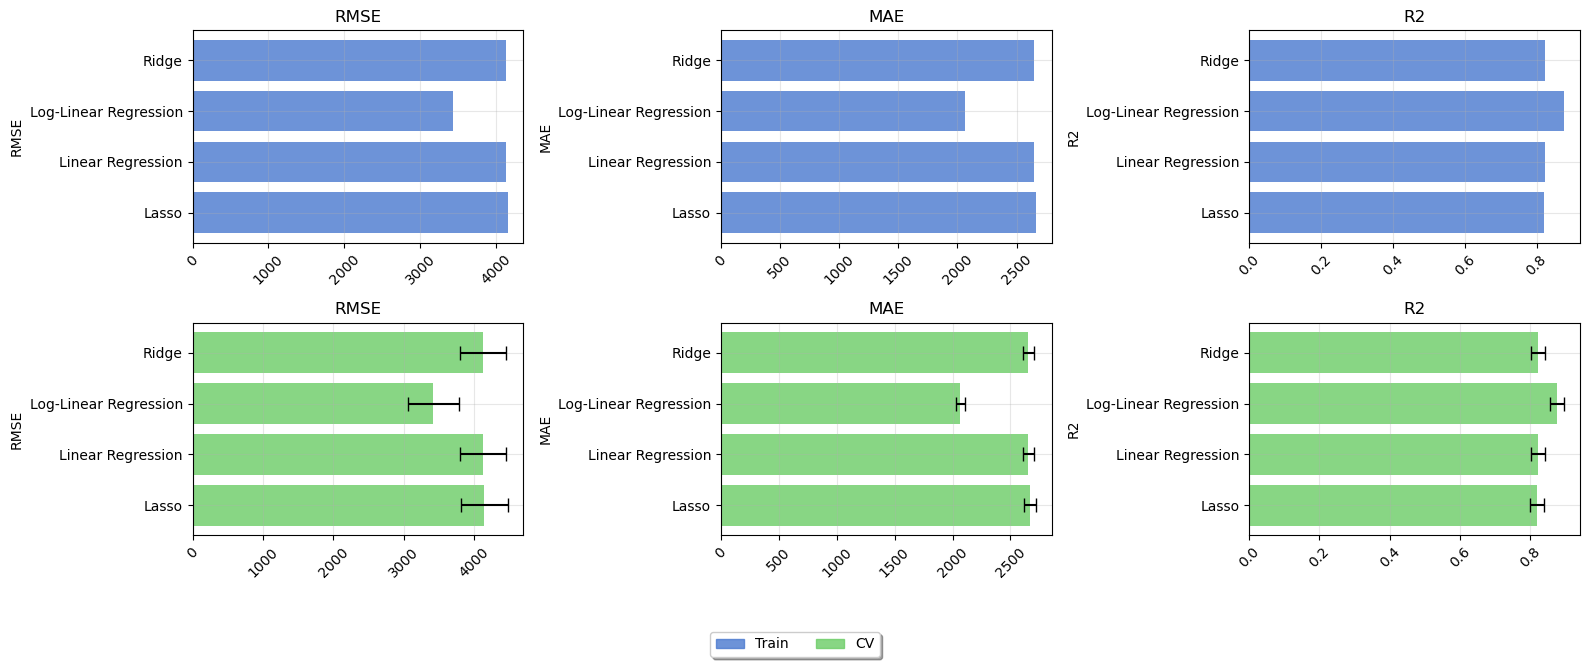

In [76]:
visualize_results(results)

In [77]:
# Let us redo the same thing, but with a log-transformed y
logy = np.log(y) # For convenience

lasso.fit(X_p, logy)
ridge.fit(X_p, logy)

# Extrahiere die beste Regularisierungsstärke (Alpha)
alpha_lasso = lasso.alpha_  # Beste Alpha für Lasso
alpha_ridge = ridge.alpha_  # Beste Alpha für Ridge

print(f"Best Alpha (Lasso): {alpha_lasso}")
print(f"Best Alpha (Ridge): {alpha_ridge}")


Best Alpha (Lasso): 0.00033015695493964755
Best Alpha (Ridge): 0.1


In [78]:
# Set up lasso and ridge with best alpha according to CV
lasso_best = Lasso(alpha=alpha_lasso)
ridge_best = Ridge(alpha=alpha_ridge)

In [79]:
# Compute the metrics for the lasso model
lasso_log_scores = compute_metrics(lasso_best, X_p, logy, scorer=exp_scorer, model_name="Log-Lasso")
# Compute the metrics for the ridge model
ridge_log_scores = compute_metrics(ridge_best, X_p, logy, scorer=exp_scorer, model_name="Log-Ridge")

In [80]:
results = pd.concat([results, lasso_log_scores, ridge_log_scores], axis=0)

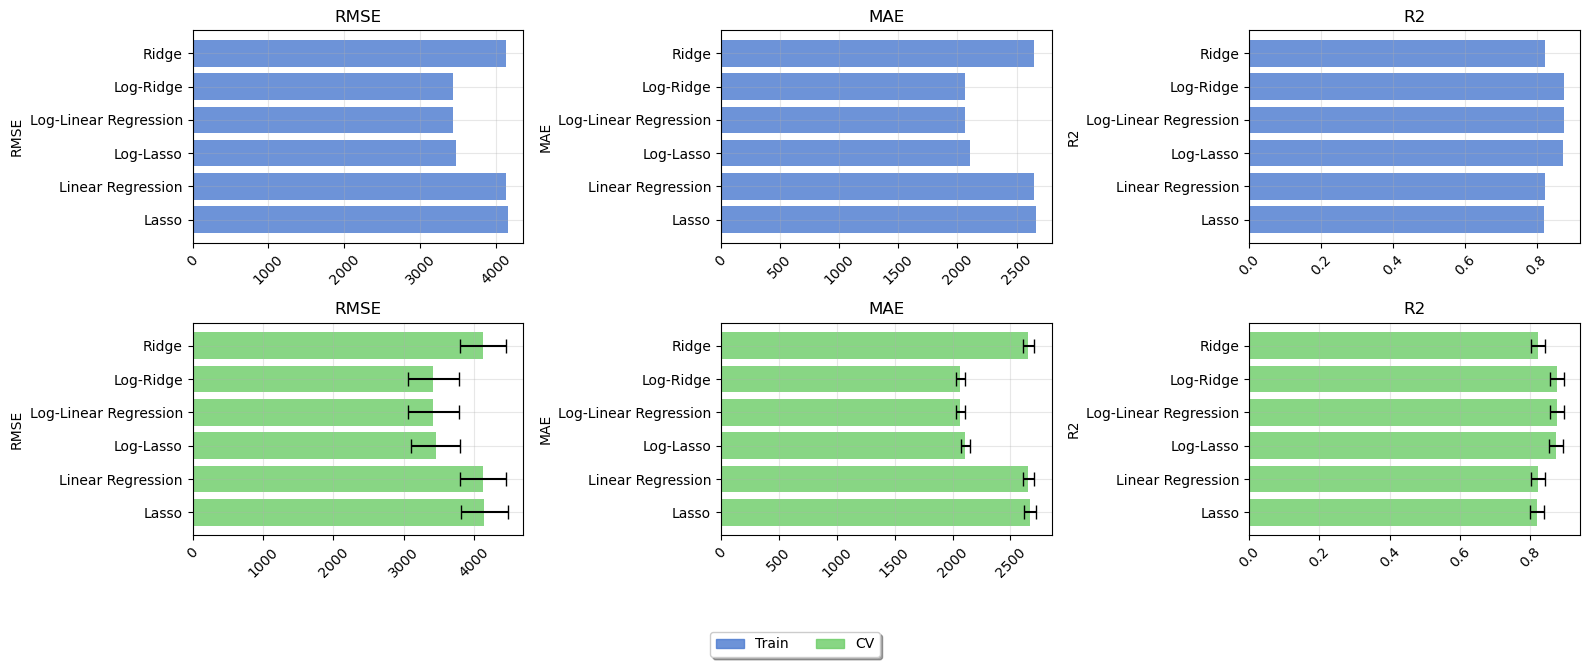

In [81]:
visualize_results(results)

In [82]:
lasso_best.fit(X_p, logy)
ridge_best.fit(X_p, logy)

Ridge(alpha=0.1)

In [83]:
# Extract the coefficients
lasso_coefs = lasso_best.coef_
ridge_coefs = ridge_best.coef_

In [84]:
threshold = 1e-2

print("Lasso, number of zero coefficients:", (lasso_coefs == 0).sum())
print("Lasso, number of non-zero coefficients:", (lasso_coefs != 0).sum())

print(f"Ridge, number of coefficients below {threshold}:", (ridge_coefs < threshold).sum())
print(f"Ridge, number of coefficients above {threshold}:", (ridge_coefs >= threshold).sum())

Lasso, number of zero coefficients: 8
Lasso, number of non-zero coefficients: 47
Ridge, number of coefficients below 0.01: 24
Ridge, number of coefficients above 0.01: 31


In [85]:
# Show the coefficients that are zero for Lasso
X_p.columns[lasso_coefs == 0]

Index(['model_ A5', 'model_ Arteon', 'model_ CL Class', 'model_ CLS Class',
       'model_ SL CLASS', 'model_ Scirocco', 'model_ Sharan',
       'model_ T-Cross'],
      dtype='object')

In [86]:
# Keep only features that are non-zero for Lasso
X_p = X_p[X_p.columns[lasso_coefs != 0]]
X_p.shape

(30857, 47)

In [44]:
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline

In [88]:
linreg = make_pipeline(SplineTransformer(), LinearRegression())
linreg.fit(X_p, logy)

Pipeline(steps=[('splinetransformer', SplineTransformer()),
                ('linearregression', LinearRegression())])

In [89]:
# Compute the metrics for the linear regression model using splines
linreg_log_scores = compute_metrics(linreg, X_p, logy, scorer=exp_scorer, model_name="Log-Linear (Splines)")

In [90]:
results = pd.concat([results, linreg_log_scores], axis=0)

In [91]:
lasso = make_pipeline(SplineTransformer(), LassoCV(cv=cv, tol=1e-2))
ridge = make_pipeline(SplineTransformer(), RidgeCV(cv=cv))

In [92]:
# Fit the models
lasso.fit(X_p, logy)
ridge.fit(X_p, logy)

# Extract the best alpha
alpha_lasso = lasso["lassocv"].alpha_
alpha_ridge = ridge["ridgecv"].alpha_

In [93]:
# Set up lasso and ridge with best alpha according to CV
lasso_best = make_pipeline(SplineTransformer(), Lasso(alpha=alpha_lasso))
ridge_best = make_pipeline(SplineTransformer(), Ridge(alpha=alpha_ridge))

In [94]:
lasso_best.fit(X_p, logy)
ridge_best.fit(X_p, logy)

Pipeline(steps=[('splinetransformer', SplineTransformer()),
                ('ridge', Ridge(alpha=0.1))])

In [95]:
# Compute the metrics for the lasso model
lasso_log_scores = compute_metrics(lasso_best, X_p, logy, scorer=exp_scorer, model_name="Log-Lasso (Splines)")
# Compute the metrics for the ridge model
ridge_log_scores = compute_metrics(ridge_best, X_p, logy, scorer=exp_scorer, model_name="Log-Ridge (Splines)")

In [96]:
results = pd.concat([results, lasso_log_scores, ridge_log_scores], axis=0)

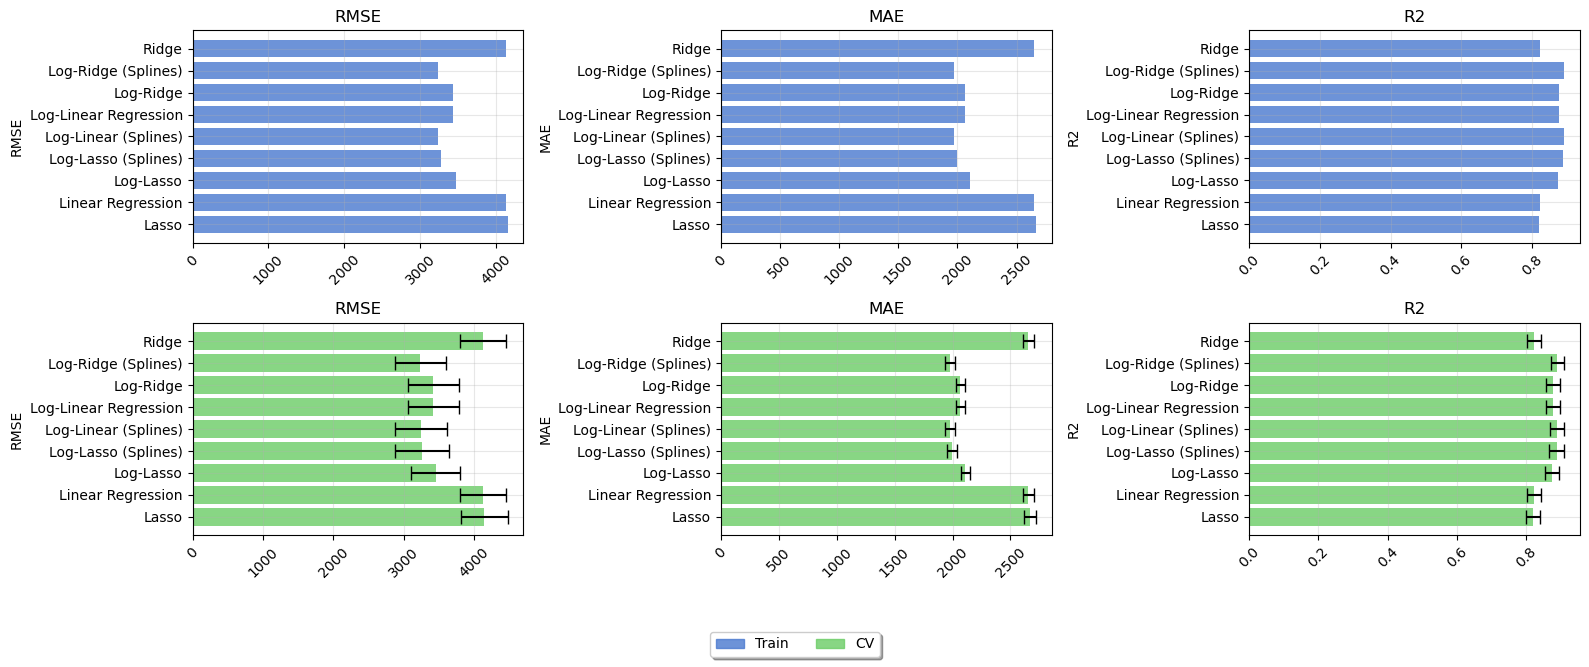

In [97]:
visualize_results(results)

In [98]:
# Sort results by cross-validation MSE
cv_results = results.loc[results["CV_Train"] == "CV", ["Model", "RMSE", "RMSE (SD)", "MAE", "MAE (SD)", "R2", "R2 (SD)"]]
cv_results.sort_values(by="RMSE", ascending=True)

,Model,RMSE,RMSE (SD),MAE,MAE (SD),R2,R2 (SD)
0,Log-Ridge (Splines),3236.646281,359.206417,1977.167109,40.438322,0.890135,0.019456
0,Log-Linear (Splines),3245.558876,364.219772,1979.419052,40.695273,0.889509,0.019854
0,Log-Lasso (Splines),3261.683567,385.833686,1995.855410,41.676216,0.888310,0.021461
0,Log-Ridge,3423.263066,356.631792,2068.082822,41.441823,0.877180,0.020118
0,Log-Linear Regression,3423.336057,356.664066,2068.087352,41.450274,0.877175,0.020121
0,Log-Lasso,3458.038536,346.410049,2110.456239,40.758539,0.874723,0.019515
0,Ridge,4124.934828,328.219748,2655.720869,50.277428,0.822051,0.020429
0,Linear Regression,4124.952527,328.351100,2655.734613,50.382340,0.822049,0.020441
0,Lasso,4149.001958,327.986370,2669.221528,50.551774,0.819971,0.020507


Wir sehen, dass wir mit dem Logrithmieren der Zielvariable bessere Ergebnisse erzielen konnten. Dann haben wir mit Ridge und Lasso diejenigen Features gefunden, die für uns nicht sehr "relevant" sind. Auch hier haben wir einmal Ridge und Lasso ohne logarithmieren der Zielvariable und einmal mit, angewendet. Mit logarithmieren erzielten wir bessere Ergebnisse. Diejenigen Features, die Log_Lasso auf 0 gestellt hat, wurden dann aus dem X-Dataframe entfernt (insgesamt 8 allesamt dummy-variablen vom Feature `model`). Schliesslich haben wir, weil dies bisher nur lineare Modelle waren, den Spline-Transformer auf unsere drei Log-Modelle angewendet.

Der Spline-Transformer führt eine Feature-Erweiterung durch, die es diesen Modellen ermöglicht, nichtlineare Zusammenhänge zu erfassen.

Damit erzielten wir nochmals deutlich bessere Resultate. Dies liefert den Hinweis darauf, dass wir mit nicht-linearen Modellen bestimmt ein noch besseres Ergebnis erzielen können.

## Nicht-lineare Modelle

In [99]:
# We are going to create many models, let us keep track of their performance on cross-validation
# We will use a dataframe to store the results (a dictionary would be fine, but 
# a dataframe is more convenient for plotting and computing statistics)
results2 = pd.DataFrame({"Model": [], "Train_CV": [], "RMSE": [], "R2": [], "MAE": []})

In [45]:
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

"""
# Beispiel-Daten: Features (X) und Zielwert (y)
X = train.drop(columns=['price', 'ID'], axis=1)
y = train['price']

# Numerische und kategoriale Features
numeric_features = ['mileage', 'tax', 'mpg', 'engineSize', 'age']
categorical_features = ['model', 'transmission', 'fuelType', 'brand']

# Liste für Ergebnisse
results_list = []

# Definiere RMSE-Scoring
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

# Loop über jedes numerische Feature
for feature in numeric_features:
    print(f"Optimizing polynomial degree for feature: {feature}")
    
    # ColumnTransformer: Unterschiedliche Transformationen für Features
    preprocessor = ColumnTransformer(
        transformers=[
            # Polynomiale Transformation nur für das aktuelle Feature
            ('poly', PolynomialFeatures(include_bias=False), [feature]),
            # Skalierung der anderen numerischen Features
            ('scaler', StandardScaler(), [col for col in numeric_features if col != feature]),
            # One-Hot-Encoding für kategorische Features
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ]
    )

    # Pipeline: Preprocessor + Lineare Regression
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('linear', LinearRegression())
    ])

    # Grid-Search über Polynomgrade (1 bis 25)
    param_grid = {'preprocessor__poly__degree': range(1, 20)}  # Nur das aktuelle Feature bekommt Polynome
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        scoring=rmse_scorer,  # Nutze RMSE-Scorer
        cv=5
    )
    grid_search.fit(X, y)  # X und y sind deine Features und Zielvariablen

    # Speichere die Ergebnisse für dieses Feature in der Liste
    best_degree = grid_search.best_params_['preprocessor__poly__degree']
    best_score = grid_search.best_score_
    results_list.append({'Feature': feature, 'Best Degree': best_degree, 'Best Score': best_score})


# Wandeln der Liste in einen DataFrame
results = pd.DataFrame(results_list)
# Ausgabe der Ergebnisse
print(results)
"""

'\n# Beispiel-Daten: Features (X) und Zielwert (y)\nX = train.drop(columns=[\'price\', \'ID\'], axis=1)\ny = train[\'price\']\n\n# Numerische und kategoriale Features\nnumeric_features = [\'mileage\', \'tax\', \'mpg\', \'engineSize\', \'age\']\ncategorical_features = [\'model\', \'transmission\', \'fuelType\', \'brand\']\n\n# Liste für Ergebnisse\nresults_list = []\n\n# Definiere RMSE-Scoring\ndef rmse(y_true, y_pred):\n    return np.sqrt(mean_squared_error(y_true, y_pred))\n\nrmse_scorer = make_scorer(rmse, greater_is_better=False)\n\n# Loop über jedes numerische Feature\nfor feature in numeric_features:\n    print(f"Optimizing polynomial degree for feature: {feature}")\n    \n    # ColumnTransformer: Unterschiedliche Transformationen für Features\n    preprocessor = ColumnTransformer(\n        transformers=[\n            # Polynomiale Transformation nur für das aktuelle Feature\n            (\'poly\', PolynomialFeatures(include_bias=False), [feature]),\n            # Skalierung der a

In [101]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures

# Beispiel-Daten: Features (X) und Zielwert (y)
X = train.drop(columns=['price', 'ID'], axis=1)
y = train['price']

# Definiere numerische Features
numeric_features = ['mileage', 'tax', 'mpg', 'engineSize', 'age']

# Beste Polynome aus dem vorherigen Ergebnis (aus der `results`-Tabelle)
best_degrees = {
    'mileage': 1,
    'tax': 1,
    'mpg': 2,
    'engineSize': 14,
    'age': 3
}

# Erstelle ein DataFrame für die numerischen Features mit den optimalen Polynomen
poly_features = pd.DataFrame()

for feature in numeric_features:
    # Hole den besten Grad für das Feature
    poly_degree = best_degrees[feature]
    # Erstelle Polynom-Features
    poly_transformer = PolynomialFeatures(degree=poly_degree, include_bias=False)
    feature_poly = poly_transformer.fit_transform(X[[feature]])
    # Hole die Namen der erzeugten Features
    feature_names = [f"{feature}^d{d}" for d in range(1, poly_degree + 1)]
    # Füge die Polynom-Features zum DataFrame hinzu
    poly_features = pd.concat(
        [poly_features, pd.DataFrame(feature_poly, columns=feature_names)], axis=1
    )

# Ausgabe der Polynom-Features
print(f"Polynom-Features Shape: {poly_features.shape}")


Polynom-Features Shape: (30857, 21)


In [102]:
poly_features

,mileage^d1,tax^d1,mpg^d1,mpg^d2,engineSize^d1,engineSize^d2,engineSize^d3,engineSize^d4,engineSize^d5,engineSize^d6,...,engineSize^d8,engineSize^d9,engineSize^d10,engineSize^d11,engineSize^d12,engineSize^d13,engineSize^d14,age^d1,age^d2,age^d3
0,2728.0,145.0,47.9,2294.41,2.0,4.00,8.000,16.0000,32.00000,64.000000,...,256.000000,512.000000,1024.000000,2048.000000,4096.000000,8192.000000,16384.000000,4.0,16.0,64.0
1,12500.0,145.0,64.2,4121.64,1.0,1.00,1.000,1.0000,1.00000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6.0,36.0,216.0
2,123.0,145.0,52.3,2735.29,1.5,2.25,3.375,5.0625,7.59375,11.390625,...,25.628906,38.443359,57.665039,86.497559,129.746338,194.619507,291.929260,5.0,25.0,125.0
3,5013.0,145.0,44.1,1944.81,1.5,2.25,3.375,5.0625,7.59375,11.390625,...,25.628906,38.443359,57.665039,86.497559,129.746338,194.619507,291.929260,5.0,25.0,125.0
4,64455.0,160.0,50.4,2540.16,2.0,4.00,8.000,16.0000,32.00000,64.000000,...,256.000000,512.000000,1024.000000,2048.000000,4096.000000,8192.000000,16384.000000,11.0,121.0,1331.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30852,19000.0,200.0,47.9,2294.41,2.0,4.00,8.000,16.0000,32.00000,64.000000,...,256.000000,512.000000,1024.000000,2048.000000,4096.000000,8192.000000,16384.000000,10.0,100.0,1000.0
30853,14790.0,150.0,50.4,2540.16,2.0,4.00,8.000,16.0000,32.00000,64.000000,...,256.000000,512.000000,1024.000000,2048.000000,4096.000000,8192.000000,16384.000000,6.0,36.0,216.0
30854,36081.0,145.0,55.4,3069.16,2.0,4.00,8.000,16.0000,32.00000,64.000000,...,256.000000,512.000000,1024.000000,2048.000000,4096.000000,8192.000000,16384.000000,9.0,81.0,729.0
30855,69548.0,20.0,60.1,3612.01,1.2,1.44,1.728,2.0736,2.48832,2.985984,...,4.299817,5.159780,6.191736,7.430084,8.916100,10.699321,12.839185,8.0,64.0,512.0


In [103]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Definiere kategoriale Features
categorical_features = ['model', 'transmission', 'fuelType', 'brand']

# Skaliere die numerischen Polynom-Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(poly_features)
X_scaled = pd.DataFrame(X_scaled, columns=poly_features.columns)

# Dummy-Kodierung der kategorialen Features
encoder = OneHotEncoder(handle_unknown="ignore", drop="first")
X_categorical = X[categorical_features]
X_encoded = encoder.fit_transform(X_categorical).toarray()
X_encoded = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out())

# Kombiniere numerische und kategoriale Features
X_p = pd.concat([X_scaled, X_encoded], axis=1)

# Überprüfe die Ergebnisse
print(f"Final Shape of Processed Features: {X_p.shape}")


Final Shape of Processed Features: (30857, 71)


In [104]:
X_p.describe()

,mileage^d1,tax^d1,mpg^d1,mpg^d2,engineSize^d1,engineSize^d2,engineSize^d3,engineSize^d4,engineSize^d5,engineSize^d6,...,model_ X3,model_ X5,transmission_Manual,transmission_Semi-Auto,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,brand_BMW,brand_Mercedes,brand_VW
count,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,...,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000
mean,-1.151348e-17,-3.569178e-17,5.825819e-17,-2.394803e-17,-1.238850e-16,-1.119110e-16,-6.079116e-17,1.899724e-17,-1.427671e-17,-2.648100e-18,...,0.011699,0.010403,0.369641,0.379330,0.013060,0.002819,0.425479,0.211686,0.264737,0.307224
std,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,...,0.107530,0.101464,0.482715,0.485228,0.113535,0.053025,0.494423,0.408510,0.441200,0.461350
min,-1.044188e+00,-1.994525e+00,-3.642219e+00,-1.323128e+00,-3.474039e+00,-1.578479e+00,-8.520086e-01,-4.632984e-01,-2.509386e-01,-1.419273e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.784290e-01,6.913603e-02,-5.945210e-01,-4.591310e-01,-6.930594e-01,-6.443780e-01,-5.087469e-01,-3.475208e-01,-2.160489e-01,-1.322379e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-2.823608e-01,3.993218e-01,-7.647969e-02,-1.426931e-01,2.339338e-01,8.214497e-02,-3.835108e-02,-9.738406e-02,-1.039138e-01,-8.748596e-02,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.711753e-01,3.993218e-01,4.684729e-01,2.433626e-01,2.339338e-01,8.214497e-02,-3.835108e-02,-9.738406e-02,-1.039138e-01,-8.748596e-02,...,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,8.546389e+00,7.580863e+00,1.095713e+01,1.829783e+01,8.020677e+00,1.438012e+01,2.338766e+01,3.332966e+01,4.184102e+01,4.817499e+01,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [105]:
linreg = LinearRegression()

# Compute the metrics for the linear regression model
linreg_scores = compute_metrics(linreg, X_p, y, scorer=scorer, model_name="Linear Regression")
# Compute the metrics for the log-linear model
linreg_log_scores = compute_metrics(linreg, X_p, np.log(y), scorer=exp_scorer, model_name="Log-Linear Regression")

In [106]:
results2 = pd.concat([results2, linreg_scores, linreg_log_scores], axis=0)
results2

,Model,Train_CV,RMSE,R2,MAE,CV_Train,RMSE (SD),MAE (SD),R2 (SD)
0,Linear Regression,NaN,-3556.637617,0.867933,-2376.253739,Train,NaN,NaN,NaN
0,Linear Regression,NaN,-3873.265810,0.839380,-2395.189355,CV,708.466469,46.333915,0.058244
0,Log-Linear Regression,NaN,-3213.028471,0.892218,-1961.355669,Train,NaN,NaN,NaN
0,Log-Linear Regression,NaN,-3218.656695,0.891340,-1967.271811,CV,355.045013,45.028924,0.019186


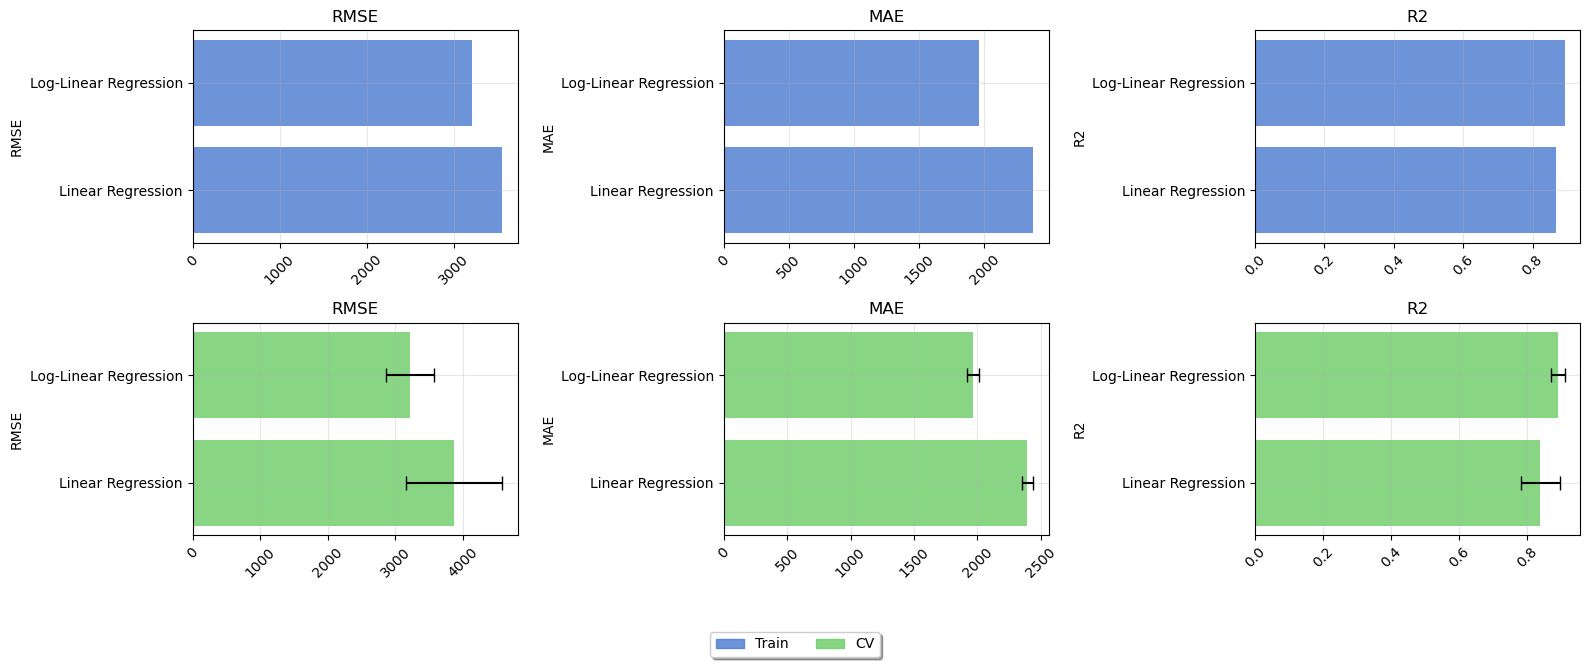

In [107]:
visualize_results(results2)

In [108]:
# Make our CV to select the best alpha on each model
cv = KFold(n_splits=5, shuffle=True, random_state=72)

In [109]:
from sklearn.linear_model import LassoCV, RidgeCV

# Lasso- und Ridge-Modelle mit Cross-Validation
lasso = LassoCV(cv=cv, tol=1e-2)  # Lasso mit Cross-Validation
ridge = RidgeCV(cv=cv)  # Ridge mit Cross-Validation

# Fit der Modelle auf die Daten
lasso.fit(X_p, y)
ridge.fit(X_p, y)

# Extrahiere die beste Regularisierungsstärke (Alpha)
alpha_lasso = lasso.alpha_  # Beste Alpha für Lasso
alpha_ridge = ridge.alpha_  # Beste Alpha für Ridge

print(f"Best Alpha (Lasso): {alpha_lasso}")
print(f"Best Alpha (Ridge): {alpha_ridge}")

Best Alpha (Lasso): 5.838966539835197
Best Alpha (Ridge): 0.1


In [110]:
from sklearn.linear_model import Lasso, Ridge
import numpy as np

# Modelle mit den besten Alphas und erhöhter Iterationsanzahl
lasso_best = Lasso(alpha=alpha_lasso, max_iter=10000, tol=1e-2)
ridge_best = Ridge(alpha=alpha_ridge, max_iter=10000)

In [111]:
# Berechnung der Metriken mit deinen Funktionen
lasso_scores = compute_metrics(lasso_best, X_p, y, scorer=scorer, model_name="Lasso")
ridge_scores = compute_metrics(ridge_best, X_p, y, scorer=scorer, model_name="Ridge")

In [112]:
results2 = pd.concat([results2, lasso_scores, ridge_scores], axis=0)

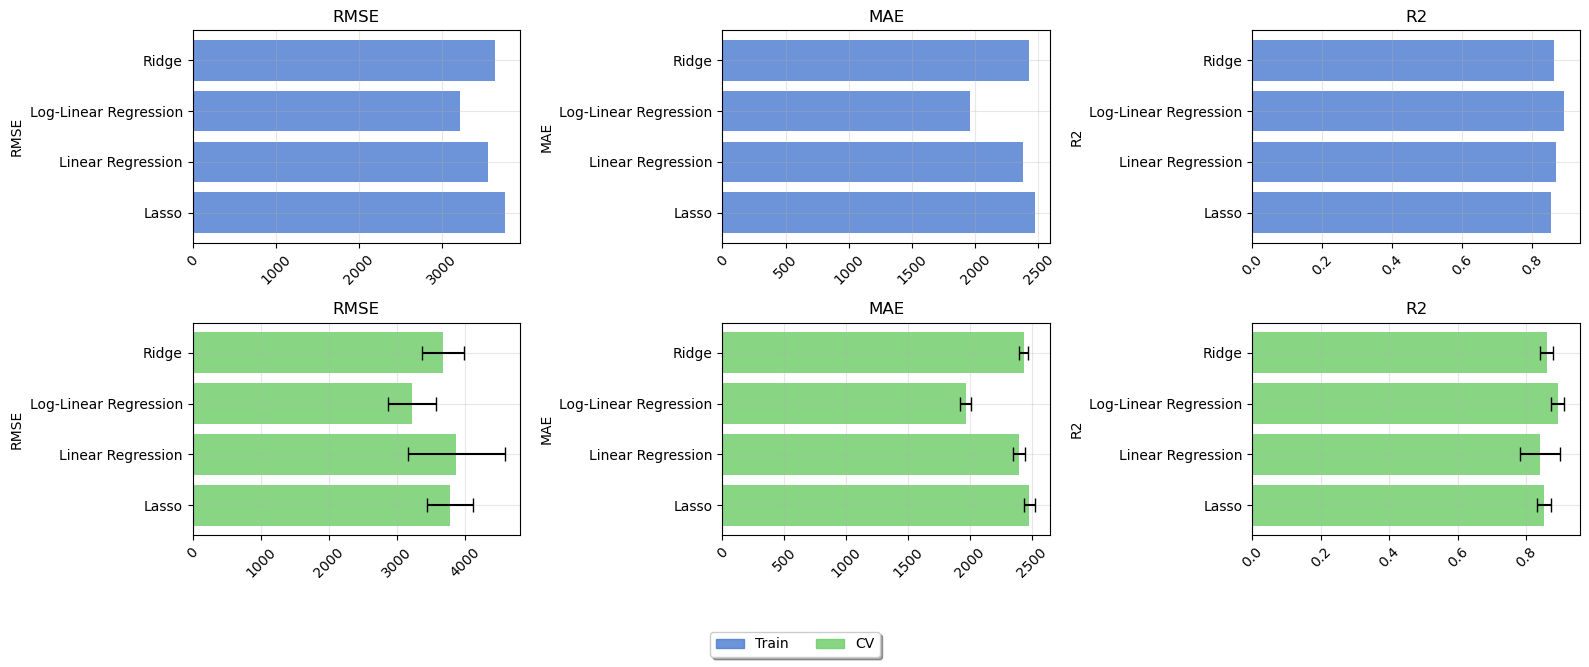

In [113]:
visualize_results(results2)

Wir sehen, dass Ridge und Lasso leicht besser performen als die Lineare Regression, jedoch schlechter als die Log-Linear Regression. Deswegen versuchen wir nun Log-Lasso und Log-Ridge anzuwenden.

In [114]:
# Let us redo the same thing, but with a log-transformed y
logy = np.log(y) # For convenience

lasso.fit(X_p, logy)
ridge.fit(X_p, logy)

# Extrahiere die beste Regularisierungsstärke (Alpha)
alpha_lasso = lasso.alpha_  # Beste Alpha für Lasso
alpha_ridge = ridge.alpha_  # Beste Alpha für Ridge

print(f"Best Alpha (Lasso): {alpha_lasso}")
print(f"Best Alpha (Ridge): {alpha_ridge}")

Best Alpha (Lasso): 0.00033015695493964755
Best Alpha (Ridge): 0.1


Wir haben genau dieselben alphas wie zuvor ohne Polynome erhalten. Ich habe ChatGPT gefragt, wieso das so ist:

Zusammenfassend könnte es mehrere Gründe geben, warum dieselben Alphas gewählt werden:

+ Hohe Korrelation zwischen den polynomialen und ursprünglichen Features.
+ Fehlender Mehrwert der polynomialen Features (z. B. durch geringe Variabilität).
+ Der Skalierungsprozess hat die Unterschiede zwischen den Features ausgeglichen.
+ Die Log-Transformation von y hat das Verhalten der Modelle beeinflusst.
+ Durch die oben genannten Prüfungen kannst du die genaue Ursache identifizieren und entsprechend handeln. Falls die polynomialen Features keinen Mehrwert bieten, solltest du überlegen, sie aus dem Dataset zu entfernen.


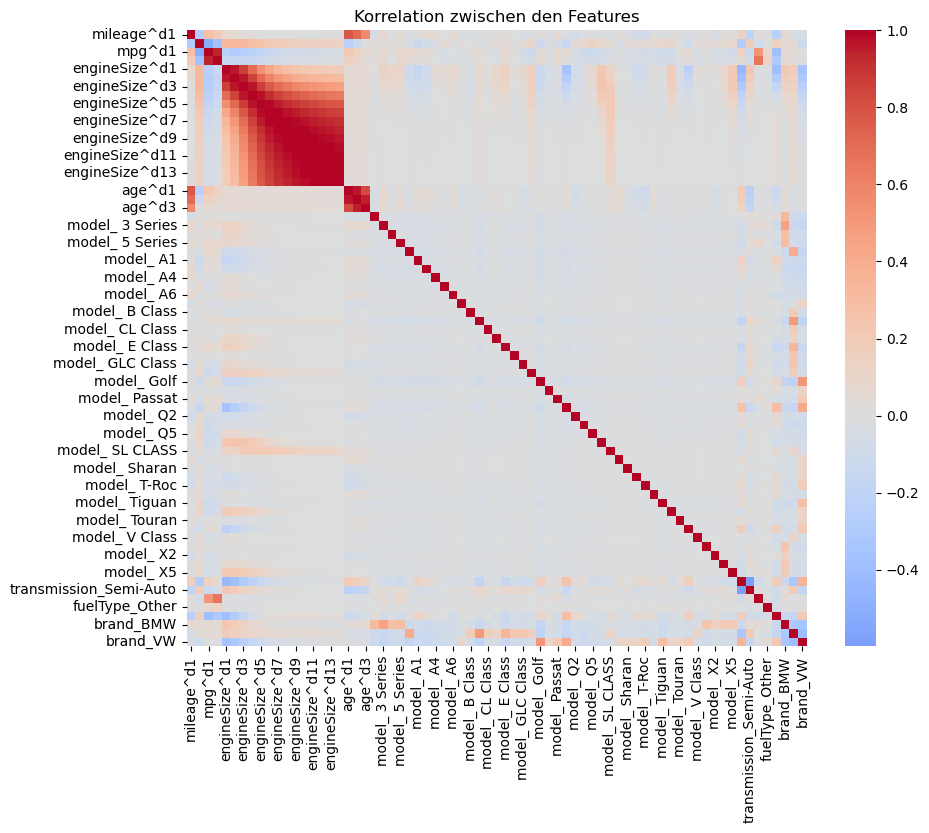

In [115]:
# Berechne die Korrelationsmatrix nach der polynomiellen Transformation
correlation_matrix = pd.DataFrame(X_p).corr()

# Visualisiere die Korrelationsmatrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", center=0)
plt.title("Korrelation zwischen den Features")
plt.show()


Wir sehen, dass es klar zum Teil eine hohe Korrelation zwischen einigen Polynomialen Features und und des ursprünglichen Polynomialen Features gibt. Jedoch haben wir auch die polynomialen Features Standardisiert, was die korrelation zwischen den Features dann natürlich erhöht. Jedoch hat mir ChatGPT gesagt, dass es kein Problem darstellt, wenn man polynomiale Features standardisiert. Es ist sogar empfehlenswert:

Die Standardisierung der polynomialen Features ist notwendig für Regularisierungsmodelle und unproblematisch. Hier ist eine empfohlene Vorgehensweise:

+ Nutze StandardScaler für numerische Features, einschließlich der polynomialen Transformationen.
+ Regularisierungsmodelle (Lasso, Ridge) sind die bessere Wahl, wenn Multikollinearität zwischen polynomialen Features besteht.
+ Verwende nach Möglichkeit Tools zur Feature-Auswahl (z. B. Lasso) oder prüfe die wichtigsten Features durch Cross-Validation.

In [116]:
# Modelle mit den besten Alphas und erhöhter Iterationsanzahl
lasso_best = Lasso(alpha=alpha_lasso, max_iter=10000, tol=1e-2)
ridge_best = Ridge(alpha=alpha_ridge, max_iter=10000)

In [117]:
# Compute the metrics for the lasso model
lasso_log_scores = compute_metrics(lasso_best, X_p, logy, scorer=exp_scorer, model_name="Log-Lasso")
# Compute the metrics for the ridge model
ridge_log_scores = compute_metrics(ridge_best, X_p, logy, scorer=exp_scorer, model_name="Log-Ridge")

In [118]:
results2 = pd.concat([results2, lasso_log_scores, ridge_log_scores], axis=0)

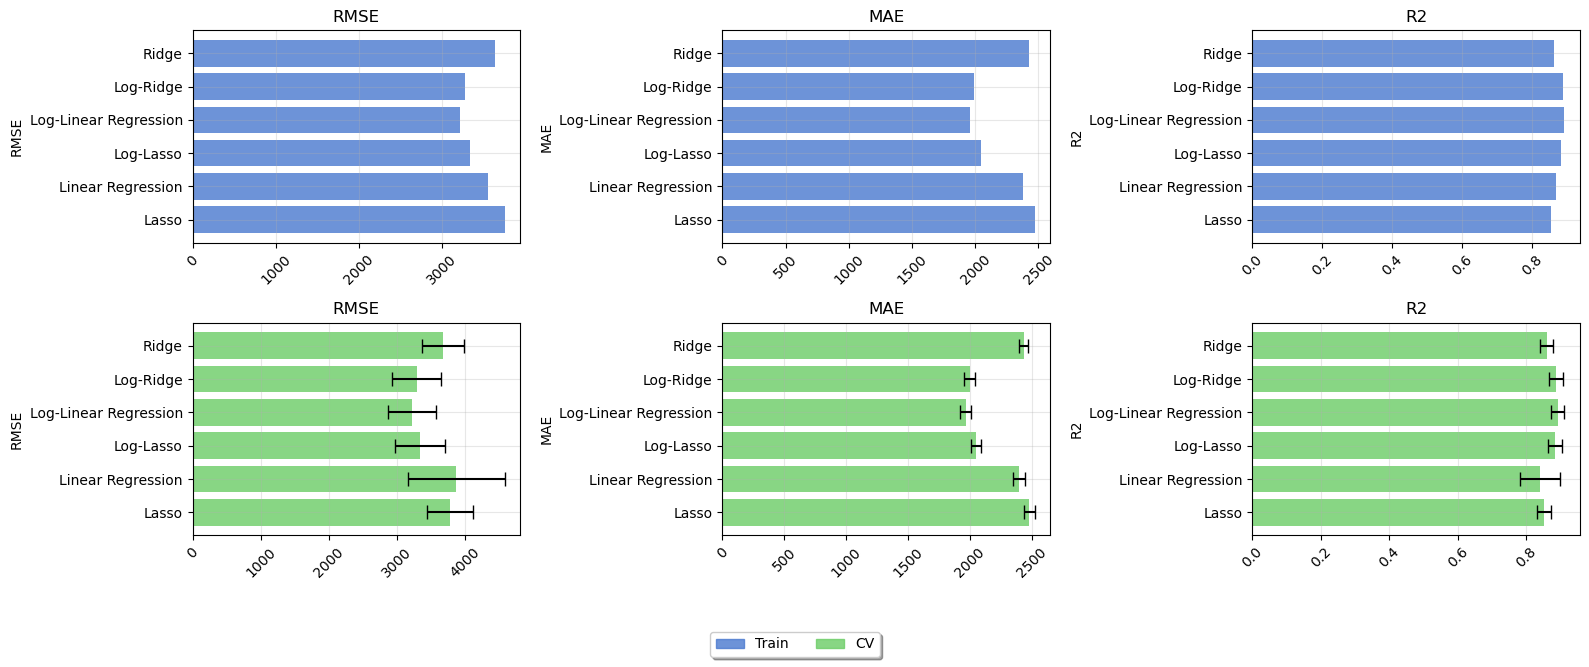

In [119]:
visualize_results(results2)

In [120]:
lasso_best.fit(X_p, logy)
ridge_best.fit(X_p, logy)

Ridge(alpha=0.1, max_iter=10000)

In [121]:
# Extract the coefficients
lasso_coefs = lasso_best.coef_
ridge_coefs = ridge_best.coef_

threshold = 1e-2

print("Lasso, number of zero coefficients:", (lasso_coefs == 0).sum())
print("Lasso, number of non-zero coefficients:", (lasso_coefs != 0).sum())

print(f"Ridge, number of coefficients below {threshold}:", (ridge_coefs < threshold).sum())
print(f"Ridge, number of coefficients above {threshold}:", (ridge_coefs >= threshold).sum())

Lasso, number of zero coefficients: 14
Lasso, number of non-zero coefficients: 57
Ridge, number of coefficients below 0.01: 33
Ridge, number of coefficients above 0.01: 38


Wir sehen, dass wir nun 14 Features haben, die durch Lasso auf 0 gestellt wurden. Diese können wir auch herausgeben:

In [122]:
# Show the coefficients that are zero for Lasso
X_p.columns[lasso_coefs == 0]

Index(['engineSize^d3', 'engineSize^d6', 'engineSize^d11', 'engineSize^d12',
       'engineSize^d13', 'engineSize^d14', 'model_ A5', 'model_ CL Class',
       'model_ CLS Class', 'model_ Scirocco', 'model_ Sharan',
       'model_ T-Cross', 'model_ TT', 'fuelType_Other'],
      dtype='object')

Es sind nach wie vor die Dummy-Variabeln gewisser Modelle. Jedoch nun auch gewisse polynomiale Features vom Feature `egineSize`. Diese nehmen wir nun heraus. Damit wir nur noch 57 Features haben.

In [123]:
# Let us redo the same thing, but with a log-transformed y
logy = np.log(y) # For convenience
logy

0        10.308919
1         9.076809
2        10.027739
3         9.996522
4         9.480368
           ...    
30852     9.672816
30853    10.146238
30854     9.449200
30855     8.954157
30856     9.595603
Name: price, Length: 30857, dtype: float64

In [124]:
# Keep only features that are non-zero for Lasso
X_p = X_p[X_p.columns[lasso_coefs != 0]]
X_p.shape

(30857, 57)

Nun nutzen wir noch den Spline-Transformator (s. Erklärung oben)

In [125]:
lasso = make_pipeline(SplineTransformer(), LassoCV(cv=cv, tol=1e-2))
ridge = make_pipeline(SplineTransformer(), RidgeCV(cv=cv))

In [126]:
# Fit the models
lasso.fit(X_p, logy)
ridge.fit(X_p, logy)

# Extract the best alpha
alpha_lasso = lasso["lassocv"].alpha_
alpha_ridge = ridge["ridgecv"].alpha_

In [127]:
# Set up lasso and ridge with best alpha according to CV
lasso_best = make_pipeline(SplineTransformer(), Lasso(alpha=alpha_lasso))
ridge_best = make_pipeline(SplineTransformer(), Ridge(alpha=alpha_ridge))

In [128]:
lasso_best.fit(X_p, logy)
ridge_best.fit(X_p, logy)

Pipeline(steps=[('splinetransformer', SplineTransformer()),
                ('ridge', Ridge(alpha=0.1))])

In [129]:
# Compute the metrics for the lasso model
lasso_log_scores = compute_metrics(lasso_best, X_p, logy, scorer=exp_scorer, model_name="Log-Lasso (Splines)")
# Compute the metrics for the ridge model
ridge_log_scores = compute_metrics(ridge_best, X_p, logy, scorer=exp_scorer, model_name="Log-Ridge (Splines)")

In [130]:
results2 = pd.concat([results2, lasso_log_scores, ridge_log_scores], axis=0)

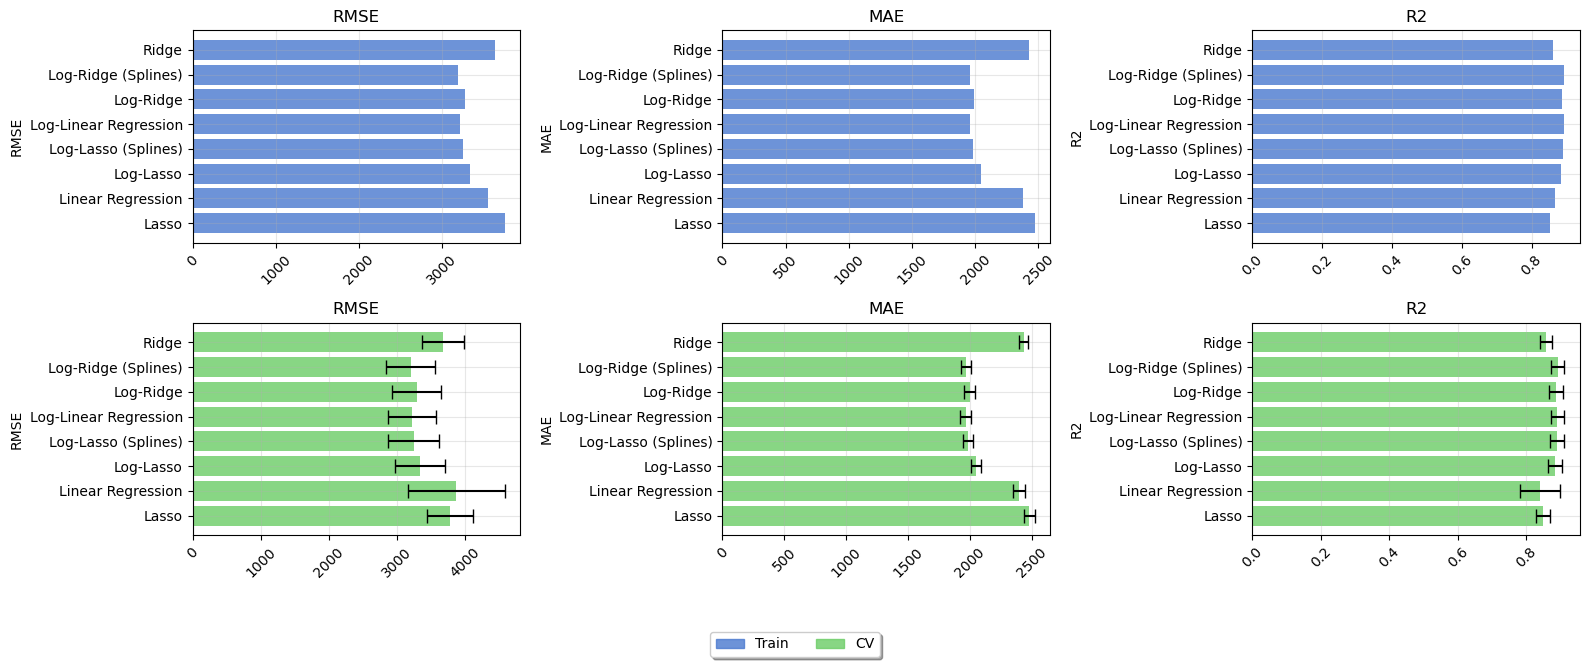

In [131]:
visualize_results(results2)

In [132]:
# Sort results by cross-validation MSE
cv_results2 = results2.loc[results2["CV_Train"] == "CV", ["Model", "RMSE", "RMSE (SD)", "MAE", "MAE (SD)", "R2", "R2 (SD)"]]
cv_results2.sort_values(by="RMSE", ascending=True)

,Model,RMSE,RMSE (SD),MAE,MAE (SD),R2,R2 (SD)
0,Log-Ridge (Splines),3200.740276,358.733536,1965.695035,41.715060,0.892535,0.019293
0,Log-Linear Regression,3218.656695,355.045013,1967.271811,45.028924,0.891340,0.019186
0,Log-Lasso (Splines),3244.420679,372.907390,1986.184553,41.579536,0.889536,0.020482
0,Log-Ridge,3289.114411,363.993397,1998.610882,43.140941,0.886536,0.020070
0,Log-Lasso,3336.702288,370.157406,2052.025428,40.117556,0.883218,0.020707
0,Ridge,3676.269411,311.873973,2432.881682,39.848038,0.858595,0.017766
0,Lasso,3779.686431,342.268058,2477.514003,44.091747,0.850462,0.020449
0,Linear Regression,3873.265810,708.466469,2395.189355,46.333915,0.839380,0.058244


In [133]:
cv_results.sort_values(by="RMSE", ascending=True)

,Model,RMSE,RMSE (SD),MAE,MAE (SD),R2,R2 (SD)
0,Log-Ridge (Splines),3236.646281,359.206417,1977.167109,40.438322,0.890135,0.019456
0,Log-Linear (Splines),3245.558876,364.219772,1979.419052,40.695273,0.889509,0.019854
0,Log-Lasso (Splines),3261.683567,385.833686,1995.855410,41.676216,0.888310,0.021461
0,Log-Ridge,3423.263066,356.631792,2068.082822,41.441823,0.877180,0.020118
0,Log-Linear Regression,3423.336057,356.664066,2068.087352,41.450274,0.877175,0.020121
0,Log-Lasso,3458.038536,346.410049,2110.456239,40.758539,0.874723,0.019515
0,Ridge,4124.934828,328.219748,2655.720869,50.277428,0.822051,0.020429
0,Linear Regression,4124.952527,328.351100,2655.734613,50.382340,0.822049,0.020441
0,Lasso,4149.001958,327.986370,2669.221528,50.551774,0.819971,0.020507


Wir sehen, dass wir ein leicht besseres Resultat mit den Polynomen erzielt haben. Jedoch ist zu bemerken, dass der Spline-Transformator eigentlich ein ähnliches Resultat erzielt wie das Bilden von Polynomialen Features. Der Hauptunterschied besteht darin, dass polynomiale Features globale Transformationen sind, die im gesamten Wertebereich eines Features gleich wirken, während Splines lokal arbeiten und für unterschiedliche Intervalle unterschiedliche Funktionen verwenden. Splines bieten in der Regel mehr Flexibilität und Stabilität, sind aber auch komplexer in der Implementierung und erfordern zusätzliche Hyperparameter wie Knotenpunkte.



Die Kombination von polynomialen Features und Splines ist vor allem dann sinnvoll, wenn:

+ Deine Daten ausreichend viele Beobachtungen haben, um die zusätzliche Modellkomplexität zu rechtfertigen.
+ Nicht alle Features beide Transformationen durchlaufen, sondern nur gezielt transformiert werden (z. B. polynomiale Transformationen für einige Features, Splines für andere).
+ Du Methoden wie Regularisierung (z. B. Ridge/Lasso) oder Feature-Selektion einsetzt, um redundante oder irrelevante Features zu eliminieren.
>In vielen Fällen ist es jedoch besser, eine der beiden Methoden auszuwählen. Splines bieten oft größere Flexibilität und bessere numerische Stabilität, während polynomiale Features einfacher zu interpretieren sind.


+ Polynomial Features:
+ + Wenn du einfache Modelle bevorzugst und davon ausgehst, dass die Beziehung zwischen den Variablen global gut durch ein Polynom beschrieben werden kann.
+ + Für niedrige Polynomgrade (z. B. Grad 2 oder 3), da diese oft ausreichen und stabil sind.
+ + Wenn Interpretierbarkeit wichtig ist (z. B. quadratische Beziehung).
+ Splines:
+ + Wenn du lokal unterschiedliche nichtlineare Beziehungen modellieren möchtest.
+ + Wenn dein Datensatz größere Schwankungen oder lokale Besonderheiten aufweist.
+ + Bei Bedarf an Flexibilität ohne die Nachteile hochgradiger Polynome.
+ + Für größere Datensätze, da sie numerisch stabiler und weniger anfällig für Overfitting sind.

**Interpretation der Resultate:**

- Polynomiale Features: Sie tragen zusätzlich zur Leistungsverbesserung bei, da sie komplexere globale nichtlineare Muster einfangen. Die Kombination von polynomialen Features und Splines führt zu einer weiteren Reduzierung des RMSE (z. B. von 3236.65 auf 3200.74).

- Regularisierung: Regularisierte Modelle (Ridge und Lasso) schneiden besser ab als einfache lineare Regressionen, da sie Overfitting reduzieren. Ridge Regression ist robuster als Lasso, was sich besonders in den RMSE-Werten zeigt.

- Logarithmische Transformation: Die logarithmische Transformation verbessert die Leistung im Vergleich zu untransformierten Modellen deutlich. Dies zeigt, dass die Zielvariable vermutlich eine nichtlineare Verteilung hat, die durch Log-Transformation besser modelliert werden kann.

**Weiteres Vorgehen:**

Alternative Modellansätze

Gradient Boosting Machines (GBMs):
- Modelle wie XGBoost, LightGBM oder CatBoost sind besonders effektiv bei komplexen, nichtlinearen Zusammenhängen und könnten eine bessere Leistung als lineare Modelle erzielen.
- Diese Modelle sind robust gegenüber irrelevanten Features und benötigen oft weniger manuelles Feature-Engineering (z. B. Splines).

Random Forests:
- Ein nichtparametrischer Ansatz, der ebenfalls gut mit nichtlinearen Beziehungen umgehen kann. Random Forests sind weniger anfällig für Überanpassung als Gradient Boosting.

## XGBoost (normal)

In [46]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np
import pandas as pd

In [213]:
comp_data.drop("ID", axis=1, inplace=True)

In [214]:
comp_data

,model,transmission,mileage,fuelType,tax,mpg,engineSize,brand,age
0,Golf,Manual,40000,Petrol,205,39.8,2.0,VW,9
1,GLA Class,Automatic,30112,Petrol,145,43.5,2.0,Mercedes,7
2,1 Series,Semi-Auto,19168,Petrol,145,49.6,1.6,BMW,9
3,B Class,Semi-Auto,14700,Petrol,145,45.6,1.3,Mercedes,5
4,A3,Manual,64800,Petrol,200,40.9,1.6,Audi,14
...,...,...,...,...,...,...,...,...,...
15891,4 Series,Automatic,73150,Diesel,160,50.4,3.0,BMW,9
15892,Touareg,Automatic,68686,Diesel,260,38.2,3.0,VW,13
15893,A Class,Manual,37883,Diesel,20,70.6,1.5,Mercedes,9
15894,T-Roc,Manual,501,Petrol,145,44.1,1.0,VW,4


In [165]:
# We are going to create many models, let us keep track of their performance on cross-validation
# We will use a dataframe to store the results (a dictionary would be fine, but 
# a dataframe is more convenient for plotting and computing statistics)
results3 = pd.DataFrame({"Model": [], "Train_CV": [], "RMSE": [], "R2": [], "MAE": []})

In [206]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Beispiel-Daten: Features (X) und Zielwert (y)
X = train.drop(columns=['price', 'ID'], axis=1)
y = train['price']

# Definiere numerische und kategoriale Features
numeric_features = ['mileage', 'tax', 'mpg', 'engineSize', 'age']
categorical_features = ['model', 'transmission', 'fuelType', 'brand']

# Process numeric features: scaling
scaler = StandardScaler()
X_numeric = X[numeric_features]
X_scaled = scaler.fit_transform(X_numeric)

# Process categorical features: dummy coding
encoder = OneHotEncoder(handle_unknown="ignore", drop="first")
X_categorical = X[categorical_features]
X_encoded = encoder.fit_transform(X_categorical).toarray()



# Combine numeric and categorical features back
X_encoded = pd.DataFrame(X_encoded, columns= encoder.get_feature_names_out())
X_scaled = pd.DataFrame(X_scaled, columns= scaler.get_feature_names_out())

X_p = pd.concat([X_scaled, X_encoded], axis=1)

# Check the result
print(f"X_processed shape: {X_p.shape}")

X_processed shape: (30857, 55)


In [215]:
comp_data_scaled = scaler.transform(comp_data[numeric_features])
comp_data_encoded = encoder.transform(comp_data[categorical_features]).toarray()

comp_data_encoded = pd.DataFrame(comp_data_encoded, columns= encoder.get_feature_names_out())
comp_data_scaled = pd.DataFrame(comp_data_scaled, columns= scaler.get_feature_names_out())

comp_data = pd.concat([comp_data_scaled, comp_data_encoded], axis=1)

In [216]:
comp_data

,mileage,tax,mpg,engineSize,age,model_ 2 Series,model_ 3 Series,model_ 4 Series,model_ 5 Series,model_ A Class,...,model_ X3,model_ X5,transmission_Manual,transmission_Semi-Auto,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,brand_BMW,brand_Mercedes,brand_VW
0,0.748407,1.389879,-0.984734,0.233934,1.069007,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.305266,0.399322,-0.735805,0.233934,0.111048,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,-0.185200,0.399322,-0.325409,-0.507661,1.069007,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
3,-0.385438,0.399322,-0.594521,-1.063857,-0.846910,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,1.859844,1.307333,-0.910728,-0.507661,3.463903,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15891,2.234057,0.646961,-0.271586,2.087920,1.069007,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
15892,2.033998,2.297890,-1.092379,2.087920,2.984924,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
15893,0.653532,-1.664339,1.087431,-0.693059,1.069007,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
15894,-1.021780,0.399322,-0.695438,-1.620053,-1.325889,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [207]:
X_p.describe()

,mileage,tax,mpg,engineSize,age,model_ 2 Series,model_ 3 Series,model_ 4 Series,model_ 5 Series,model_ A Class,...,model_ X3,model_ X5,transmission_Manual,transmission_Semi-Auto,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,brand_BMW,brand_Mercedes,brand_VW
count,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000,...,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000
mean,-1.151348e-17,-3.569178e-17,5.825819e-17,-1.238850e-16,-9.809483e-17,0.027287,0.052695,0.021486,0.022912,0.055644,...,0.011699,0.010403,0.369641,0.379330,0.013060,0.002819,0.425479,0.211686,0.264737,0.307224
std,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,0.162922,0.223427,0.145001,0.149626,0.229236,...,0.107530,0.101464,0.482715,0.485228,0.113535,0.053025,0.494423,0.408510,0.441200,0.461350
min,-1.044188e+00,-1.994525e+00,-3.642219e+00,-3.474039e+00,-1.325889e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.784290e-01,6.913603e-02,-5.945210e-01,-6.930594e-01,-8.469102e-01,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-2.823608e-01,3.993218e-01,-7.647969e-02,2.339338e-01,1.110483e-01,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.711753e-01,3.993218e-01,4.684729e-01,2.339338e-01,5.900275e-01,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,8.546389e+00,7.580863e+00,1.095713e+01,8.020677e+00,1.016961e+01,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [208]:
# Definiere den RMSE-Score als Bewertungsmetrik
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Verwende RMSE als Scorer für GridSearchCV
rmse_scorer = make_scorer(rmse, greater_is_better=False)

In [139]:
# Definiere das XGBoost-Modell
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

Beste Hyperparameter:

- 'subsample': 0.7,
- 'reg_lambda': 1,
- 'reg_alpha': 0.2,
- 'n_estimators': 500,
- 'min_child_weight': 5,
- 'max_depth': 7,
- 'learning_rate': 0.05,
- 'gamma': 0.2,
- 'colsample_bytree': 1.0,
- 'max_delta_step': 0

Score:

|Model	|Train_CV	|RMSE	|R2	|MAE	|CV_Train	|RMSE (SD)	|MAE (SD)	|R2 (SD)
|--|--|--|--|--|--|--|--|--|
|XGBoost	|NaN	|1765.958670	|0.967441	|1207.814630	|Train	|NaN	|NaN	|NaN
|XGBoost	|NaN	|2201.113090	|0.949080	|1378.080733	|CV	|265.116740	|20.438738	|0.010241


Ursprüngliches grid:

```python
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'reg_alpha': [0, 0.1, 0.2, 0.5],
    'reg_lambda': [0.5, 1, 1.5, 2],
    'min_child_weight': [1, 3, 5, 7],
    'max_delta_step': [0, 0.3, 0.5, 0.7, 1, 1.2]
}

```

Beste Hyperparameter 2:
- 'subsample': 0.8,
- 'reg_lambda': 1.25,
- 'reg_alpha': 0.15,
- 'n_estimators': 550,
- 'min_child_weight': 4,
- 'max_depth': 9,
- 'learning_rate': 0.04,
- 'gamma': 0.25,
- 'colsample_bytree': 0.8,
- 'max_delta_step': 0

Score: 
|Model	|Train_CV	|RMSE	|R2	|MAE	|CV_Train	|RMSE (SD)	|MAE (SD)	|R2 (SD)
|--|--|--|--|--|--|--|--|--|
|XGBoost	|NaN	|1765.958670	|0.967441	|1207.814630	|Train	|NaN	|NaN	|NaN
|XGBoost	|NaN	|2201.113090	|0.949080	|1378.080733	|CV	|265.116740	|20.438738	|0.010241
|2XGBoost	|NaN	|1547.418167	|0.975001	|1062.447980	|Train	|NaN	|NaN	NaN
|2XGBoost	|NaN	|2157.153134	|0.951014	|1314.195689	|CV	|284.538207	|17.27599	|0.010884

Beste Hyperparameter 3:
- 'subsample': 0.75,
- 'reg_lambda': 1.25,
- 'reg_alpha': 0.15,
- 'n_estimators': 650,
- 'min_child_weight': 3,
- 'max_depth': 9,
- 'learning_rate': 0.04,
- 'gamma': 0.15,
- 'colsample_bytree': 0.7,
- 'max_delta_step': 0

Score:
|Model	|Train_CV	|RMSE	|R2	|MAE	|CV_Train	|RMSE (SD)	|MAE (SD)	|R2 (SD)
|--|--|--|--|--|--|--|--|--|
|XGBoost	|NaN	|1765.958670	|0.967441	|1207.814630	|Train	|NaN	|NaN	|NaN
|XGBoost	|NaN	|2201.113090	|0.949080	|1378.080733	|CV	|265.116740	|20.438738	|0.010241
|2XGBoost	|NaN	|1547.418167	|0.975001	|1062.447980	|Train	|NaN	|NaN	NaN
|2XGBoost	|NaN	|2157.153134	|0.951014	|1314.195689	|CV	|284.538207	|17.27599	|0.010884
|3XGBoost	|NaN	|1448.393030	|0.978098	|1005.348184	|Train	|NaN	|NaN	|NaN
|3XGBoost	|NaN	|2133.987378	|0.952091	|1294.826100	|CV	|275.279329	|14.081223	|0.01033

Hyperparameter 4:
- 'subsample': 0.7,
- 'reg_lambda': 1.5,
- 'reg_alpha': 0.125,
- 'n_estimators': 650,
- 'min_child_weight':2,
- 'max_depth': 10,
- 'learning_rate': 0.035,
- 'gamma': 0.15,
- 'colsample_bytree': 0.75,
- 'max_delta_step': 0

Score:
|Model	|Train_CV	|RMSE	|R2	|MAE	|CV_Train	|RMSE (SD)	|MAE (SD)	|R2 (SD)
|--|--|--|--|--|--|--|--|--|
|XGBoost	|NaN	|1765.958670	|0.967441	|1207.814630	|Train	|NaN	|NaN	|NaN
|XGBoost	|NaN	|2201.113090	|0.949080	|1378.080733	|CV	|265.116740	|20.438738	|0.010241
|2XGBoost	|NaN	|1547.418167	|0.975001	|1062.447980	|Train	|NaN	|NaN	NaN
|2XGBoost	|NaN	|2157.153134	|0.951014	|1314.195689	|CV	|284.538207	|17.27599	|0.010884
|3XGBoost	|NaN	|1448.393030	|0.978098	|1005.348184	|Train	|NaN	|NaN	|NaN
|3XGBoost	|NaN	|2133.987378	|0.952091	|1294.826100	|CV	|275.279329	|14.081223	|0.01033
|4XGBoost	|NaN	|1309.633947	|0.982093	|918.064823	|Train	|NaN	|NaN	|NaN
|4XGBoost	|NaN	|2132.265516	|0.952116	|1279.196146	|CV	|286.75082	|18.192096	|0.010905

+ 1: 2201+-265 = 2'466
+ 2: 2157+-284 = 2'441
+ 3: 2133+-275 = 2'408
+ 4: 2132+-286 = 2'418

**Auswahl: Hyperparameter 3:**

Grund: RMSE ist unter Berücksichtigung der SD am geringsten.


In [140]:
"""
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
import numpy as np

# Definiere den Hyperparameter-Raum (Parameter Grid)
param_dist = {
    'n_estimators': [500, 550, 600, 650, 700, 725],
    'max_depth': [7, 8, 9, 10, 11],
    'learning_rate': [0.03, 0.035, 0.04, 0.045, 0.05, 0.06],
    'subsample': [0.7, 0.725, 0.75, 0.775],
    'colsample_bytree': [0.67, 0.7, 0.75, 0.8],
    'gamma': [0.1, 0.125, 0.15, 0.175, 0.2],
    'reg_alpha': [0.125, 0.133, 0.15, 0.163, 0.175],
    'reg_lambda': [0.75, 1, 1.175, 1.25, 1.35, 1.5],
    'min_child_weight': [2, 3, 4, 5, 6],
    'max_delta_step': [0, 0.005, 0.01, 0.05]
}

# Make our CV to select the best alpha on each model
cv = KFold(n_splits=5, shuffle=True, random_state=72)


# Definiere die RandomizedSearchCV mit Cross-Validation
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=70,  # Anzahl der zufälligen Kombinationen, die ausprobiert werden
    scoring=rmse_scorer,  # Verlustfunktion: Wir wollen den MSE minimieren
    cv=cv,  # 5-fache Cross-Validation
    verbose=2,  # Ausgabe von Fortschrittsinformationen
    random_state=42,  # Zufallszustand für Reproduzierbarkeit
    n_jobs=2,
    return_train_score=True  # Alle verfügbaren Kerne für die Berechnung verwenden
)

# Trainiere das Modell mit RandomizedSearchCV
random_search.fit(X_p, y)

# Zeige die besten Hyperparameter
print(f"Beste Hyperparameter: {random_search.best_params_}")
"""


'\nimport xgboost as xgb\nfrom sklearn.model_selection import RandomizedSearchCV\nfrom sklearn.metrics import mean_squared_error\nimport numpy as np\n\n# Definiere den Hyperparameter-Raum (Parameter Grid)\nparam_dist = {\n    \'n_estimators\': [500, 550, 600, 650, 700, 725],\n    \'max_depth\': [7, 8, 9, 10, 11],\n    \'learning_rate\': [0.03, 0.035, 0.04, 0.045, 0.05, 0.06],\n    \'subsample\': [0.7, 0.725, 0.75, 0.775],\n    \'colsample_bytree\': [0.67, 0.7, 0.75, 0.8],\n    \'gamma\': [0.1, 0.125, 0.15, 0.175, 0.2],\n    \'reg_alpha\': [0.125, 0.133, 0.15, 0.163, 0.175],\n    \'reg_lambda\': [0.75, 1, 1.175, 1.25, 1.35, 1.5],\n    \'min_child_weight\': [2, 3, 4, 5, 6],\n    \'max_delta_step\': [0, 0.005, 0.01, 0.05]\n}\n\n# Make our CV to select the best alpha on each model\ncv = KFold(n_splits=5, shuffle=True, random_state=72)\n\n\n# Definiere die RandomizedSearchCV mit Cross-Validation\nrandom_search = RandomizedSearchCV(\n    estimator=xgb_model,\n    param_distributions=param_di

In [141]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer

# Beste Hyperparameter aus RandomizedSearchCV
best_params = {
    'subsample': 0.75,
    'reg_lambda': 1.25,
    'reg_alpha': 0.15,
    'n_estimators': 650,
    'min_child_weight':3,
    'max_depth': 9,
    'learning_rate': 0.04,
    'gamma': 0.15,
    'colsample_bytree': 0.7,
    'max_delta_step': 0
}

# Definiere das XGBoost-Modell mit den besten Hyperparametern
xgb_model_best = xgb.XGBRegressor(
    objective='reg:squarederror', 
    random_state=42,
    **best_params  # Füge die besten Hyperparameter hinzu
)


In [142]:
xgb_scores = compute_metrics(xgb_model_best, X_p, y, scorer=scorer, model_name="XGBoost")

In [ ]:
results3 = pd.concat([results3, xgb_scores], axis=0)

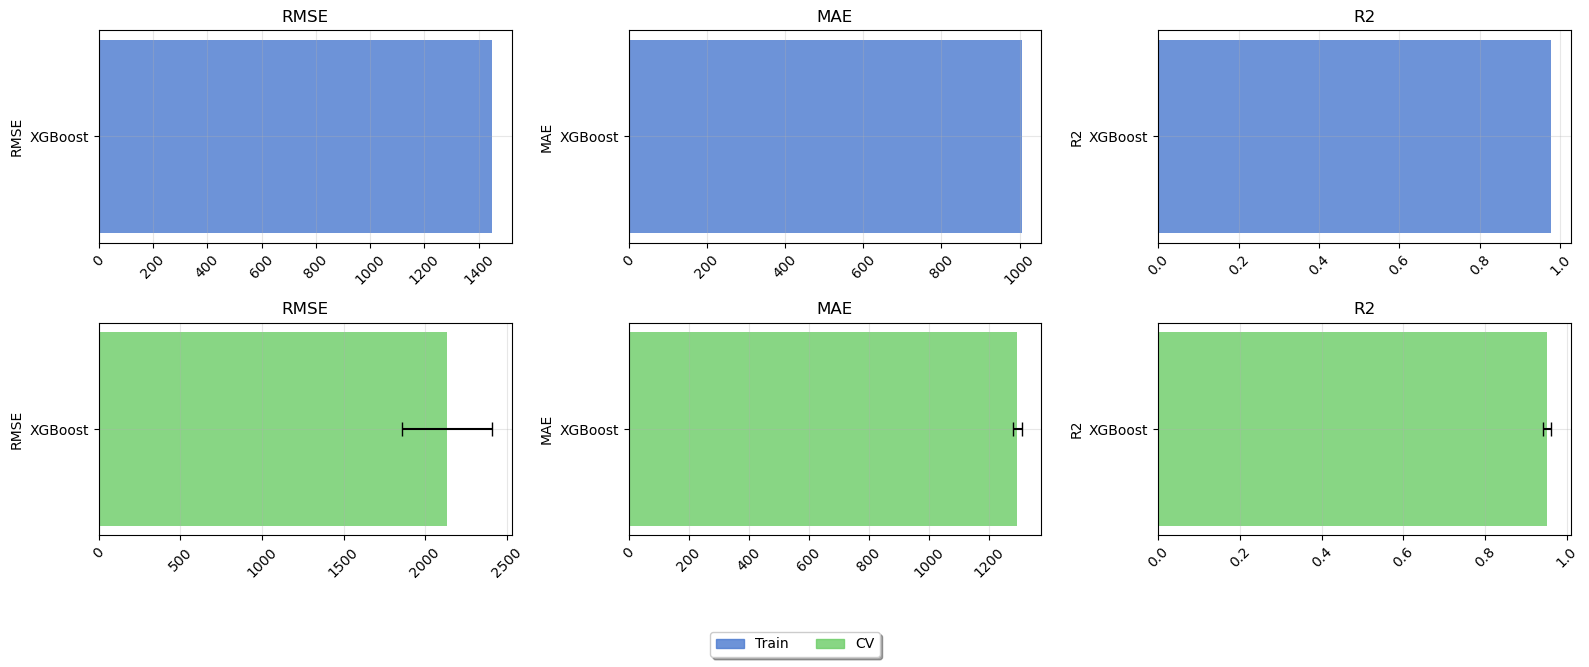

In [144]:
visualize_results(results3)

In [145]:
results3

,Model,Train_CV,RMSE,R2,MAE,CV_Train,RMSE (SD),MAE (SD),R2 (SD)
0,XGBoost,NaN,1448.393030,0.978098,1005.348184,Train,NaN,NaN,NaN
0,XGBoost,NaN,2133.987378,0.952091,1294.826100,CV,275.279329,14.081223,0.01033


## XGBoost (mit y_log)

In [146]:
# Let us redo the same thing, but with a log-transformed y
logy = np.log(y) # For convenience

In [147]:
# Definiere das XGBoost-Modell
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

Beste Hyperparameter:

- 'subsample': 0.6,
- 'reg_lambda': 0.5,
- 'reg_alpha': 0,
- 'n_estimators': 400,
- 'min_child_weight': 1,
- 'max_depth': 6,
- 'learning_rate': 0.2,
- 'gamma': 0,
- 'colsample_bytree': 0.7,
- 'max_delta_step': 0

Score: 
|Model	|Train_CV	|RMSE	|R2	|MAE	|CV_Train	|RMSE (SD)	|MAE (SD)	|R2 (SD)
|--|--|--|--|--|--|--|--|--|
|0	|Log-XGBoost	|NaN	|-1490.180725	|0.976816	|-1014.036621	|Train	|NaN	|NaN	|NaN
|0	|Log-XGBoost	|NaN	|-2158.006332	|0.950928	|-1308.467351	|CV	|306.463491	|20.742175	|0.011717

Ursprüngliches grid:

```python
param_dist = {
   'n_estimators': [300, 400, 500, 600],
    'max_depth': [3, 4, 5, 6, 7, 8, 9],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.15, 0.2, 0.25],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.65, 0.7, 0.75, 0.8],
    'gamma': [0, 0.05, 0.1, 0.2],
    'reg_alpha': [0, 0.05 0.1, 0.2],
    'reg_lambda': [0.4, 0.45, 0.5, 1, 1.5, 2],
    'min_child_weight': [0.5, 1, 1.5, 2],
    'max_delta_step': [0, 0.05, 0.1, 0.3, 0.5]
}

```

Hyperparameter 2:
- 'subsample': 0.7,
- 'reg_lambda': 0.6,
- 'reg_alpha': 0,
- 'n_estimators': 500,
- 'min_child_weight': 2,
- 'max_depth': 7,
- 'learning_rate': 0.15,
- 'gamma': 0,
- 'colsample_bytree': 0.65,
- 'max_delta_step': 0.1

Score: 
|Model	|Train_CV	|RMSE	|R2	|MAE	|CV_Train	|RMSE (SD)	|MAE (SD)	|R2 (SD)
|--|--|--|--|--|--|--|--|--|
|Log-XGBoost	|NaN	|-1490.180725	|0.976816	|-1014.036621	|Train	|NaN	|NaN	|NaN
|Log-XGBoost	|NaN	|-2158.006332	|0.950928	|-1308.467351	|CV	|306.463491	|20.742175	|0.011717
|2Log-XGBoost	|NaN	|-1546.824783	|0.975020	|-992.435677	|Train	|NaN	|NaN	|NaN
|2Log-XGBoost	|NaN	|-2145.016536	|0.951466	|-1295.899168	|CV	|315.536923	|27.531848	|0.012091

Hyperparameter 3:
- 'subsample': 0.65,
- 'reg_lambda': 0.7,
- 'reg_alpha': 0.05,
- 'n_estimators': 550,
- 'min_child_weight': 2.5,
- 'max_depth': 8,
- 'learning_rate': 0.125,
- 'gamma': 0,
- 'colsample_bytree': 0.65,
- 'max_delta_step': 0

Score: 
|Model	|Train_CV	|RMSE	|R2	|MAE	|CV_Train	|RMSE (SD)	|MAE (SD)	|R2 (SD)
|--|--|--|--|--|--|--|--|--|
|Log-XGBoost	|NaN	|-1490.180725	|0.976816	|-1014.036621	|Train	|NaN	|NaN	|NaN
|Log-XGBoost	|NaN	|-2158.006332	|0.950928	|-1308.467351	|CV	|306.463491	|20.742175	|0.011717
|2Log-XGBoost	|NaN	|-1546.824783	|0.975020	|-992.435677	|Train	|NaN	|NaN	|NaN
|2Log-XGBoost	|NaN	|-2145.016536	|0.951466	|-1295.899168	|CV	|315.536923	|27.531848	|0.012091
|3Log-XGBoost	|NaN	|-1341.226382	|0.981219	|-880.989756	Train	|NaN	|NaN	|NaN
|3Log-XGBoost	|NaN	|-2142.593669	|0.951509	|-1277.051178	|CV	|331.475165	|23.617104	|0.012832


Hyperparameter 4:
- 'subsample': 0.7,
- 'reg_lambda': 0.75,
- 'reg_alpha': 0.05,
- 'n_estimators': 500,
- 'min_child_weight': 2.25,
- 'max_depth': 8,
- 'learning_rate': 0.1,
- 'gamma': 0,
- 'colsample_bytree': 0.6,
- 'max_delta_step': 0

Score: 
|Model	|Train_CV	|RMSE	|R2	|MAE	|CV_Train	|RMSE (SD)	|MAE (SD)	|R2 (SD)
|--|--|--|--|--|--|--|--|--|
|Log-XGBoost	|NaN	|-1490.180725	|0.976816	|-1014.036621	|Train	|NaN	|NaN	|NaN
|Log-XGBoost	|NaN	|-2158.006332	|0.950928	|-1308.467351	|CV	|306.463491	|20.742175	|0.011717
|2Log-XGBoost	|NaN	|-1546.824783	|0.975020	|-992.435677	|Train	|NaN	|NaN	|NaN
|2Log-XGBoost	|NaN	|-2145.016536	|0.951466	|-1295.899168	|CV	|315.536923	|27.531848	|0.012091
|3Log-XGBoost	|NaN	|-1341.226382	|0.981219	|-880.989756	Train	|NaN	|NaN	|NaN
|3Log-XGBoost	|NaN	|-2142.593669	|0.951509	|-1277.051178	|CV	|331.475165	|23.617104	|0.012832
|4Log-XGBoost	|NaN	|-1459.312818	|0.977766	|-953.261276	|Train	|NaN	|NaN	|NaN
|4Log-XGBoost	|NaN	|-2130.056494	|0.952045	|-1271.397292	|CV	|336.933794	|24.746021	|0.013003

1: 2158+-306 = 2'464
2: 2145+-315 = 2'460
3: 2142+-331 = 2'473
4: 3130+-336 = 3'466

**Auswahl: Hyperparameter 2**


In [148]:
"""
# Definiere den Hyperparameter-Raum (Parameter Grid)
param_dist = {
    'n_estimators': [450, 500, 550, 600, 650],
    'max_depth': [6, 7, 8, 9, 10],
    'learning_rate': [0.05, 0.1, 0.125, 0.15, 0.175, 0.2],
    'subsample': [0.625, 0.65, 0.675, 0.7, 0.75],
    'colsample_bytree': [0.6, 0.625, 0.65, 0.675, 0.7],
    'gamma': [0, 0.01, 0.025, 0.05, 0.1],
    'reg_alpha': [0.025, 0.05, 0.075, 0.1],
    'reg_lambda': [0.65, 0.675, 0.7, 0.725, 0.75],
    'min_child_weight': [2, 2.25, 2.5, 2.75, 3],
    'max_delta_step': [0, 0.001, 0.01, 0.04, 0.05]
}

# Make our CV to select the best alpha on each model
cv = KFold(n_splits=5, shuffle=True, random_state=72)


# Definiere die RandomizedSearchCV mit Cross-Validation
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=70,  # Anzahl der zufälligen Kombinationen, die ausprobiert werden
    scoring=rmse_scorer,  # Verlustfunktion: Wir wollen den MSE minimieren
    cv=cv,  # 5-fache Cross-Validation
    verbose=2,  # Ausgabe von Fortschrittsinformationen
    random_state=42,  # Zufallszustand für Reproduzierbarkeit
    n_jobs=2,
    return_train_score=True  # Alle verfügbaren Kerne für die Berechnung verwenden
)

# Trainiere das Modell mit RandomizedSearchCV
random_search.fit(X_p, logy)

# Zeige die besten Hyperparameter
print(f"Beste Hyperparameter: {random_search.best_params_}")
"""

'\n# Definiere den Hyperparameter-Raum (Parameter Grid)\nparam_dist = {\n    \'n_estimators\': [450, 500, 550, 600, 650],\n    \'max_depth\': [6, 7, 8, 9, 10],\n    \'learning_rate\': [0.05, 0.1, 0.125, 0.15, 0.175, 0.2],\n    \'subsample\': [0.625, 0.65, 0.675, 0.7, 0.75],\n    \'colsample_bytree\': [0.6, 0.625, 0.65, 0.675, 0.7],\n    \'gamma\': [0, 0.01, 0.025, 0.05, 0.1],\n    \'reg_alpha\': [0.025, 0.05, 0.075, 0.1],\n    \'reg_lambda\': [0.65, 0.675, 0.7, 0.725, 0.75],\n    \'min_child_weight\': [2, 2.25, 2.5, 2.75, 3],\n    \'max_delta_step\': [0, 0.001, 0.01, 0.04, 0.05]\n}\n\n# Make our CV to select the best alpha on each model\ncv = KFold(n_splits=5, shuffle=True, random_state=72)\n\n\n# Definiere die RandomizedSearchCV mit Cross-Validation\nrandom_search = RandomizedSearchCV(\n    estimator=xgb_model,\n    param_distributions=param_dist,\n    n_iter=70,  # Anzahl der zufälligen Kombinationen, die ausprobiert werden\n    scoring=rmse_scorer,  # Verlustfunktion: Wir wollen den

In [149]:
# Beste Hyperparameter aus RandomizedSearchCV
best_params = {
    'subsample': 0.7,
    'reg_lambda': 0.6,
    'reg_alpha': 0,
    'n_estimators': 500,
    'min_child_weight': 2,
    'max_depth': 7,
    'learning_rate': 0.15,
    'gamma': 0,
    'colsample_bytree': 0.65,
    'max_delta_step': 0.1
}


# Definiere das XGBoost-Modell mit den besten Hyperparametern
xgb_model_best = xgb.XGBRegressor(
    objective='reg:squarederror', 
    random_state=42,
    **best_params  # Füge die besten Hyperparameter hinzu
)


In [150]:
xgb2_scores = compute_metrics(xgb_model_best, X_p, logy, scorer=exp_scorer, model_name="Log-XGBoost")

In [151]:
results3 = pd.concat([results3, xgb2_scores], axis=0)

In [152]:
results3

,Model,Train_CV,RMSE,R2,MAE,CV_Train,RMSE (SD),MAE (SD),R2 (SD)
0,XGBoost,NaN,1448.393030,0.978098,1005.348184,Train,NaN,NaN,NaN
0,XGBoost,NaN,2133.987378,0.952091,1294.826100,CV,275.279329,14.081223,0.010330
0,Log-XGBoost,NaN,-1546.824783,0.975020,-992.435677,Train,NaN,NaN,NaN
0,Log-XGBoost,NaN,-2145.016536,0.951466,-1295.899168,CV,315.536923,27.531848,0.012091


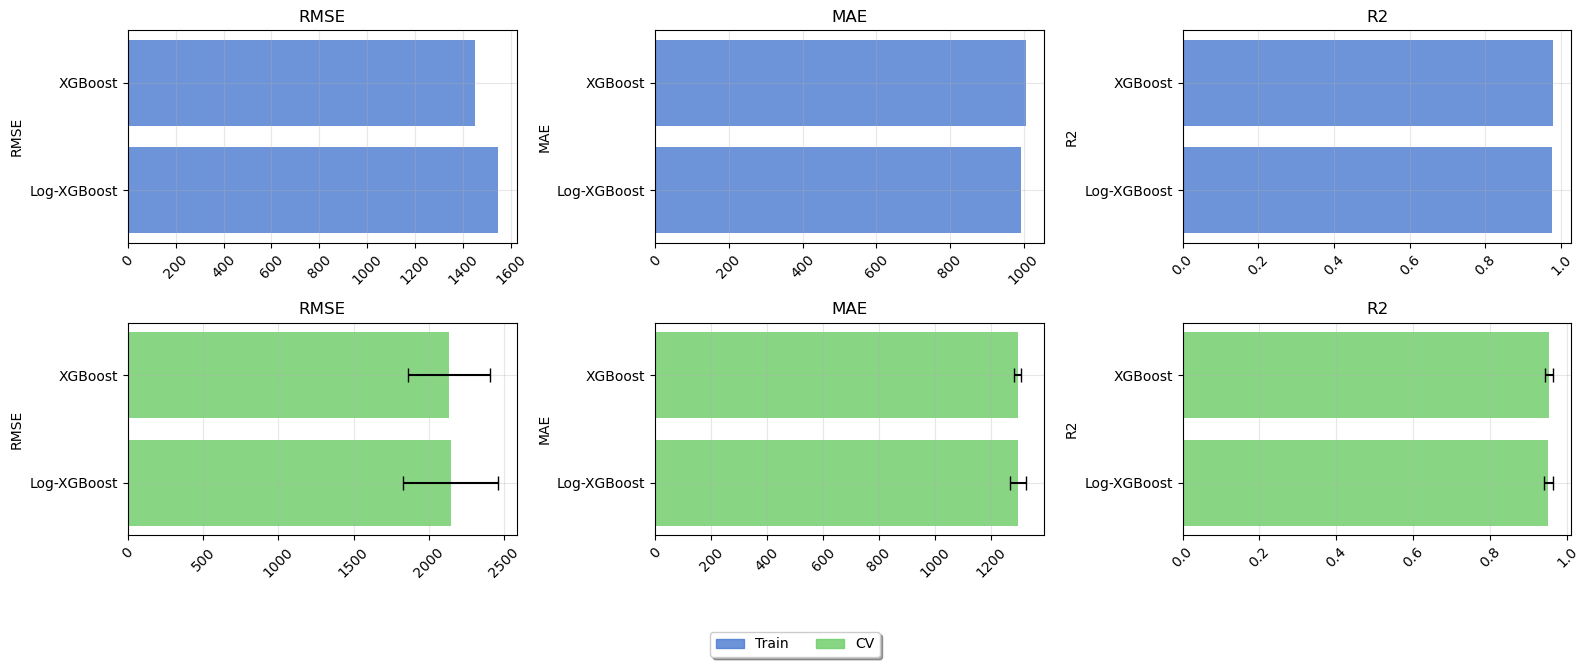

In [153]:
visualize_results(results3)

Wir sehen hier klar, wie unser XGBoost-Modell overfittet. Wir haben das Hyperparametertuning jedoch basierend auf CV angepasst.

**Schlussfolgerung**

XGBoost-Modelle sind die klare Wahl:

- Sie haben die niedrigsten RMSE- und MAE-Werte (deutlich besser als lineare Modelle).
- Das R² zeigt, dass sie 95 % der Varianz erklären können, während die besten linearen Modelle nur 89 % erklären.
- Die Ergebnisse sind stabil (geringe Standardabweichungen).


Vergleich zwischen Standard-XGBoost und Log-XGBoost:

- Beide XGBoost-Varianten performen nahezu identisch. Es gibt keinen signifikanten Vorteil durch die Logarithmierung der Zielvariable, daher ist die Verwendung des Standard-XGBoost-Modells einfacher.


Lineare Modelle sind deutlich schlechter:

- Sie haben höhere Fehlerwerte (RMSE, MAE) und erklären deutlich weniger Varianz (R²).
- Selbst das beste lineare Modell (Log-Ridge (Splines)) hat etwa 50 % höhere Fehlerwerte im Vergleich zu XGBoost.

>Empfehlung: XGBoost (ohne logarithmierte Zielvariable) sollte für deine Vorhersagen verwendet werden. Lineare Modelle können als Baseline-Modelle betrachtet werden, sind jedoch in deinem Fall nicht konkurrenzfähig.

In [154]:
X_p

,mileage,tax,mpg,engineSize,age,model_ 2 Series,model_ 3 Series,model_ 4 Series,model_ 5 Series,model_ A Class,...,model_ X3,model_ X5,transmission_Manual,transmission_Semi-Auto,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,brand_BMW,brand_Mercedes,brand_VW
0,-0.921975,0.399322,-0.439781,0.233934,-1.325889,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.484033,0.399322,0.656852,-1.620053,-0.367931,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,-1.038720,0.399322,-0.143758,-0.693059,-0.846910,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,-0.819570,0.399322,-0.695438,-0.693059,-0.846910,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,1.844382,0.646961,-0.271586,0.233934,2.026965,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30852,-0.192729,1.307333,-0.439781,0.233934,1.547986,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30853,-0.381404,0.481868,-0.271586,0.233934,-0.367931,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
30854,0.572773,0.399322,0.064804,0.233934,1.069007,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30855,2.072630,-1.664339,0.381011,-1.249255,0.590028,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


Beste Hyperparameter 1:
```python
best_params = {
    'subsample': 0.9,
    'reg_lambda': 1.9999999999999998,
    'reg_alpha': 0.29999999999999993,
    'n_estimators':800,
    'min_child_weight': 1,
    'max_depth': 11,
    'learning_rate': 0.028378432850916006,
    'gamma': 0.2,
    'colsample_bytree': 0.5,
    'max_delta_step': 0
}
```
Score:
|	Model	|Train_CV	|RMSE	|R2	|MAE	|CV_Train	|RMSE (SD)	|MAE (SD)	|R2 (SD)
|--|--|--|--|--|--|--|--|--|
|1	XGBoost-BayesSearchCV	|NaN	|1232.970537	|0.984128	|857.760076	|Train	|NaN	|NaN	|NaN
|1	XGBoost-BayesSearchCV	|NaN	|2097.668581	|0.953635	|1259.775491	|CV	|285.788296	|17.037659	|0.010746

In [47]:
from skopt import BayesSearchCV
from sklearn.model_selection import KFold
import xgboost as xgb
import numpy as np

"""
# Erstelle das XGBoost-Modell
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Definiere den Hyperparameter-Suchraum
param_space = {
    'n_estimators': (300, 600),  # Ganzzahliger Bereich
    'max_depth': (4,8),        # Ganzzahliger Bereich
    'learning_rate': (0.01, 0.06, 'log-uniform'),  # Logarithmischer Bereich für Lernrate
    'subsample': (0.6, 0.8, 'uniform'),  # Float-Werte für die Teilstichprobe
    'colsample_bytree': (0.5, 0.75, 'uniform'),  # Float-Werte für die Spaltenstichprobe
    'gamma': (0.1, 0.3, 'log-uniform'),  # Logarithmischer Bereich
    'reg_alpha': (0.2999, 2, 'log-uniform'),  # Logarithmischer Bereich
    'reg_lambda': (0.4, 4, 'log-uniform'),  # Logarithmischer Bereich
    'min_child_weight': (3, 9),  # Ganzzahliger Bereich
    'max_delta_step': (0.05, 1, 'uniform')  # Float-Werte
}

# K-Fold Cross-Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# BayesSearchCV
bayes_search = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=param_space,
    n_iter=60,  # Anzahl der Iterationen
    scoring=rmse_scorer,  # RMSE als Bewertungsmaßstab
    cv=cv,
    n_jobs=2,
    verbose=2,
    random_state=42
)

# Training
bayes_search.fit(X_p, y)

# Ergebnisse
print("Beste Hyperparameter:", bayes_search.best_params_)
print("Niedrigstes RMSE:", -bayes_search.best_score_)
"""


'\n# Erstelle das XGBoost-Modell\nxgb_model = xgb.XGBRegressor(objective=\'reg:squarederror\', random_state=42)\n\n# Definiere den Hyperparameter-Suchraum\nparam_space = {\n    \'n_estimators\': (300, 600),  # Ganzzahliger Bereich\n    \'max_depth\': (4,8),        # Ganzzahliger Bereich\n    \'learning_rate\': (0.01, 0.06, \'log-uniform\'),  # Logarithmischer Bereich für Lernrate\n    \'subsample\': (0.6, 0.8, \'uniform\'),  # Float-Werte für die Teilstichprobe\n    \'colsample_bytree\': (0.5, 0.75, \'uniform\'),  # Float-Werte für die Spaltenstichprobe\n    \'gamma\': (0.1, 0.3, \'log-uniform\'),  # Logarithmischer Bereich\n    \'reg_alpha\': (0.2999, 2, \'log-uniform\'),  # Logarithmischer Bereich\n    \'reg_lambda\': (0.4, 4, \'log-uniform\'),  # Logarithmischer Bereich\n    \'min_child_weight\': (3, 9),  # Ganzzahliger Bereich\n    \'max_delta_step\': (0.05, 1, \'uniform\')  # Float-Werte\n}\n\n# K-Fold Cross-Validation\ncv = KFold(n_splits=5, shuffle=True, random_state=42)\n\n# Ba

In [209]:
# Beste Hyperparameter aus RandomizedSearchCV
best_params = {
    'subsample': 0.9,
    'reg_lambda': 1.9999999999999998,
    'reg_alpha': 0.29999999999999993,
    'n_estimators':800,
    'min_child_weight': 1,
    'max_depth': 11,
    'learning_rate': 0.028378432850916006,
    'gamma': 0.2,
    'colsample_bytree': 0.5,
    'max_delta_step': 0
}


# Definiere das XGBoost-Modell mit den besten Hyperparametern
xgb_model_best = xgb.XGBRegressor(
    objective='reg:squarederror', 
    random_state=42,
    **best_params  # Füge die besten Hyperparameter hinzu
)

In [210]:
xgb3_scores = compute_metrics(xgb_model_best, X_p, y, scorer=scorer, model_name="XGBoost-BayesSearchCV")

In [211]:
xgb3_scores

,Model,CV_Train,RMSE,MAE,R2,RMSE (SD),MAE (SD),R2 (SD)
0,XGBoost-BayesSearchCV,Train,-1232.970537,-857.760076,0.984128,NaN,NaN,NaN
0,XGBoost-BayesSearchCV,CV,-2097.668581,-1259.775491,0.953635,285.788296,17.037659,0.010746


In [217]:
# Vorhersagen auf den Testdaten treffen
y_pred6 = xgb_model_best.predict(comp_data)

# Optional: Ergebnisse anzeigen
print("Vorhersageergebnisse:", y_pred6)

Vorhersageergebnisse: [17247.896 22045.373 13446.545 ... 12124.602 20641.893  9455.798]


In [158]:
results3 = pd.concat([results3, xgb3_scores], axis=0)

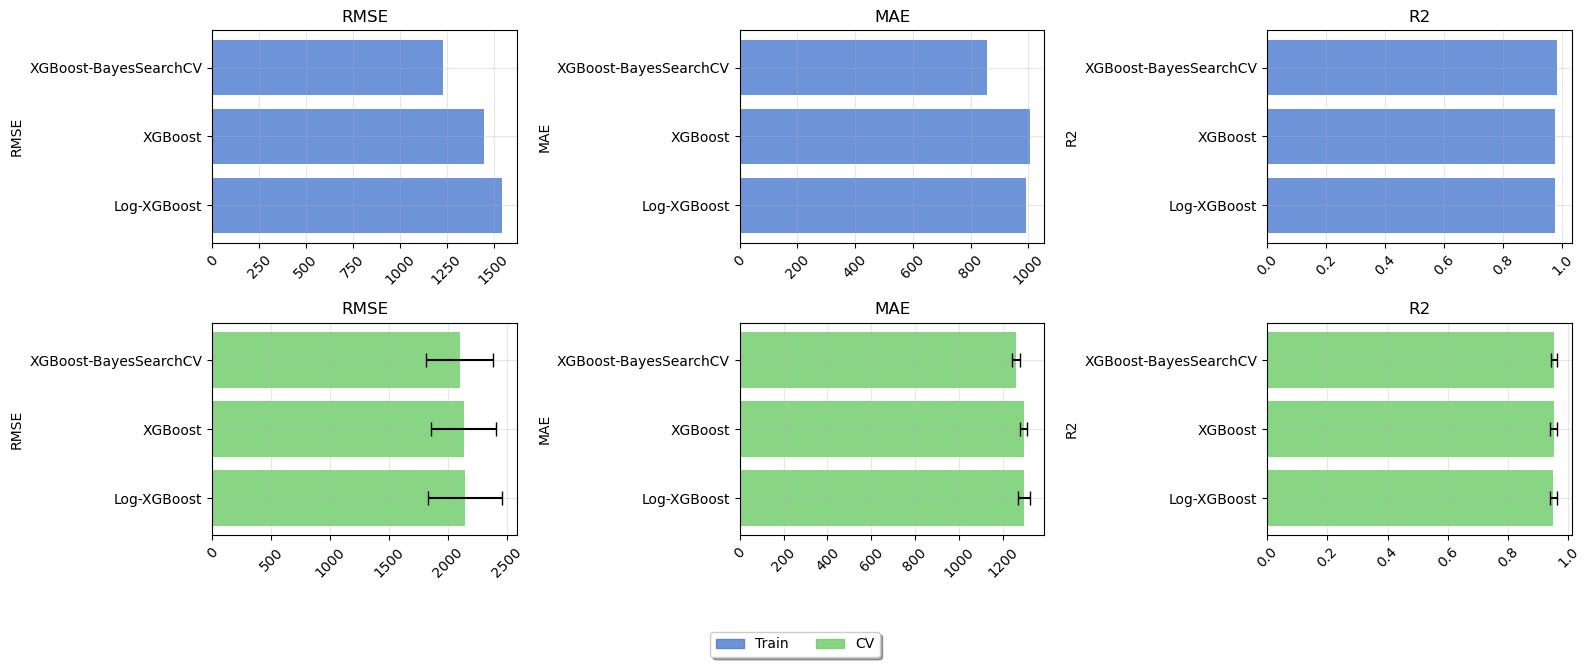

In [159]:
visualize_results(results3)

In [160]:
results3

,Model,Train_CV,RMSE,R2,MAE,CV_Train,RMSE (SD),MAE (SD),R2 (SD)
0,XGBoost,NaN,1448.393030,0.978098,1005.348184,Train,NaN,NaN,NaN
0,XGBoost,NaN,2133.987378,0.952091,1294.826100,CV,275.279329,14.081223,0.010330
0,Log-XGBoost,NaN,1546.824783,0.975020,992.435677,Train,NaN,NaN,NaN
0,Log-XGBoost,NaN,2145.016536,0.951466,1295.899168,CV,315.536923,27.531848,0.012091
0,XGBoost-BayesSearchCV,NaN,1232.970537,0.984128,857.760076,Train,NaN,NaN,NaN
0,XGBoost-BayesSearchCV,NaN,2097.668581,0.953635,1259.775491,CV,285.788296,17.037659,0.010746


## Random Forest

Vergleich: Vor- und Nachteile von XGBoost und Random Forest

*Vorteile* von **XGBoost**

- Bessere Generalisierungsfähigkeit:
Durch Gradient-Boosting reduziert XGBoost systematisch die Residualfehler und ist daher oft leistungsstärker als Random Forest.
- Flexibilität:
XGBoost bietet viele Hyperparameter (z. B. learning_rate, max_depth, gamma), die das Modell an verschiedene Problemstellungen anpassen können.
- Effizienz:
XGBoost nutzt Optimierungen wie Sparsity Awareness und parallele Berechnungen, wodurch es schneller als andere Boosting-Methoden (z. B. AdaBoost) ist.
- Handling von Ausreißern:
Durch gewichtetes Boosting kann XGBoost gezielt Ausreißer behandeln und dabei vermeiden, dass sie das Modell dominieren.
- Feature Importance:
XGBoost bietet detaillierte Informationen zur Bedeutung der Features (Gain, Cover, etc.), was für Interpretationen und Feature-Engineering hilfreich ist.


*Nachteile* von **XGBoost**

- Komplexität:
Das Modell ist komplexer und erfordert oft intensives Hyperparameter-Tuning, um die beste Leistung zu erzielen.
- Trainingszeit:
Für sehr große Datensätze ist XGBoost langsamer als Random Forest.
- Empfindlichkeit:
XGBoost kann empfindlich auf Rauschen und nicht korrekt abgestimmte Hyperparameter reagieren, was zu Overfitting führen kann.


*Vorteile* von **Random Forest**

- Einfach zu implementieren:
Random Forest hat weniger kritische Hyperparameter (z. B. n_estimators, max_depth), was das Modelltraining einfacher macht.
- Robustheit gegenüber Rauschen:
Random Forest ist weniger empfindlich gegenüber verrauschten Daten, da es eine Vielzahl von unabhängigen Entscheidungsbäumen kombiniert.
- Stabilität:
Random Forest liefert konsistente Ergebnisse, da jeder Baum unabhängig von den anderen trainiert wird (kein Boosting).
- Parallelisierbarkeit:
Da die Entscheidungsbäume unabhängig voneinander trainiert werden, ist Random Forest leichter parallelisierbar als XGBoost.
- Schnellere Trainingszeit:
Random Forest ist oft schneller als XGBoost, insbesondere bei kleineren bis mittleren Datensätzen.


*Nachteile* von **Random Forest**

- Geringere Vorhersagegenauigkeit:
Random Forest ist oft weniger genau als Gradient-Boosting-Methoden wie XGBoost, besonders bei komplexen, nichtlinearen Datenstrukturen.
- Schwächen bei Regressionsproblemen:
Random Forest tendiert dazu, Vorhersagen zu "glätten", was es schwieriger macht, extreme Werte oder Ausreißer genau vorherzusagen.
- Feature Importance weniger präzise:
Die Feature-Importance-Berechnungen bei Random Forest können bei korrelierten Features irreführend sein (Permutation Importance wäre hier besser).

In [161]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Beispiel-Daten: Features (X) und Zielwert (y)
X = train.drop(columns=['price', 'ID'], axis=1)
y = train['price']

# Definiere numerische und kategoriale Features
numeric_features = ['mileage', 'tax', 'mpg', 'engineSize', 'age']
categorical_features = ['model', 'transmission', 'fuelType', 'brand']

# Process numeric features: scaling
scaler = StandardScaler()
X_numeric = X[numeric_features]
X_scaled = scaler.fit_transform(X_numeric)

# Process categorical features: dummy coding
encoder = OneHotEncoder(handle_unknown="ignore", drop="first")
X_categorical = X[categorical_features]
X_encoded = encoder.fit_transform(X_categorical).toarray()



# Combine numeric and categorical features back
X_encoded = pd.DataFrame(X_encoded, columns= encoder.get_feature_names_out())
X_scaled = pd.DataFrame(X_scaled, columns= scaler.get_feature_names_out())

X_p = pd.concat([X_scaled, X_encoded], axis=1)

# Check the result
print(f"X_processed shape: {X_p.shape}")

X_processed shape: (30857, 55)


In [48]:

from skopt import BayesSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
"""
# Definiere den Hyperparameter-Suchraum
param_space = {
    'n_estimators': (100, 1000),  # Ganzzahliger Bereich
    'max_depth': (5, 30),         # Ganzzahliger Bereich
    'min_samples_split': (2, 20), # Ganzzahliger Bereich
    'min_samples_leaf': (1, 10),  # Ganzzahliger Bereich
    'max_features': ['sqrt', 'log2', None],  # Kategorisch
    'bootstrap': [True, False],   # Kategorisch
}

# Erstelle das Modell
rf = RandomForestRegressor(random_state=42)

# BayesSearchCV
bayes_search = BayesSearchCV(
    estimator=rf,
    search_spaces=param_space,
    n_iter=50,  # Anzahl der Iterationen
    scoring="neg_root_mean_squared_error",  # RMSE als Bewertungsmaßstab
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=2,
    verbose=2,
    random_state=42
)

# Training
bayes_search.fit(X_p, y)

# Ergebnisse
print("Beste Hyperparameter:", bayes_search.best_params_)
print("Niedrigstes RMSE:", -bayes_search.best_score_)
"""

'\n# Definiere den Hyperparameter-Suchraum\nparam_space = {\n    \'n_estimators\': (100, 1000),  # Ganzzahliger Bereich\n    \'max_depth\': (5, 30),         # Ganzzahliger Bereich\n    \'min_samples_split\': (2, 20), # Ganzzahliger Bereich\n    \'min_samples_leaf\': (1, 10),  # Ganzzahliger Bereich\n    \'max_features\': [\'sqrt\', \'log2\', None],  # Kategorisch\n    \'bootstrap\': [True, False],   # Kategorisch\n}\n\n# Erstelle das Modell\nrf = RandomForestRegressor(random_state=42)\n\n# BayesSearchCV\nbayes_search = BayesSearchCV(\n    estimator=rf,\n    search_spaces=param_space,\n    n_iter=50,  # Anzahl der Iterationen\n    scoring="neg_root_mean_squared_error",  # RMSE als Bewertungsmaßstab\n    cv=KFold(n_splits=5, shuffle=True, random_state=42),\n    n_jobs=2,\n    verbose=2,\n    random_state=42\n)\n\n# Training\nbayes_search.fit(X_p, y)\n\n# Ergebnisse\nprint("Beste Hyperparameter:", bayes_search.best_params_)\nprint("Niedrigstes RMSE:", -bayes_search.best_score_)\n'

In [163]:
from sklearn.ensemble import RandomForestRegressor

# Beste Hyperparameter aus BayesSearchCV
best_params = {
    'bootstrap': False,
    'max_depth': 30,
    'max_features': 'sqrt',
    'min_samples_leaf': 1,
    'min_samples_split': 7,
    'n_estimators': 1000
}

# Definiere das Random-Forest-Modell mit den besten Hyperparametern
rf_model_best = RandomForestRegressor(
    random_state=42,  # Gleicher Zufallszustand für Reproduzierbarkeit
    **best_params  # Füge die besten Hyperparameter hinzu
)

In [164]:
rf_scores = compute_metrics(rf_model_best, X_p, y, scorer=scorer, model_name="RandomForestRegressor")

In [165]:
results3 = pd.concat([results3, rf_scores], axis=0)

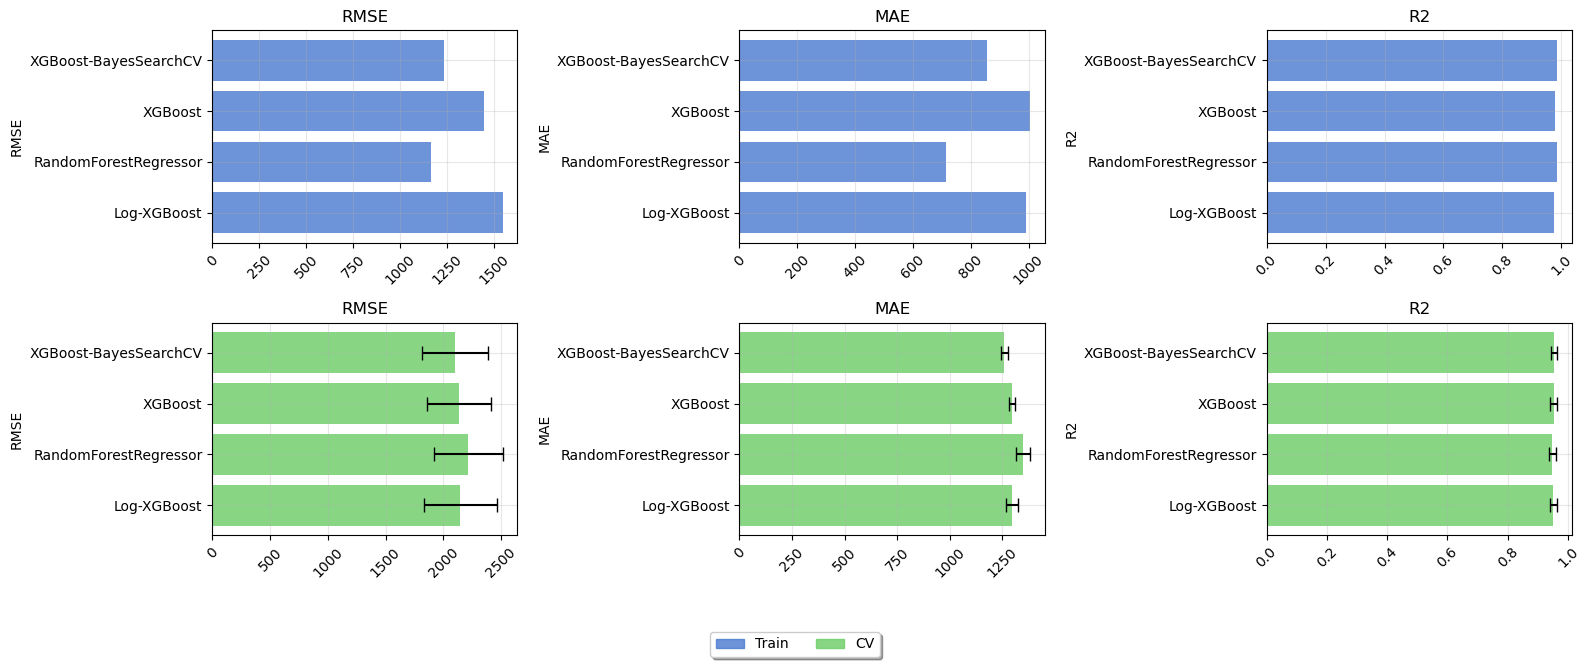

In [166]:
visualize_results(results3)

In [167]:
results3

,Model,Train_CV,RMSE,R2,MAE,CV_Train,RMSE (SD),MAE (SD),R2 (SD)
0,XGBoost,NaN,1448.393030,0.978098,1005.348184,Train,NaN,NaN,NaN
0,XGBoost,NaN,2133.987378,0.952091,1294.826100,CV,275.279329,14.081223,0.010330
0,Log-XGBoost,NaN,1546.824783,0.975020,992.435677,Train,NaN,NaN,NaN
0,Log-XGBoost,NaN,2145.016536,0.951466,1295.899168,CV,315.536923,27.531848,0.012091
0,XGBoost-BayesSearchCV,NaN,1232.970537,0.984128,857.760076,Train,NaN,NaN,NaN
0,XGBoost-BayesSearchCV,NaN,2097.668581,0.953635,1259.775491,CV,285.788296,17.037659,0.010746
0,RandomForestRegressor,NaN,1164.809202,0.985835,715.920832,Train,NaN,NaN,NaN
0,RandomForestRegressor,NaN,2215.900580,0.948270,1349.265631,CV,299.970697,32.690174,0.011865


In [168]:
# Sort results by cross-validation MSE
cv_results3 = results3.loc[results3["CV_Train"] == "CV", ["Model", "RMSE", "RMSE (SD)", "MAE", "MAE (SD)", "R2", "R2 (SD)"]]
cv_results3.sort_values(by="RMSE", ascending=True)

,Model,RMSE,RMSE (SD),MAE,MAE (SD),R2,R2 (SD)
0,XGBoost-BayesSearchCV,2097.668581,285.788296,1259.775491,17.037659,0.953635,0.010746
0,XGBoost,2133.987378,275.279329,1294.826100,14.081223,0.952091,0.010330
0,Log-XGBoost,2145.016536,315.536923,1295.899168,27.531848,0.951466,0.012091
0,RandomForestRegressor,2215.900580,299.970697,1349.265631,32.690174,0.948270,0.011865


Wir sehen, dass wir mit dem BayesSearchCV beim XGBoost-Modell den besten RMSE erzielen. Somit wäre dies hier der Favorit. Die Ergebnisse sind auch deutlich besser, als bei den "linearen" Modellen.

Als nächstes möchten wir unsere Features etwas besser vorbereiten, damit wir mehr Informationen daraus ziehen können. Dazu werden wir Textmining integrieren, damit das Modell mehr Infos aus den Features `model` und `brand` ziehen kann.

## 3. Approach: Textmining von `model` und `brand`

### Textmining (Beachte: Das Textencoding sollte ich über Google Colab durchführen)

In [232]:
# Beispiel-Daten: Features (X) und Zielwert (y)
X = train.drop(columns=['price', 'ID'], axis=1)
y = train['price']

In [234]:
X['model'].nunique()

43

In [233]:
y

0        29999
1         8750
2        22646
3        21950
4        13100
         ...  
30852    15880
30853    25495
30854    12698
30855     7740
30856    14700
Name: price, Length: 30857, dtype: int64

In [ ]:
import pandas as pd
from sentence_transformers import SentenceTransformer


In [ ]:
"""
# **Schritt 1: Lade ein vortrainiertes Embedding-Modell**
# Sentence Transformer-Modell laden (kann angepasst werden)
model = SentenceTransformer('all-MiniLM-L6-v2')


# **Schritt 2: Erstelle Embeddings für 'model'**
# Wandle die Werte in dense Vektoren um
model_embeddings = model.encode(X["model"].values, show_progress_bar=True)

# Konvertiere die Embeddings zu einem DataFrame
model_embeddings_df = pd.DataFrame(
    model_embeddings,
    columns=[f"model_emb_{i}" for i in range(model_embeddings.shape[1])],
    index=X.index,
)

# **Schritt 3: Erstelle Embeddings für 'brand'**
brand_embeddings = model.encode(X["brand"].values, show_progress_bar=True)

# Konvertiere die Embeddings zu einem DataFrame
brand_embeddings_df = pd.DataFrame(
    brand_embeddings,
    columns=[f"brand_emb_{i}" for i in range(brand_embeddings.shape[1])],
    index=X.index,
)

# **Schritt 4: Kombiniere die Embeddings mit den ursprünglichen Daten**
df_combined = pd.concat([X, model_embeddings_df, brand_embeddings_df], axis=1)

# Optional: Entferne die ursprünglichen Textspalten
df_combined = df_combined.drop(columns=["model", "brand"])

# **Ergebnis: Neuer DataFrame mit Embedding-Features**
print(df_combined)

"""

Batches:   0%|          | 0/965 [00:00<?, ?it/s]

: 

In [ ]:
## DIESEN CODE AUSFÜHREN
"""
from sentence_transformers import SentenceTransformer
import pandas as pd
from tqdm import tqdm  # Fortschrittsanzeige

# **Schritt 1: Lade das Modell**
model = SentenceTransformer('all-MiniLM-L6-v2')

# **Schritt 2: Funktion für batchweises Encoding**
def encode_in_batches(texts, batch_size=32):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding batches"):
        batch = texts[i:i + batch_size]
        batch_embeddings = model.encode(batch, show_progress_bar=False)
        embeddings.append(batch_embeddings)
    return np.vstack(embeddings)

# **Schritt 3: Verarbeite 'model'-Spalte in Batches**
model_embeddings = encode_in_batches(X["model"].values, batch_size=64)

# Konvertiere die Embeddings zu einem DataFrame
model_embeddings_df = pd.DataFrame(
    model_embeddings,
    columns=[f"model_emb_{i}" for i in range(model_embeddings.shape[1])],
    index=X.index,
)

# **Schritt 4: Verarbeite 'brand'-Spalte in Batches**
brand_embeddings = encode_in_batches(X["brand"].values, batch_size=64)

# Konvertiere die Embeddings zu einem DataFrame
brand_embeddings_df = pd.DataFrame(
    brand_embeddings,
    columns=[f"brand_emb_{i}" for i in range(brand_embeddings.shape[1])],
    index=X.index,
)

# **Schritt 5: Kombiniere die Daten**
df_combined = pd.concat([X, model_embeddings_df, brand_embeddings_df], axis=1)

# Optional: Entferne die ursprünglichen Textspalten
df_combined = df_combined.drop(columns=["model", "brand"])

print(df_combined)

"""


Encoding batches:   0%|          | 0/483 [00:00<?, ?it/s]

: 

In [ ]:
# STANDARDISIEREN SOLLTE UNTEN ANGEWENDET WERDEN, NACH DER REDUKTION DER DIMENSIONEN DURCH UMAP
"""
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

categorical_features = ['transmission', 'fuelType']

# **Schritt 1: Kombiniere numerische und Embedding-Features**
# Definiere die Embedding-Spalten
embedding_columns = [col for col in X if 'model_emb_' in col or 'brand_emb_' in col]

# Definiere die numerischen Features (außer dem Zielwert 'price')
numerical_columns = [col for col in X if col not in embedding_columns and col not in categorical_features]

# Kombiniere numerische und Embedding-Features zu einem Dataset
features_to_scale = pd.concat([X[numerical_columns], X[embedding_columns]], axis=1)

# Process numeric features: scaling
scaler = StandardScaler()
X_numeric = features_to_scale
X_scaled = scaler.fit_transform(X_numeric)


# Process categorical features: dummy coding
encoder = OneHotEncoder(handle_unknown="ignore", drop="first")
X_categorical = X[categorical_features]
X_encoded = encoder.fit_transform(X_categorical).toarray()
"""

"""
# Definiere numerische und kategoriale Features
numeric_features = ['mileage', 'tax', 'mpg', 'engineSize', 'age']
categorical_features = ['model', 'transmission', 'fuelType', 'brand']

# Process numeric features: scaling
scaler = StandardScaler()
X_numeric = X[numeric_features]
X_scaled = scaler.fit_transform(X_numeric)

# Process categorical features: dummy coding
encoder = OneHotEncoder(handle_unknown="ignore", drop="first")
X_categorical = X[categorical_features]
X_encoded = encoder.fit_transform(X_categorical).toarray()



# Combine numeric and categorical features back
X_encoded = pd.DataFrame(X_encoded, columns= encoder.get_feature_names_out())
X_scaled = pd.DataFrame(X_scaled, columns= scaler.get_feature_names_out())

X_p = pd.concat([X_scaled, X_encoded], axis=1)

# Check the result
print(f"X_processed shape: {X_p.shape}")
"""

'\n# Definiere numerische und kategoriale Features\nnumeric_features = [\'mileage\', \'tax\', \'mpg\', \'engineSize\', \'age\']\ncategorical_features = [\'model\', \'transmission\', \'fuelType\', \'brand\']\n\n# Process numeric features: scaling\nscaler = StandardScaler()\nX_numeric = X[numeric_features]\nX_scaled = scaler.fit_transform(X_numeric)\n\n# Process categorical features: dummy coding\nencoder = OneHotEncoder(handle_unknown="ignore", drop="first")\nX_categorical = X[categorical_features]\nX_encoded = encoder.fit_transform(X_categorical).toarray()\n\n\n\n# Combine numeric and categorical features back\nX_encoded = pd.DataFrame(X_encoded, columns= encoder.get_feature_names_out())\nX_scaled = pd.DataFrame(X_scaled, columns= scaler.get_feature_names_out())\n\nX_p = pd.concat([X_scaled, X_encoded], axis=1)\n\n# Check the result\nprint(f"X_processed shape: {X_p.shape}")\n'

In [ ]:
"""

# Combine numeric and categorical features back
X_encoded = pd.DataFrame(X_encoded, columns= encoder.get_feature_names_out())
X_scaled = pd.DataFrame(X_scaled, columns= scaler.get_feature_names_out())

X_p = pd.concat([X_scaled, X_encoded], axis=1)

# Check the result
print(f"X_processed shape: {X_p.shape}")

"""

X_processed shape: (30857, 778)


In [ ]:
# X_p.describe()

,mileage,tax,mpg,engineSize,age,model_emb_0,model_emb_1,model_emb_2,model_emb_3,model_emb_4,...,brand_emb_379,brand_emb_380,brand_emb_381,brand_emb_382,brand_emb_383,transmission_Manual,transmission_Semi-Auto,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
count,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,...,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000
mean,-1.151348e-17,-3.569178e-17,5.825819e-17,-1.238850e-16,-9.809483e-17,5.158038e-17,-4.352094e-17,-2.763235e-17,2.671127e-17,-3.431016e-17,...,2.450068e-16,-7.552841e-17,-1.123715e-16,-2.141507e-17,1.312536e-17,0.369641,0.379330,0.013060,0.002819,0.425479
std,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,...,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,0.482715,0.485228,0.113535,0.053025,0.494423
min,-1.044188e+00,-1.994525e+00,-3.642219e+00,-3.474039e+00,-1.325889e+00,-1.661003e+00,-2.993282e+00,-1.752459e+00,-2.786404e+00,-2.290779e+00,...,-1.126604e+00,-1.428746e+00,-1.011570e+00,-1.155841e+00,-6.433972e-01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.784290e-01,6.913603e-02,-5.945210e-01,-6.930594e-01,-8.469102e-01,-6.898001e-01,-6.772932e-01,-8.135344e-01,-6.311654e-01,-6.378606e-01,...,-1.126604e+00,-1.428746e+00,-8.644201e-01,-3.535862e-01,-6.433945e-01,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-2.823608e-01,3.993218e-01,-7.647969e-02,2.339338e-01,1.110483e-01,-3.289446e-01,7.863801e-02,-6.576854e-02,-2.325040e-01,-2.344849e-01,...,-4.168917e-01,8.636978e-01,-8.644201e-01,-3.535862e-01,-6.215450e-01,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.711753e-01,3.993218e-01,4.684729e-01,2.339338e-01,5.900275e-01,4.043004e-01,8.736444e-01,5.999788e-01,9.671737e-01,5.037061e-01,...,1.454466e+00,8.636978e-01,6.390028e-01,-1.095986e-01,-2.959520e-01,1.000000,1.000000,0.000000,0.000000,1.000000
max,8.546389e+00,7.580863e+00,1.095713e+01,8.020677e+00,1.016961e+01,2.188763e+00,1.636087e+00,2.338097e+00,1.641293e+00,2.589756e+00,...,1.454466e+00,9.409561e-01,1.435330e+00,1.767115e+00,1.883904e+00,1.000000,1.000000,1.000000,1.000000,1.000000


# Ab hier für mit Embeddings

In [267]:
X_p = pd.read_csv('embedding2_nicht_standardisiert.csv')

In [438]:
X_p = pd.read_csv('embedding_nicht_standardisiert.csv')

In [44]:
X_p = pd.read_csv('normalized_embedding_combined_simple_nicht_standardisiert.csv') # für Resultat 1 und 2

In [45]:
X_p

,Unnamed: 0,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand,age,...,model_emb_374,model_emb_375,model_emb_376,model_emb_377,model_emb_378,model_emb_379,model_emb_380,model_emb_381,model_emb_382,model_emb_383
0,0,29999.0,Automatic,2728,Diesel,145,47.9,2.0,VW,4,...,0.052244,-0.005388,-0.000575,-0.013729,-0.097805,0.092649,-0.019172,0.032075,0.030016,-0.066839
1,1,8750.0,Manual,12500,Petrol,145,64.2,1.0,VW,6,...,0.053137,0.029597,-0.007852,0.006023,-0.066697,0.084566,0.116766,-0.006538,-0.001121,0.032301
2,2,22646.0,Manual,123,Petrol,145,52.3,1.5,BMW,5,...,0.090168,-0.002706,-0.010768,0.017799,-0.095048,0.082865,0.092481,-0.045265,-0.016657,-0.003030
3,3,21950.0,Manual,5013,Petrol,145,44.1,1.5,BMW,5,...,0.086141,0.010043,-0.003143,-0.000169,-0.082913,0.069421,0.074160,-0.035430,-0.005207,0.003669
4,4,13100.0,Automatic,64455,Diesel,160,50.4,2.0,BMW,11,...,0.082341,0.033176,-0.016129,0.055780,-0.053845,0.050757,0.055362,-0.005449,-0.037882,-0.015264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46748,46748,NaN,Automatic,73150,Diesel,160,50.4,3.0,BMW,9,...,0.117799,0.000758,0.015554,0.012355,-0.079295,0.029534,0.082450,-0.040753,-0.008863,-0.008524
46749,46749,NaN,Automatic,68686,Diesel,260,38.2,3.0,VW,13,...,0.053704,0.010795,0.050971,0.056238,-0.056288,0.009009,0.042875,0.026614,-0.022722,-0.028147
46750,46750,NaN,Manual,37883,Diesel,20,70.6,1.5,Mercedes,9,...,-0.032954,-0.015206,-0.012132,-0.042198,-0.104838,-0.031655,-0.007133,0.035322,-0.008163,0.041339
46751,46751,NaN,Manual,501,Petrol,145,44.1,1.0,VW,4,...,0.005756,0.007312,0.036747,-0.014986,-0.113362,0.022542,0.036087,-0.106397,0.022362,-0.073791


In [476]:
X_p = pd.read_csv('embedding_combined_simple_nicht_standardisiert.csv') # für Resultat 3

In [86]:
X_p = pd.read_csv('embedding_combined_complex_nicht_standardisiert.csv') # für Resultat 4

In [87]:
X_p.drop(columns=['Unnamed: 0'], inplace=True)

---
### Dies nur bei combined Dataset anwende:

In [88]:
X_p

,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand,age,model_emb_0,...,model_emb_758,model_emb_759,model_emb_760,model_emb_761,model_emb_762,model_emb_763,model_emb_764,model_emb_765,model_emb_766,model_emb_767
0,29999.0,Automatic,2728,Diesel,145,47.9,2.0,VW,4,-0.114688,...,-0.022777,0.058496,0.048823,0.022590,0.005809,0.006859,-0.050835,0.049975,-0.074612,-0.003194
1,8750.0,Manual,12500,Petrol,145,64.2,1.0,VW,6,-0.020240,...,0.018196,0.004669,0.053758,-0.054459,0.040725,0.189634,0.036238,0.005806,-0.056499,-0.008064
2,22646.0,Manual,123,Petrol,145,52.3,1.5,BMW,5,-0.016028,...,0.053572,-0.050263,0.022313,-0.062484,0.006224,-0.102999,0.087234,-0.053492,-0.062856,-0.028412
3,21950.0,Manual,5013,Petrol,145,44.1,1.5,BMW,5,-0.019465,...,0.032536,0.017422,0.071073,-0.001725,-0.001509,0.013936,0.048515,-0.008994,-0.113233,-0.025600
4,13100.0,Automatic,64455,Diesel,160,50.4,2.0,BMW,11,-0.115211,...,0.046751,0.082057,0.043738,-0.011440,0.027270,0.185043,-0.026691,0.098764,-0.172840,-0.011881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46748,NaN,Automatic,73150,Diesel,160,50.4,3.0,BMW,9,-0.070959,...,-0.008339,-0.069042,0.054318,-0.002010,0.004369,0.103824,0.058064,-0.044903,-0.038473,-0.025506
46749,NaN,Automatic,68686,Diesel,260,38.2,3.0,VW,13,-0.052462,...,-0.047157,0.065516,0.070366,-0.024161,-0.050596,0.093029,-0.058948,0.000043,0.013762,0.062641
46750,NaN,Manual,37883,Diesel,20,70.6,1.5,Mercedes,9,-0.102459,...,-0.047766,0.017879,0.090543,-0.061058,0.060552,0.175991,-0.015308,-0.014490,-0.111524,0.013871
46751,NaN,Manual,501,Petrol,145,44.1,1.0,VW,4,-0.086549,...,-0.088696,0.053544,0.024010,0.023584,0.038687,0.121559,-0.007538,0.059879,-0.121636,-0.016948


In [89]:
# Beispiel-Daten: Features (X) und Zielwert (y)
X = train.drop(columns=['price', 'ID'], axis=1)
y = train['price']

In [90]:
X

,model,transmission,mileage,fuelType,tax,mpg,engineSize,brand,age
0,Tiguan,Automatic,2728,Diesel,145,47.9,2.0,VW,4
1,Up,Manual,12500,Petrol,145,64.2,1.0,VW,6
2,2 Series,Manual,123,Petrol,145,52.3,1.5,BMW,5
3,1 Series,Manual,5013,Petrol,145,44.1,1.5,BMW,5
4,X3,Automatic,64455,Diesel,160,50.4,2.0,BMW,11
...,...,...,...,...,...,...,...,...,...
30852,Q3,Automatic,19000,Diesel,200,47.9,2.0,Audi,10
30853,Tiguan,Manual,14790,Diesel,150,50.4,2.0,VW,6
30854,A4,Manual,36081,Diesel,145,55.4,2.0,Audi,9
30855,Polo,Manual,69548,Petrol,20,60.1,1.2,VW,8


In [91]:
comp_data

,transmission,mileage,fuelType,tax,mpg,engineSize,brand,age,model_emb_0,model_emb_1,...,model_emb_374,model_emb_375,model_emb_376,model_emb_377,model_emb_378,model_emb_379,model_emb_380,model_emb_381,model_emb_382,model_emb_383
0,Manual,40000,Petrol,205,39.8,2.0,VW,9,0.072040,0.033930,...,0.052980,0.078471,-0.033414,-0.035676,-0.060900,0.021321,0.069672,-0.078818,0.063684,0.011848
1,Automatic,30112,Petrol,145,43.5,2.0,Mercedes,7,-0.102730,0.015461,...,-0.007544,-0.069977,0.024748,-0.030140,-0.034230,0.044058,-0.033096,0.008899,-0.032528,0.015399
2,Semi-Auto,19168,Petrol,145,49.6,1.6,BMW,9,-0.059272,0.027512,...,0.086141,0.010043,-0.003143,-0.000169,-0.082913,0.069421,0.074160,-0.035430,-0.005207,0.003669
3,Semi-Auto,14700,Petrol,145,45.6,1.3,Mercedes,5,-0.064445,0.041166,...,-0.029693,0.000019,-0.041940,-0.071079,-0.075565,0.015811,0.038140,0.053710,-0.064857,0.011703
4,Manual,64800,Petrol,200,40.9,1.6,Audi,14,-0.101156,-0.043183,...,0.043621,-0.080911,0.001161,-0.034716,-0.030356,-0.027355,0.074788,-0.052652,-0.035401,0.038845
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15891,Automatic,73150,Diesel,160,50.4,3.0,BMW,9,0.011970,0.032364,...,0.117799,0.000758,0.015554,0.012355,-0.079295,0.029534,0.082450,-0.040753,-0.008863,-0.008524
15892,Automatic,68686,Diesel,260,38.2,3.0,VW,13,-0.026294,-0.021067,...,0.053704,0.010795,0.050971,0.056238,-0.056288,0.009009,0.042875,0.026614,-0.022722,-0.028147
15893,Manual,37883,Diesel,20,70.6,1.5,Mercedes,9,-0.088666,0.065535,...,-0.032954,-0.015206,-0.012132,-0.042198,-0.104838,-0.031655,-0.007133,0.035322,-0.008163,0.041339
15894,Manual,501,Petrol,145,44.1,1.0,VW,4,-0.024696,-0.006489,...,0.005756,0.007312,0.036747,-0.014986,-0.113362,0.022542,0.036087,-0.106397,0.022362,-0.073791


In [92]:
comp_data = X_p.iloc[len(X):len(X)+len(comp_data)]

In [93]:
comp_data

,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand,age,model_emb_0,...,model_emb_758,model_emb_759,model_emb_760,model_emb_761,model_emb_762,model_emb_763,model_emb_764,model_emb_765,model_emb_766,model_emb_767
30857,NaN,Manual,40000,Petrol,205,39.8,2.0,VW,9,-0.052820,...,-0.060474,0.017557,0.076746,-0.122707,0.106721,0.134993,-0.024444,-0.019076,-0.058193,-0.007551
30858,NaN,Automatic,30112,Petrol,145,43.5,2.0,Mercedes,7,-0.057636,...,0.034959,0.106690,0.157806,-0.043938,-0.021870,-0.052833,0.011837,0.076828,-0.147334,-0.039567
30859,NaN,Semi-Auto,19168,Petrol,145,49.6,1.6,BMW,9,-0.019465,...,0.032536,0.017422,0.071073,-0.001725,-0.001509,0.013936,0.048515,-0.008994,-0.113233,-0.025600
30860,NaN,Semi-Auto,14700,Petrol,145,45.6,1.3,Mercedes,5,-0.147863,...,-0.032651,0.077528,0.018030,-0.043024,0.002910,0.242243,-0.016168,-0.020795,-0.083271,-0.027235
30861,NaN,Manual,64800,Petrol,200,40.9,1.6,Audi,14,-0.056584,...,-0.059964,0.048684,0.101353,-0.046543,0.020480,0.078081,-0.052573,0.035048,-0.147416,0.043211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46748,NaN,Automatic,73150,Diesel,160,50.4,3.0,BMW,9,-0.070959,...,-0.008339,-0.069042,0.054318,-0.002010,0.004369,0.103824,0.058064,-0.044903,-0.038473,-0.025506
46749,NaN,Automatic,68686,Diesel,260,38.2,3.0,VW,13,-0.052462,...,-0.047157,0.065516,0.070366,-0.024161,-0.050596,0.093029,-0.058948,0.000043,0.013762,0.062641
46750,NaN,Manual,37883,Diesel,20,70.6,1.5,Mercedes,9,-0.102459,...,-0.047766,0.017879,0.090543,-0.061058,0.060552,0.175991,-0.015308,-0.014490,-0.111524,0.013871
46751,NaN,Manual,501,Petrol,145,44.1,1.0,VW,4,-0.086549,...,-0.088696,0.053544,0.024010,0.023584,0.038687,0.121559,-0.007538,0.059879,-0.121636,-0.016948


In [94]:
X_p = X_p.iloc[:len(X)]

In [95]:
X_p.drop(columns=['price'], inplace=True)

/var/folders/yg/_yglls0s5958b_wpb6zlpk8h0000gn/T/ipykernel_24102/189197358.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_p.drop(columns=['price'], inplace=True)


In [96]:
X_p

,transmission,mileage,fuelType,tax,mpg,engineSize,brand,age,model_emb_0,model_emb_1,...,model_emb_758,model_emb_759,model_emb_760,model_emb_761,model_emb_762,model_emb_763,model_emb_764,model_emb_765,model_emb_766,model_emb_767
0,Automatic,2728,Diesel,145,47.9,2.0,VW,4,-0.114688,0.295338,...,-0.022777,0.058496,0.048823,0.022590,0.005809,0.006859,-0.050835,0.049975,-0.074612,-0.003194
1,Manual,12500,Petrol,145,64.2,1.0,VW,6,-0.020240,0.002831,...,0.018196,0.004669,0.053758,-0.054459,0.040725,0.189634,0.036238,0.005806,-0.056499,-0.008064
2,Manual,123,Petrol,145,52.3,1.5,BMW,5,-0.016028,0.233312,...,0.053572,-0.050263,0.022313,-0.062484,0.006224,-0.102999,0.087234,-0.053492,-0.062856,-0.028412
3,Manual,5013,Petrol,145,44.1,1.5,BMW,5,-0.019465,0.002821,...,0.032536,0.017422,0.071073,-0.001725,-0.001509,0.013936,0.048515,-0.008994,-0.113233,-0.025600
4,Automatic,64455,Diesel,160,50.4,2.0,BMW,11,-0.115211,0.105837,...,0.046751,0.082057,0.043738,-0.011440,0.027270,0.185043,-0.026691,0.098764,-0.172840,-0.011881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30852,Automatic,19000,Diesel,200,47.9,2.0,Audi,10,-0.102788,-0.268438,...,-0.000382,0.047921,0.078645,0.037348,0.086031,0.218328,0.016218,0.037406,-0.141155,-0.051478
30853,Manual,14790,Diesel,150,50.4,2.0,VW,6,-0.114688,0.295338,...,-0.022777,0.058496,0.048823,0.022590,0.005809,0.006859,-0.050835,0.049975,-0.074612,-0.003194
30854,Manual,36081,Diesel,145,55.4,2.0,Audi,9,-0.121120,0.172204,...,-0.076163,0.075947,0.163568,-0.027045,0.017718,0.050144,-0.015377,0.068474,-0.101579,0.051547
30855,Manual,69548,Petrol,20,60.1,1.2,VW,8,-0.056285,-0.010696,...,-0.122357,-0.084883,-0.025538,0.029385,0.080273,0.227010,-0.091331,-0.016238,-0.079256,0.028882


---

### Bearbeitung, damit nur Model als Embedding genutzt wird.

In [271]:
X_p = pd.concat([X_p, train['brand']], axis=1)

In [240]:
X_p.describe()

,mileage,tax,mpg,engineSize,age,model_emb_0,model_emb_1,model_emb_2,model_emb_3,model_emb_4,...,brand_emb_758,brand_emb_759,brand_emb_760,brand_emb_761,brand_emb_762,brand_emb_763,brand_emb_764,brand_emb_765,brand_emb_766,brand_emb_767
count,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000,...,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000
mean,23300.447030,120.812295,54.436770,1.873821,6.768156,-0.091555,0.144571,-0.059624,0.052857,-0.039287,...,-0.010017,0.062378,0.054793,-0.038933,0.021758,0.071929,-0.026063,0.026922,-0.107665,-0.020940
std,22313.826135,60.572940,14.863921,0.539387,2.087807,0.047542,0.154427,0.037141,0.052674,0.060133,...,0.040167,0.063831,0.080664,0.039327,0.059144,0.081662,0.057298,0.047723,0.032979,0.047030
min,1.000000,0.000000,0.300000,0.000000,4.000000,-0.220804,-0.268438,-0.144421,-0.106918,-0.149995,...,-0.048363,-0.018680,-0.033770,-0.093035,-0.055643,-0.070488,-0.094276,-0.046246,-0.133000,-0.076698
25%,5931.000000,125.000000,45.600000,1.500000,5.000000,-0.131755,0.047941,-0.094864,0.040503,-0.081194,...,-0.048363,0.029217,0.000524,-0.093035,0.001420,0.059876,-0.094276,0.002892,-0.133000,-0.048249
50%,17000.000000,145.000000,53.300000,2.000000,7.000000,-0.098157,0.154313,-0.057180,0.060274,-0.033275,...,-0.036254,0.051426,0.035690,-0.012106,0.013642,0.133207,-0.056304,0.064908,-0.122034,-0.025544
75%,33814.000000,145.000000,61.400000,2.000000,8.000000,-0.052820,0.221842,-0.029223,0.087455,0.009958,...,0.014600,0.151017,0.170491,-0.012106,0.110695,0.133207,0.030617,0.064908,-0.058529,0.045032
max,214000.000000,580.000000,217.300000,6.200000,28.000000,-0.016028,0.623345,0.000507,0.123989,0.067029,...,0.053285,0.151017,0.170491,0.007847,0.110695,0.143627,0.045212,0.076630,-0.058529,0.045032


In [241]:
X_p

,transmission,mileage,fuelType,tax,mpg,engineSize,age,model_emb_0,model_emb_1,model_emb_2,...,brand_emb_759,brand_emb_760,brand_emb_761,brand_emb_762,brand_emb_763,brand_emb_764,brand_emb_765,brand_emb_766,brand_emb_767,brand
0,Automatic,2728,Diesel,145,47.9,2.0,4,-0.114688,0.295338,-0.067340,...,0.151017,0.170491,-0.012106,0.013642,0.133207,-0.056304,0.064908,-0.058529,0.045032,VW
1,Manual,12500,Petrol,145,64.2,1.0,6,-0.020240,0.002831,-0.029699,...,0.151017,0.170491,-0.012106,0.013642,0.133207,-0.056304,0.064908,-0.058529,0.045032,VW
2,Manual,123,Petrol,145,52.3,1.5,5,-0.016028,0.233312,-0.094864,...,-0.018678,-0.033766,-0.058020,0.001420,0.143627,0.045203,0.076627,-0.122034,-0.025544,BMW
3,Manual,5013,Petrol,145,44.1,1.5,5,-0.019465,0.002821,-0.103749,...,-0.018678,-0.033766,-0.058020,0.001420,0.143627,0.045203,0.076627,-0.122034,-0.025544,BMW
4,Automatic,64455,Diesel,160,50.4,2.0,11,-0.115211,0.105837,-0.144421,...,-0.018678,-0.033766,-0.058020,0.001420,0.143627,0.045203,0.076627,-0.122034,-0.025544,BMW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30852,Automatic,19000,Diesel,200,47.9,2.0,10,-0.102788,-0.268438,-0.070833,...,0.029217,0.000524,0.007847,-0.055643,-0.070488,0.030617,-0.046246,-0.132381,-0.076698,Audi
30853,Manual,14790,Diesel,150,50.4,2.0,6,-0.114688,0.295338,-0.067340,...,0.151017,0.170491,-0.012106,0.013642,0.133207,-0.056304,0.064908,-0.058529,0.045032,VW
30854,Manual,36081,Diesel,145,55.4,2.0,9,-0.121120,0.172204,-0.057180,...,0.029217,0.000524,0.007847,-0.055643,-0.070488,0.030617,-0.046246,-0.132381,-0.076698,Audi
30855,Manual,69548,Petrol,20,60.1,1.2,8,-0.056285,-0.010696,-0.007619,...,0.151017,0.170491,-0.012106,0.013642,0.133207,-0.056304,0.064908,-0.058529,0.045032,VW


In [272]:
brand_embedding = X_p.filter(like='brand_emb')

In [273]:
X_p = X_p.drop(columns=brand_embedding.columns)

In [274]:
X_p

,transmission,mileage,fuelType,tax,mpg,engineSize,age,model_emb_0,model_emb_1,model_emb_2,...,model_emb_759,model_emb_760,model_emb_761,model_emb_762,model_emb_763,model_emb_764,model_emb_765,model_emb_766,model_emb_767,brand
0,Automatic,2728,Diesel,145,47.9,2.0,4,-0.114688,0.295338,-0.067340,...,0.058496,0.048823,0.022590,0.005809,0.006859,-0.050835,0.049975,-0.074612,-0.003194,VW
1,Manual,12500,Petrol,145,64.2,1.0,6,-0.020240,0.002831,-0.029699,...,0.004669,0.053758,-0.054459,0.040725,0.189634,0.036238,0.005806,-0.056499,-0.008064,VW
2,Manual,123,Petrol,145,52.3,1.5,5,-0.016028,0.233312,-0.094864,...,-0.050263,0.022313,-0.062484,0.006224,-0.102999,0.087234,-0.053492,-0.062856,-0.028412,BMW
3,Manual,5013,Petrol,145,44.1,1.5,5,-0.019465,0.002821,-0.103749,...,0.017422,0.071073,-0.001725,-0.001509,0.013936,0.048515,-0.008994,-0.113233,-0.025600,BMW
4,Automatic,64455,Diesel,160,50.4,2.0,11,-0.115211,0.105837,-0.144421,...,0.082057,0.043738,-0.011440,0.027270,0.185043,-0.026691,0.098764,-0.172840,-0.011881,BMW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30852,Automatic,19000,Diesel,200,47.9,2.0,10,-0.102788,-0.268438,-0.070833,...,0.047921,0.078645,0.037348,0.086031,0.218328,0.016218,0.037406,-0.141155,-0.051478,Audi
30853,Manual,14790,Diesel,150,50.4,2.0,6,-0.114688,0.295338,-0.067340,...,0.058496,0.048823,0.022590,0.005809,0.006859,-0.050835,0.049975,-0.074612,-0.003194,VW
30854,Manual,36081,Diesel,145,55.4,2.0,9,-0.121120,0.172204,-0.057180,...,0.075947,0.163568,-0.027045,0.017718,0.050144,-0.015377,0.068474,-0.101579,0.051547,Audi
30855,Manual,69548,Petrol,20,60.1,1.2,8,-0.056285,-0.010696,-0.007619,...,-0.084883,-0.025538,0.029385,0.080273,0.227010,-0.091331,-0.016238,-0.079256,0.028882,VW


### X_p enthält damit nur mehr modell als Embedding und brand als eine einzige Spalte, die ich OneHotEncode

---

In [97]:
comp_data.drop(columns=['price'], inplace=True)

/var/folders/yg/_yglls0s5958b_wpb6zlpk8h0000gn/T/ipykernel_24102/3720776311.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comp_data.drop(columns=['price'], inplace=True)


In [98]:
comp_data.reset_index(drop=True, inplace=True)

In [99]:
comp_data

,transmission,mileage,fuelType,tax,mpg,engineSize,brand,age,model_emb_0,model_emb_1,...,model_emb_758,model_emb_759,model_emb_760,model_emb_761,model_emb_762,model_emb_763,model_emb_764,model_emb_765,model_emb_766,model_emb_767
0,Manual,40000,Petrol,205,39.8,2.0,VW,9,-0.052820,0.318729,...,-0.060474,0.017557,0.076746,-0.122707,0.106721,0.134993,-0.024444,-0.019076,-0.058193,-0.007551
1,Automatic,30112,Petrol,145,43.5,2.0,Mercedes,7,-0.057636,0.047941,...,0.034959,0.106690,0.157806,-0.043938,-0.021870,-0.052833,0.011837,0.076828,-0.147334,-0.039567
2,Semi-Auto,19168,Petrol,145,49.6,1.6,BMW,9,-0.019465,0.002821,...,0.032536,0.017422,0.071073,-0.001725,-0.001509,0.013936,0.048515,-0.008994,-0.113233,-0.025600
3,Semi-Auto,14700,Petrol,145,45.6,1.3,Mercedes,5,-0.147863,-0.012942,...,-0.032651,0.077528,0.018030,-0.043024,0.002910,0.242243,-0.016168,-0.020795,-0.083271,-0.027235
4,Manual,64800,Petrol,200,40.9,1.6,Audi,14,-0.056584,0.061097,...,-0.059964,0.048684,0.101353,-0.046543,0.020480,0.078081,-0.052573,0.035048,-0.147416,0.043211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15891,Automatic,73150,Diesel,160,50.4,3.0,BMW,9,-0.070959,0.203805,...,-0.008339,-0.069042,0.054318,-0.002010,0.004369,0.103824,0.058064,-0.044903,-0.038473,-0.025506
15892,Automatic,68686,Diesel,260,38.2,3.0,VW,13,-0.052462,0.091607,...,-0.047157,0.065516,0.070366,-0.024161,-0.050596,0.093029,-0.058948,0.000043,0.013762,0.062641
15893,Manual,37883,Diesel,20,70.6,1.5,Mercedes,9,-0.102459,0.156287,...,-0.047766,0.017879,0.090543,-0.061058,0.060552,0.175991,-0.015308,-0.014490,-0.111524,0.013871
15894,Manual,501,Petrol,145,44.1,1.0,VW,4,-0.086549,-0.139062,...,-0.088696,0.053544,0.024010,0.023584,0.038687,0.121559,-0.007538,0.059879,-0.121636,-0.016948


In [100]:
# Erstelle das DataFrame "brand_embedding" mit den Spalten, die "model_emb" enthalten
#brand_embedding = X_p.filter(like='brand_emb')

# Erstelle das DataFrame "model_embedding" mit den Spalten, die "brand_emb" enthalten
model_embedding_comp = comp_data.filter(like='model_emb')

# Überprüfe die resultierenden DataFrames
#print("brand_embedding DataFrame:")
#print(brand_embedding.head())

print("\nmodel_embedding DataFrame:")
print(model_embedding_comp.head())


model_embedding DataFrame:
   model_emb_0  model_emb_1  model_emb_2  model_emb_3  model_emb_4  \
0    -0.052820     0.318729    -0.015721     0.040503    -0.009863   
1    -0.057636     0.047941    -0.036761     0.110976     0.010639   
2    -0.019465     0.002821    -0.103749     0.082672    -0.081194   
3    -0.147863    -0.012942    -0.082172     0.067055    -0.040928   
4    -0.056584     0.061097    -0.037230     0.064984    -0.019970   

   model_emb_5  model_emb_6  model_emb_7  model_emb_8  model_emb_9  ...  \
0     0.057744     0.066124     0.102169    -0.049359     0.090499  ...   
1    -0.003760     0.141277     0.065029     0.002024     0.046724  ...   
2    -0.009064     0.018139     0.202460    -0.090181     0.209606  ...   
3     0.013126     0.069242     0.066660    -0.129141     0.062075  ...   
4     0.011391     0.044062     0.149231    -0.006854     0.072207  ...   

   model_emb_758  model_emb_759  model_emb_760  model_emb_761  model_emb_762  \
0      -0.060474    

In [101]:
# Erstelle das DataFrame "brand_embedding" mit den Spalten, die "model_emb" enthalten
#brand_embedding = X_p.filter(like='brand_emb')

# Erstelle das DataFrame "model_embedding" mit den Spalten, die "brand_emb" enthalten
model_embedding = X_p.filter(like='model_emb')

# Überprüfe die resultierenden DataFrames
#print("brand_embedding DataFrame:")
#print(brand_embedding.head())

print("\nmodel_embedding DataFrame:")
print(model_embedding.head())


model_embedding DataFrame:
   model_emb_0  model_emb_1  model_emb_2  model_emb_3  model_emb_4  \
0    -0.114688     0.295338    -0.067340     0.094228    -0.070503   
1    -0.020240     0.002831    -0.029699     0.006998    -0.053526   
2    -0.016028     0.233312    -0.094864     0.059159    -0.130475   
3    -0.019465     0.002821    -0.103749     0.082672    -0.081194   
4    -0.115211     0.105837    -0.144421     0.088067    -0.030350   

   model_emb_5  model_emb_6  model_emb_7  model_emb_8  model_emb_9  ...  \
0    -0.019408     0.149783     0.089138     0.026668     0.010307  ...   
1     0.086886    -0.035445     0.060480    -0.080650     0.152610  ...   
2    -0.000518    -0.053670     0.156676    -0.060354     0.134271  ...   
3    -0.009064     0.018139     0.202460    -0.090181     0.209606  ...   
4     0.001279     0.105110     0.101231    -0.043850     0.090339  ...   

   model_emb_758  model_emb_759  model_emb_760  model_emb_761  model_emb_762  \
0      -0.022777    

In [102]:
model_embedding

,model_emb_0,model_emb_1,model_emb_2,model_emb_3,model_emb_4,model_emb_5,model_emb_6,model_emb_7,model_emb_8,model_emb_9,...,model_emb_758,model_emb_759,model_emb_760,model_emb_761,model_emb_762,model_emb_763,model_emb_764,model_emb_765,model_emb_766,model_emb_767
0,-0.114688,0.295338,-0.067340,0.094228,-0.070503,-0.019408,0.149783,0.089138,0.026668,0.010307,...,-0.022777,0.058496,0.048823,0.022590,0.005809,0.006859,-0.050835,0.049975,-0.074612,-0.003194
1,-0.020240,0.002831,-0.029699,0.006998,-0.053526,0.086886,-0.035445,0.060480,-0.080650,0.152610,...,0.018196,0.004669,0.053758,-0.054459,0.040725,0.189634,0.036238,0.005806,-0.056499,-0.008064
2,-0.016028,0.233312,-0.094864,0.059159,-0.130475,-0.000518,-0.053670,0.156676,-0.060354,0.134271,...,0.053572,-0.050263,0.022313,-0.062484,0.006224,-0.102999,0.087234,-0.053492,-0.062856,-0.028412
3,-0.019465,0.002821,-0.103749,0.082672,-0.081194,-0.009064,0.018139,0.202460,-0.090181,0.209606,...,0.032536,0.017422,0.071073,-0.001725,-0.001509,0.013936,0.048515,-0.008994,-0.113233,-0.025600
4,-0.115211,0.105837,-0.144421,0.088067,-0.030350,0.001279,0.105110,0.101231,-0.043850,0.090339,...,0.046751,0.082057,0.043738,-0.011440,0.027270,0.185043,-0.026691,0.098764,-0.172840,-0.011881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30852,-0.102788,-0.268438,-0.070833,0.055058,-0.095676,-0.019254,-0.032140,0.061417,-0.081868,0.113658,...,-0.000382,0.047921,0.078645,0.037348,0.086031,0.218328,0.016218,0.037406,-0.141155,-0.051478
30853,-0.114688,0.295338,-0.067340,0.094228,-0.070503,-0.019408,0.149783,0.089138,0.026668,0.010307,...,-0.022777,0.058496,0.048823,0.022590,0.005809,0.006859,-0.050835,0.049975,-0.074612,-0.003194
30854,-0.121120,0.172204,-0.057180,0.068928,0.011982,0.053086,0.043188,0.127950,-0.031820,0.119813,...,-0.076163,0.075947,0.163568,-0.027045,0.017718,0.050144,-0.015377,0.068474,-0.101579,0.051547
30855,-0.056285,-0.010696,-0.007619,-0.106918,-0.149995,0.162820,-0.085926,0.064710,-0.036208,0.123099,...,-0.122357,-0.084883,-0.025538,0.029385,0.080273,0.227010,-0.091331,-0.016238,-0.079256,0.028882


In [279]:
y

0        29999
1         8750
2        22646
3        21950
4        13100
         ...  
30852    15880
30853    25495
30854    12698
30855     7740
30856    14700
Name: price, Length: 30857, dtype: int64

In [103]:
X_p

,transmission,mileage,fuelType,tax,mpg,engineSize,brand,age,model_emb_0,model_emb_1,...,model_emb_758,model_emb_759,model_emb_760,model_emb_761,model_emb_762,model_emb_763,model_emb_764,model_emb_765,model_emb_766,model_emb_767
0,Automatic,2728,Diesel,145,47.9,2.0,VW,4,-0.114688,0.295338,...,-0.022777,0.058496,0.048823,0.022590,0.005809,0.006859,-0.050835,0.049975,-0.074612,-0.003194
1,Manual,12500,Petrol,145,64.2,1.0,VW,6,-0.020240,0.002831,...,0.018196,0.004669,0.053758,-0.054459,0.040725,0.189634,0.036238,0.005806,-0.056499,-0.008064
2,Manual,123,Petrol,145,52.3,1.5,BMW,5,-0.016028,0.233312,...,0.053572,-0.050263,0.022313,-0.062484,0.006224,-0.102999,0.087234,-0.053492,-0.062856,-0.028412
3,Manual,5013,Petrol,145,44.1,1.5,BMW,5,-0.019465,0.002821,...,0.032536,0.017422,0.071073,-0.001725,-0.001509,0.013936,0.048515,-0.008994,-0.113233,-0.025600
4,Automatic,64455,Diesel,160,50.4,2.0,BMW,11,-0.115211,0.105837,...,0.046751,0.082057,0.043738,-0.011440,0.027270,0.185043,-0.026691,0.098764,-0.172840,-0.011881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30852,Automatic,19000,Diesel,200,47.9,2.0,Audi,10,-0.102788,-0.268438,...,-0.000382,0.047921,0.078645,0.037348,0.086031,0.218328,0.016218,0.037406,-0.141155,-0.051478
30853,Manual,14790,Diesel,150,50.4,2.0,VW,6,-0.114688,0.295338,...,-0.022777,0.058496,0.048823,0.022590,0.005809,0.006859,-0.050835,0.049975,-0.074612,-0.003194
30854,Manual,36081,Diesel,145,55.4,2.0,Audi,9,-0.121120,0.172204,...,-0.076163,0.075947,0.163568,-0.027045,0.017718,0.050144,-0.015377,0.068474,-0.101579,0.051547
30855,Manual,69548,Petrol,20,60.1,1.2,VW,8,-0.056285,-0.010696,...,-0.122357,-0.084883,-0.025538,0.029385,0.080273,0.227010,-0.091331,-0.016238,-0.079256,0.028882


In [104]:
comp_data

,transmission,mileage,fuelType,tax,mpg,engineSize,brand,age,model_emb_0,model_emb_1,...,model_emb_758,model_emb_759,model_emb_760,model_emb_761,model_emb_762,model_emb_763,model_emb_764,model_emb_765,model_emb_766,model_emb_767
0,Manual,40000,Petrol,205,39.8,2.0,VW,9,-0.052820,0.318729,...,-0.060474,0.017557,0.076746,-0.122707,0.106721,0.134993,-0.024444,-0.019076,-0.058193,-0.007551
1,Automatic,30112,Petrol,145,43.5,2.0,Mercedes,7,-0.057636,0.047941,...,0.034959,0.106690,0.157806,-0.043938,-0.021870,-0.052833,0.011837,0.076828,-0.147334,-0.039567
2,Semi-Auto,19168,Petrol,145,49.6,1.6,BMW,9,-0.019465,0.002821,...,0.032536,0.017422,0.071073,-0.001725,-0.001509,0.013936,0.048515,-0.008994,-0.113233,-0.025600
3,Semi-Auto,14700,Petrol,145,45.6,1.3,Mercedes,5,-0.147863,-0.012942,...,-0.032651,0.077528,0.018030,-0.043024,0.002910,0.242243,-0.016168,-0.020795,-0.083271,-0.027235
4,Manual,64800,Petrol,200,40.9,1.6,Audi,14,-0.056584,0.061097,...,-0.059964,0.048684,0.101353,-0.046543,0.020480,0.078081,-0.052573,0.035048,-0.147416,0.043211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15891,Automatic,73150,Diesel,160,50.4,3.0,BMW,9,-0.070959,0.203805,...,-0.008339,-0.069042,0.054318,-0.002010,0.004369,0.103824,0.058064,-0.044903,-0.038473,-0.025506
15892,Automatic,68686,Diesel,260,38.2,3.0,VW,13,-0.052462,0.091607,...,-0.047157,0.065516,0.070366,-0.024161,-0.050596,0.093029,-0.058948,0.000043,0.013762,0.062641
15893,Manual,37883,Diesel,20,70.6,1.5,Mercedes,9,-0.102459,0.156287,...,-0.047766,0.017879,0.090543,-0.061058,0.060552,0.175991,-0.015308,-0.014490,-0.111524,0.013871
15894,Manual,501,Petrol,145,44.1,1.0,VW,4,-0.086549,-0.139062,...,-0.088696,0.053544,0.024010,0.023584,0.038687,0.121559,-0.007538,0.059879,-0.121636,-0.016948


In [105]:
model_embedding_comp

,model_emb_0,model_emb_1,model_emb_2,model_emb_3,model_emb_4,model_emb_5,model_emb_6,model_emb_7,model_emb_8,model_emb_9,...,model_emb_758,model_emb_759,model_emb_760,model_emb_761,model_emb_762,model_emb_763,model_emb_764,model_emb_765,model_emb_766,model_emb_767
0,-0.052820,0.318729,-0.015721,0.040503,-0.009863,0.057744,0.066124,0.102169,-0.049359,0.090499,...,-0.060474,0.017557,0.076746,-0.122707,0.106721,0.134993,-0.024444,-0.019076,-0.058193,-0.007551
1,-0.057636,0.047941,-0.036761,0.110976,0.010639,-0.003760,0.141277,0.065029,0.002024,0.046724,...,0.034959,0.106690,0.157806,-0.043938,-0.021870,-0.052833,0.011837,0.076828,-0.147334,-0.039567
2,-0.019465,0.002821,-0.103749,0.082672,-0.081194,-0.009064,0.018139,0.202460,-0.090181,0.209606,...,0.032536,0.017422,0.071073,-0.001725,-0.001509,0.013936,0.048515,-0.008994,-0.113233,-0.025600
3,-0.147863,-0.012942,-0.082172,0.067055,-0.040928,0.013126,0.069242,0.066660,-0.129141,0.062075,...,-0.032651,0.077528,0.018030,-0.043024,0.002910,0.242243,-0.016168,-0.020795,-0.083271,-0.027235
4,-0.056584,0.061097,-0.037230,0.064984,-0.019970,0.011391,0.044062,0.149231,-0.006854,0.072207,...,-0.059964,0.048684,0.101353,-0.046543,0.020480,0.078081,-0.052573,0.035048,-0.147416,0.043211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15891,-0.070959,0.203805,-0.116774,0.120303,-0.103365,0.052743,-0.078072,0.172020,-0.064160,0.177092,...,-0.008339,-0.069042,0.054318,-0.002010,0.004369,0.103824,0.058064,-0.044903,-0.038473,-0.025506
15892,-0.052462,0.091607,-0.052232,0.056286,-0.014550,0.007261,0.065625,0.094420,-0.027287,0.002563,...,-0.047157,0.065516,0.070366,-0.024161,-0.050596,0.093029,-0.058948,0.000043,0.013762,0.062641
15893,-0.102459,0.156287,-0.009671,0.087455,0.030150,0.050220,-0.071964,0.135499,-0.048550,0.070259,...,-0.047766,0.017879,0.090543,-0.061058,0.060552,0.175991,-0.015308,-0.014490,-0.111524,0.013871
15894,-0.086549,-0.139062,-0.057021,0.054898,0.039669,0.004878,0.108382,0.109888,0.010432,0.059643,...,-0.088696,0.053544,0.024010,0.023584,0.038687,0.121559,-0.007538,0.059879,-0.121636,-0.016948


In [323]:
pip install umap-learn

Note: you may need to restart the kernel to use updated packages.


In [496]:
import umap
import pandas as pd


# Separate UMAP-Instanzen für 'model' und 'brand'
umap_reducer_model = umap.UMAP(n_components=15, target_metric='euclidean', random_state=42)
#umap_reducer_brand = umap.UMAP(n_components=40, random_state=42)



# Reduktion der Embeddings
model_embeddings_reduced = umap_reducer_model.fit_transform(model_embedding, y)
#brand_embeddings_reduced = umap_reducer_brand.fit_transform(brand_embedding)


# **Schritt 4: In DataFrames umwandeln**
model_embeddings_reduced_df = pd.DataFrame(
    model_embeddings_reduced,
    columns=[f"model_umap_{i}" for i in range(model_embeddings_reduced.shape[1])],
    index=model_embedding.index
)

#brand_embeddings_reduced_df = pd.DataFrame(
#    brand_embeddings_reduced,
#    columns=[f"brand_umap_{i}" for i in range(brand_embeddings_reduced.shape[1])],
#    index=brand_embedding.index
#)

# **Schritt 5: Reduzierte Embeddings mit dem ursprünglichen DataFrame kombinieren** ,brand_embeddings_reduced_df
df_combined_reduced = pd.concat([X_p, model_embeddings_reduced_df], axis=1)

# Optional: Ursprüngliche hochdimensionale Embeddings entfernen
df_combined_reduced = df_combined_reduced.drop(columns=model_embedding.columns)
#df_combined_reduced = df_combined_reduced.drop(columns=brand_embedding.columns)

# **Ergebnis: Reduzierter DataFrame**
print(df_combined_reduced)

/Users/elocher/anaconda3/envs/Business_Analytics/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


      transmission  mileage fuelType  tax   mpg  engineSize brand  age  \
0        Automatic     2728   Diesel  145  47.9         2.0    VW    4   
1           Manual    12500   Petrol  145  64.2         1.0    VW    6   
2           Manual      123   Petrol  145  52.3         1.5   BMW    5   
3           Manual     5013   Petrol  145  44.1         1.5   BMW    5   
4        Automatic    64455   Diesel  160  50.4         2.0   BMW   11   
...            ...      ...      ...  ...   ...         ...   ...  ...   
30852    Automatic    19000   Diesel  200  47.9         2.0  Audi   10   
30853       Manual    14790   Diesel  150  50.4         2.0    VW    6   
30854       Manual    36081   Diesel  145  55.4         2.0  Audi    9   
30855       Manual    69548   Petrol   20  60.1         1.2    VW    8   
30856    Automatic    32882   Diesel  125  60.1         0.0   BMW    9   

       model_umap_0  model_umap_1  ...  model_umap_5  model_umap_6  \
0          3.226273      6.016183  ...   

In [497]:
# Reduzierung der Embeddings auf den Testdaten (comp_data)
# 'model_embedding_test' steht für die hochdimensionalen Embeddings der Testdaten
model_embeddings_comp_reduced = umap_reducer_model.transform(model_embedding_comp)

# In einen DataFrame umwandeln
model_embeddings_comp_reduced_df = pd.DataFrame(
    model_embeddings_comp_reduced,
    columns=[f"model_umap_{i}" for i in range(model_embeddings_reduced.shape[1])],
    index=comp_data.index  # Übernehme den Index von comp_data
)

# Kombiniere die reduzierten Embeddings mit den ursprünglichen Testdaten
comp_data_combined_reduced = pd.concat([comp_data, model_embeddings_comp_reduced_df], axis=1)

# Optional: Entferne die ursprünglichen hochdimensionalen Embeddings aus comp_data
comp_data_combined_reduced = comp_data_combined_reduced.drop(columns=model_embedding_comp.columns)

# Ergebnis anzeigen
print(comp_data_combined_reduced)


      transmission  mileage fuelType  tax   mpg  engineSize     brand  age  \
0           Manual    40000   Petrol  205  39.8         2.0        VW    9   
1        Automatic    30112   Petrol  145  43.5         2.0  Mercedes    7   
2        Semi-Auto    19168   Petrol  145  49.6         1.6       BMW    9   
3        Semi-Auto    14700   Petrol  145  45.6         1.3  Mercedes    5   
4           Manual    64800   Petrol  200  40.9         1.6      Audi   14   
...            ...      ...      ...  ...   ...         ...       ...  ...   
15891    Automatic    73150   Diesel  160  50.4         3.0       BMW    9   
15892    Automatic    68686   Diesel  260  38.2         3.0        VW   13   
15893       Manual    37883   Diesel   20  70.6         1.5  Mercedes    9   
15894       Manual      501   Petrol  145  44.1         1.0        VW    4   
15895       Manual    82932   Diesel   20  68.9         2.0      Audi    9   

       model_umap_0  model_umap_1  ...  model_umap_5  model_uma

In [498]:
comp_data_reduced = comp_data_combined_reduced

In [61]:
X_test = comp_data_reduced

NameError: name 'comp_data_reduced' is not defined

In [106]:
X_test = comp_data

In [107]:
X_test.describe()

,mileage,tax,mpg,engineSize,age,model_emb_0,model_emb_1,model_emb_2,model_emb_3,model_emb_4,...,model_emb_758,model_emb_759,model_emb_760,model_emb_761,model_emb_762,model_emb_763,model_emb_764,model_emb_765,model_emb_766,model_emb_767
count,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,...,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000
mean,23362.186147,120.358895,54.378894,1.872786,6.784789,-0.091487,0.145085,-0.059549,0.052772,-0.039042,...,-0.034928,0.028868,0.074845,-0.032971,0.040960,0.112138,-0.003041,0.014540,-0.099282,-0.002645
std,22736.442175,60.571841,14.193462,0.542669,2.066141,0.047323,0.154791,0.037082,0.052570,0.059671,...,0.045950,0.053044,0.063156,0.048059,0.038096,0.088955,0.062443,0.045791,0.038593,0.030262
min,1.000000,0.000000,1.100000,0.000000,4.000000,-0.220804,-0.268438,-0.144421,-0.106918,-0.149995,...,-0.122357,-0.084883,-0.025538,-0.122707,-0.052665,-0.102999,-0.114702,-0.071693,-0.186560,-0.089605
25%,6000.000000,125.000000,46.300000,1.500000,5.000000,-0.131755,0.047941,-0.094864,0.040503,-0.081194,...,-0.060474,0.006754,0.022937,-0.061058,0.006224,0.050144,-0.050835,-0.019076,-0.134731,-0.027235
50%,16955.000000,145.000000,53.300000,2.000000,7.000000,-0.098157,0.154313,-0.057180,0.060274,-0.033275,...,-0.038140,0.023950,0.076746,-0.033382,0.040725,0.100611,-0.015377,0.009385,-0.102928,-0.007551
75%,33703.000000,145.000000,61.400000,2.000000,8.000000,-0.052820,0.233312,-0.029223,0.087455,0.009958,...,-0.008339,0.070653,0.109478,0.003723,0.060552,0.189634,0.048515,0.051524,-0.074612,0.023229
max,323000.000000,570.000000,217.300000,6.200000,26.000000,-0.016028,0.623345,0.000507,0.123989,0.067029,...,0.095019,0.120483,0.250948,0.041993,0.106721,0.248445,0.127299,0.141029,0.013762,0.065147


In [500]:
df_combined_reduced

,transmission,mileage,fuelType,tax,mpg,engineSize,brand,age,model_umap_0,model_umap_1,...,model_umap_5,model_umap_6,model_umap_7,model_umap_8,model_umap_9,model_umap_10,model_umap_11,model_umap_12,model_umap_13,model_umap_14
0,Automatic,2728,Diesel,145,47.9,2.0,VW,4,3.226273,6.016183,...,-1.327416,8.558231,-3.314462,4.686593,2.426512,7.629354,4.169806,4.759709,6.131998,10.357919
1,Manual,12500,Petrol,145,64.2,1.0,VW,6,8.768311,8.795629,...,3.600433,8.145707,3.124118,8.100509,3.670408,3.223379,6.341795,8.812959,2.489845,6.509843
2,Manual,123,Petrol,145,52.3,1.5,BMW,5,3.000470,6.380522,...,4.056977,9.412503,7.849692,9.105353,2.969911,5.889566,3.503598,1.701078,-0.038783,5.244900
3,Manual,5013,Petrol,145,44.1,1.5,BMW,5,4.189711,3.731440,...,0.390809,4.981087,6.683842,7.921985,2.455556,4.965958,5.038907,-0.390501,0.648360,1.764022
4,Automatic,64455,Diesel,160,50.4,2.0,BMW,11,7.116822,5.116819,...,2.915474,1.100411,3.514246,3.799803,3.122337,6.190218,4.762900,1.740052,5.256928,8.418365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30852,Automatic,19000,Diesel,200,47.9,2.0,Audi,10,4.587668,8.115909,...,4.695048,2.834486,2.867573,8.406356,2.088876,9.034617,2.573096,8.466923,1.115779,2.293059
30853,Manual,14790,Diesel,150,50.4,2.0,VW,6,3.666667,13.698397,...,2.723793,5.142538,7.324376,9.386307,2.019414,4.232421,5.268940,3.167796,9.148591,4.712000
30854,Manual,36081,Diesel,145,55.4,2.0,Audi,9,8.901553,6.647737,...,0.940093,-1.707273,-0.096158,3.900138,3.284913,4.707657,3.587646,3.422805,2.982059,4.777823
30855,Manual,69548,Petrol,20,60.1,1.2,VW,8,8.525511,6.841542,...,4.384817,2.027249,3.492681,4.055909,2.351935,3.542661,6.001591,4.760973,1.495769,4.424267


In [501]:
X = df_combined_reduced

In [108]:
X = X_p

In [109]:
X

,transmission,mileage,fuelType,tax,mpg,engineSize,brand,age,model_emb_0,model_emb_1,...,model_emb_758,model_emb_759,model_emb_760,model_emb_761,model_emb_762,model_emb_763,model_emb_764,model_emb_765,model_emb_766,model_emb_767
0,Automatic,2728,Diesel,145,47.9,2.0,VW,4,-0.114688,0.295338,...,-0.022777,0.058496,0.048823,0.022590,0.005809,0.006859,-0.050835,0.049975,-0.074612,-0.003194
1,Manual,12500,Petrol,145,64.2,1.0,VW,6,-0.020240,0.002831,...,0.018196,0.004669,0.053758,-0.054459,0.040725,0.189634,0.036238,0.005806,-0.056499,-0.008064
2,Manual,123,Petrol,145,52.3,1.5,BMW,5,-0.016028,0.233312,...,0.053572,-0.050263,0.022313,-0.062484,0.006224,-0.102999,0.087234,-0.053492,-0.062856,-0.028412
3,Manual,5013,Petrol,145,44.1,1.5,BMW,5,-0.019465,0.002821,...,0.032536,0.017422,0.071073,-0.001725,-0.001509,0.013936,0.048515,-0.008994,-0.113233,-0.025600
4,Automatic,64455,Diesel,160,50.4,2.0,BMW,11,-0.115211,0.105837,...,0.046751,0.082057,0.043738,-0.011440,0.027270,0.185043,-0.026691,0.098764,-0.172840,-0.011881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30852,Automatic,19000,Diesel,200,47.9,2.0,Audi,10,-0.102788,-0.268438,...,-0.000382,0.047921,0.078645,0.037348,0.086031,0.218328,0.016218,0.037406,-0.141155,-0.051478
30853,Manual,14790,Diesel,150,50.4,2.0,VW,6,-0.114688,0.295338,...,-0.022777,0.058496,0.048823,0.022590,0.005809,0.006859,-0.050835,0.049975,-0.074612,-0.003194
30854,Manual,36081,Diesel,145,55.4,2.0,Audi,9,-0.121120,0.172204,...,-0.076163,0.075947,0.163568,-0.027045,0.017718,0.050144,-0.015377,0.068474,-0.101579,0.051547
30855,Manual,69548,Petrol,20,60.1,1.2,VW,8,-0.056285,-0.010696,...,-0.122357,-0.084883,-0.025538,0.029385,0.080273,0.227010,-0.091331,-0.016238,-0.079256,0.028882


In [110]:
X_test

,transmission,mileage,fuelType,tax,mpg,engineSize,brand,age,model_emb_0,model_emb_1,...,model_emb_758,model_emb_759,model_emb_760,model_emb_761,model_emb_762,model_emb_763,model_emb_764,model_emb_765,model_emb_766,model_emb_767
0,Manual,40000,Petrol,205,39.8,2.0,VW,9,-0.052820,0.318729,...,-0.060474,0.017557,0.076746,-0.122707,0.106721,0.134993,-0.024444,-0.019076,-0.058193,-0.007551
1,Automatic,30112,Petrol,145,43.5,2.0,Mercedes,7,-0.057636,0.047941,...,0.034959,0.106690,0.157806,-0.043938,-0.021870,-0.052833,0.011837,0.076828,-0.147334,-0.039567
2,Semi-Auto,19168,Petrol,145,49.6,1.6,BMW,9,-0.019465,0.002821,...,0.032536,0.017422,0.071073,-0.001725,-0.001509,0.013936,0.048515,-0.008994,-0.113233,-0.025600
3,Semi-Auto,14700,Petrol,145,45.6,1.3,Mercedes,5,-0.147863,-0.012942,...,-0.032651,0.077528,0.018030,-0.043024,0.002910,0.242243,-0.016168,-0.020795,-0.083271,-0.027235
4,Manual,64800,Petrol,200,40.9,1.6,Audi,14,-0.056584,0.061097,...,-0.059964,0.048684,0.101353,-0.046543,0.020480,0.078081,-0.052573,0.035048,-0.147416,0.043211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15891,Automatic,73150,Diesel,160,50.4,3.0,BMW,9,-0.070959,0.203805,...,-0.008339,-0.069042,0.054318,-0.002010,0.004369,0.103824,0.058064,-0.044903,-0.038473,-0.025506
15892,Automatic,68686,Diesel,260,38.2,3.0,VW,13,-0.052462,0.091607,...,-0.047157,0.065516,0.070366,-0.024161,-0.050596,0.093029,-0.058948,0.000043,0.013762,0.062641
15893,Manual,37883,Diesel,20,70.6,1.5,Mercedes,9,-0.102459,0.156287,...,-0.047766,0.017879,0.090543,-0.061058,0.060552,0.175991,-0.015308,-0.014490,-0.111524,0.013871
15894,Manual,501,Petrol,145,44.1,1.0,VW,4,-0.086549,-0.139062,...,-0.088696,0.053544,0.024010,0.023584,0.038687,0.121559,-0.007538,0.059879,-0.121636,-0.016948


In [125]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

categorical_features = ['transmission', 'fuelType', 'brand']

# **Schritt 1: Kombiniere numerische und Embedding-Features**
# Definiere die Embedding-Spalten
embedding_columns = [col for col in X if 'model_emb_' in col] #or 'brand_umap_' in col]

# Definiere die numerischen Features (außer dem Zielwert 'price')
numerical_columns = [col for col in X if col not in embedding_columns and col not in categorical_features]

# Kombiniere numerische und Embedding-Features zu einem Dataset
#features_to_scale = pd.concat([X[numerical_columns], X[embedding_columns]], axis=1)
features_to_scale_numeric = X[numerical_columns]
X_scaled_embedding = X[embedding_columns]

# Process numeric features: scaling
scaler_numeric = StandardScaler()
X_numeric = features_to_scale_numeric
X_scaled = scaler_numeric.fit_transform(X_numeric)

# Process numeric features: scaling
scaler_embedding = StandardScaler()
X_embedding = X_scaled_embedding
X_scaled_embedding = scaler_embedding.fit_transform(X_embedding)


# Process categorical features: dummy coding
encoder = OneHotEncoder(handle_unknown="ignore", drop="first")
X_categorical = X[categorical_features]
X_encoded = encoder.fit_transform(X_categorical).toarray()

In [126]:
# Combine numeric and categorical features back
X_encoded = pd.DataFrame(X_encoded, columns= encoder.get_feature_names_out())
X_scaled = pd.DataFrame(X_scaled, columns= scaler_numeric.get_feature_names_out())
X_scaled_embedding = pd.DataFrame(X_scaled_embedding, columns= scaler_embedding.get_feature_names_out()) # columns= scaler_embedding.get_feature_names_out()

X_p = pd.concat([X_scaled, X_encoded, X_scaled_embedding], axis=1) #X_scaled_embedding

# Check the result
print(f"X_processed shape: {X_p.shape}")

X_processed shape: (30857, 781)


In [116]:
# Schritt 1: Verwenden der bereits trainierten Objekte auf den Testdaten
# Testdaten für Embeddings, numerische und kategorische Features definieren

# **Schritt 1: Kombiniere numerische und Embedding-Features**
# Definiere die Embedding-Spalten
embedding_columns = [col for col in X_test if 'model_emb_' in col] #or 'brand_umap_' in col]

categorical_features = ['transmission', 'fuelType', 'brand']

# Definiere die numerischen Features (außer dem Zielwert 'price')
numerical_columns = [col for col in X_test if col not in embedding_columns and col not in categorical_features]

# Process numerische Features (scaling)
features_to_scale_numeric = X_test[numerical_columns]
features_to_scale_embedding = X_test[embedding_columns]
features_encoded = X_test[categorical_features]


# Skaliere die numerischen und Embedding-Features mit dem bereits fitten StandardScaler
X_scaled_test_numeric = scaler_numeric.transform(features_to_scale_numeric)
X_scaled_test_embedding = scaler_embedding.transform(features_to_scale_embedding)
X_encoded_test = encoder.transform(features_encoded).toarray()


# Kombiniere die numerischen und kategorischen Features
X_encoded_test = pd.DataFrame(X_encoded_test, columns=encoder.get_feature_names_out())
X_scaled_numeric_test = pd.DataFrame(X_scaled_test_numeric, columns=scaler_numeric.get_feature_names_out())
X_scaled_embedding_test = pd.DataFrame(X_scaled_test_embedding, columns=scaler_embedding.get_feature_names_out()) # columns=scaler_embedding.get_feature_names_out()

# Kombiniere alle Features
X_test_processed = pd.concat([X_scaled_numeric_test, X_encoded_test, X_scaled_embedding_test], axis=1) #X_scaled_embedding_test

# Ergebnis anzeigen
print(f"X_test_processed shape: {X_test_processed.shape}")


X_test_processed shape: (15896, 781)


In [117]:
X_test_processed.describe()

,mileage,tax,mpg,engineSize,age,transmission_Manual,transmission_Semi-Auto,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,...,model_emb_758,model_emb_759,model_emb_760,model_emb_761,model_emb_762,model_emb_763,model_emb_764,model_emb_765,model_emb_766,model_emb_767
count,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,...,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000
mean,0.002767,-0.007485,-0.003894,-0.001920,0.007967,0.378271,0.375818,0.011324,0.002139,0.423062,...,-0.004716,0.008047,-0.000823,-0.002392,-0.002016,0.007949,-0.008857,0.013083,-0.004242,0.009490
std,1.018956,0.999998,0.954909,1.006100,0.989639,0.484971,0.484349,0.105812,0.046200,0.494061,...,0.998641,0.994576,0.995017,1.005150,1.006154,0.991797,0.996264,0.992312,1.006110,0.994930
min,-1.044188,-1.994525,-3.588396,-3.474039,-1.325889,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.904831,-2.124779,-1.582360,-1.879230,-2.474734,-2.390698,-1.790357,-1.855630,-2.279566,-2.849522
25%,-0.775337,0.069136,-0.547426,-0.693059,-0.846910,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.559915,-0.406605,-0.818637,-0.589823,-0.919417,-0.683248,-0.771391,-0.715379,-0.928401,-0.798974
50%,-0.284377,0.399322,-0.076480,0.233934,0.111048,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.074516,-0.084165,0.029119,-0.010985,-0.008238,-0.120571,-0.205671,-0.098616,-0.099296,-0.151794
75%,0.466201,0.399322,0.468473,0.233934,0.590028,1.000000,1.000000,0.000000,0.000000,1.000000,...,0.573140,0.791508,0.544813,0.765073,0.515408,0.871980,0.813711,0.814556,0.638890,0.860155
max,13.431332,7.415770,10.957127,8.020677,9.211654,1.000000,1.000000,1.000000,1.000000,1.000000,...,2.819462,1.725827,2.773666,1.565502,1.734770,1.527693,2.070686,2.754170,2.942762,2.238299


In [141]:
X_test_processed.to_csv('X_test_processed.csv')

In [329]:
X_p.to_csv('umap3_standardisiert_nur_model.csv', index=False)

In [127]:
X_p.describe()

,mileage,tax,mpg,engineSize,age,transmission_Manual,transmission_Semi-Auto,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,...,model_emb_758,model_emb_759,model_emb_760,model_emb_761,model_emb_762,model_emb_763,model_emb_764,model_emb_765,model_emb_766,model_emb_767
count,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,30857.000000,30857.000000,30857.000000,30857.000000,30857.000000,...,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04,3.085700e+04
mean,-1.151348e-17,-3.569178e-17,5.825819e-17,-1.238850e-16,-9.809483e-17,0.369641,0.379330,0.013060,0.002819,0.425479,...,-8.566027e-17,4.605391e-17,2.169139e-16,1.123715e-16,-1.319444e-16,-7.207437e-17,-1.151348e-17,7.368625e-17,1.225034e-16,2.521452e-17
std,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,0.482715,0.485228,0.113535,0.053025,0.494423,...,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00
min,-1.044188e+00,-1.994525e+00,-3.642219e+00,-3.474039e+00,-1.325889e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.904831e+00,-2.124779e+00,-1.582360e+00,-1.879230e+00,-2.474734e+00,-2.390698e+00,-1.790357e+00,-1.855630e+00,-2.279566e+00,-2.849522e+00
25%,-7.784290e-01,6.913603e-02,-5.945210e-01,-6.930594e-01,-8.469102e-01,0.000000,0.000000,0.000000,0.000000,0.000000,...,-5.599145e-01,-4.066048e-01,-8.186374e-01,-5.898229e-01,-9.194173e-01,-6.832476e-01,-7.713913e-01,-7.153788e-01,-9.284005e-01,-8.376586e-01
50%,-2.823608e-01,3.993218e-01,-7.647969e-02,2.339338e-01,1.110483e-01,0.000000,0.000000,0.000000,0.000000,0.000000,...,-7.451636e-02,-8.416546e-02,2.911929e-02,-9.968001e-02,-8.238124e-03,-1.497888e-01,-2.056714e-01,-9.861585e-02,-9.929592e-02,-1.517937e-01
75%,4.711753e-01,3.993218e-01,4.684729e-01,2.339338e-01,5.900275e-01,1.000000,1.000000,0.000000,0.000000,1.000000,...,5.731405e-01,7.915076e-01,5.448128e-01,7.650732e-01,5.154084e-01,8.719797e-01,8.137108e-01,8.145561e-01,6.388903e-01,8.601547e-01
max,8.546389e+00,7.580863e+00,1.095713e+01,8.020677e+00,1.016961e+01,1.000000,1.000000,1.000000,1.000000,1.000000,...,2.819462e+00,1.725827e+00,2.773666e+00,1.565502e+00,1.734770e+00,1.527693e+00,2.070686e+00,2.754170e+00,2.942762e+00,2.238299e+00


In [224]:
X_p

,mileage,tax,mpg,engineSize,age,model_umap_0,model_umap_1,model_umap_2,transmission_Manual,transmission_Semi-Auto,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,brand_BMW,brand_Mercedes,brand_VW,model_umap_0,model_umap_1,model_umap_2
0,-0.921975,0.399322,-0.439781,0.233934,-1.325889,0.534262,1.775045,-0.410122,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.226688,2.041444,0.098860
1,-0.484033,0.399322,0.656852,-1.620053,-0.367931,1.324969,-0.172804,0.945833,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.014766,-0.583974,0.952392
2,-1.038720,0.399322,-0.143758,-0.693059,-0.846910,-0.429396,-1.258620,0.070553,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,-0.990351,-0.924688,-0.218789
3,-0.819570,0.399322,-0.695438,-0.693059,-0.846910,-0.998186,-0.867394,-1.293658,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,-1.075160,-0.761150,-1.203142
4,1.844382,0.646961,-0.271586,0.233934,2.026965,0.603994,1.113008,0.587847,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.363663,1.191194,-0.174393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30852,-0.192729,1.307333,-0.439781,0.233934,1.547986,0.323537,0.097634,0.097588,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.279842,0.025428,-0.844742
30853,-0.381404,0.481868,-0.271586,0.233934,-0.367931,-0.866799,-1.771870,0.966362,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.183040,-2.050858,1.259488
30854,0.572773,0.399322,0.064804,0.233934,1.069007,1.452168,0.713032,-1.400935,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.036828,1.139871,-1.047340
30855,2.072630,-1.664339,0.381011,-1.249255,0.590028,0.960761,-0.129910,-0.394115,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.855054,-0.281719,-0.271537


In [223]:
y

0        29999
1         8750
2        22646
3        21950
4        13100
         ...  
30852    15880
30853    25495
30854    12698
30855     7740
30856    14700
Name: price, Length: 30857, dtype: int64

## bis hier geht das Data Preprocessing für die Embeddings -> danach habe ich via Google Colab die besten Hyperparameter herausgefunden

### Versuch mit Optuna

### Versuch mit BayesSearchCV

In [430]:
from skopt import BayesSearchCV
from sklearn.model_selection import KFold
import xgboost as xgb
import numpy as np

# Erstelle das XGBoost-Modell
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Definiere den Hyperparameter-Suchraum
param_space = {
    'n_estimators': (500, 1000),  # Ganzzahliger Bereich
    'max_depth': (4,8),        # Ganzzahliger Bereich
    'learning_rate': (0.01, 0.1, 'log-uniform'),  # Logarithmischer Bereich für Lernrate
    'subsample': (0.6, 0.85, 'uniform'),  # Float-Werte für die Teilstichprobe
    'colsample_bytree': (0.6, 0.95, 'uniform'),  # Float-Werte für die Spaltenstichprobe
    'gamma': (0.01, 5, 'log-uniform'),  # Logarithmischer Bereich
    'reg_alpha': (0.00001, 3, 'log-uniform'),  # Logarithmischer Bereich
    'reg_lambda': (0.00001, 5, 'log-uniform'),  # Logarithmischer Bereich
    'min_child_weight': (2, 8)  # Ganzzahliger Bereich
}

# K-Fold Cross-Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# BayesSearchCV
bayes_search = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=param_space,
    n_iter=130,  # Anzahl der Iterationen
    scoring=rmse_scorer,  # RMSE als Bewertungsmaßstab
    cv=cv,
    n_jobs=1,
    verbose=2,
    random_state=42
)

# Training
bayes_search.fit(X_p, y)

# Ergebnisse
print("Beste Hyperparameter:", bayes_search.best_params_)
print("Niedrigstes RMSE:", -bayes_search.best_score_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END colsample_bytree=0.7435363855986599, gamma=0.9206826354674563, learning_rate=0.08567773934012718, max_depth=5, min_child_weight=6, n_estimators=707, reg_alpha=0.0008357828846590708, reg_lambda=0.1638371741671938, subsample=0.6761158277591265; total time=  13.1s
[CV] END colsample_bytree=0.7435363855986599, gamma=0.9206826354674563, learning_rate=0.08567773934012718, max_depth=5, min_child_weight=6, n_estimators=707, reg_alpha=0.0008357828846590708, reg_lambda=0.1638371741671938, subsample=0.6761158277591265; total time=  11.1s
[CV] END colsample_bytree=0.7435363855986599, gamma=0.9206826354674563, learning_rate=0.08567773934012718, max_depth=5, min_child_weight=6, n_estimators=707, reg_alpha=0.0008357828846590708, reg_lambda=0.1638371741671938, subsample=0.6761158277591265; total time=  11.2s
[CV] END colsample_bytree=0.7435363855986599, gamma=0.9206826354674563, learning_rate=0.08567773934012718, max_depth=5, min_chil

/Users/elocher/anaconda3/envs/Business_Analytics/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END colsample_bytree=0.6, gamma=1.55810318562491, learning_rate=0.024539754016583745, max_depth=7, min_child_weight=2, n_estimators=1000, reg_alpha=1.2565703725198538, reg_lambda=0.0010685335871432784, subsample=0.85; total time=  21.9s
[CV] END colsample_bytree=0.6, gamma=1.55810318562491, learning_rate=0.024539754016583745, max_depth=7, min_child_weight=2, n_estimators=1000, reg_alpha=1.2565703725198538, reg_lambda=0.0010685335871432784, subsample=0.85; total time=  21.8s
[CV] END colsample_bytree=0.6, gamma=1.55810318562491, learning_rate=0.024539754016583745, max_depth=7, min_child_weight=2, n_estimators=1000, reg_alpha=1.2565703725198538, reg_lambda=0.0010685335871432784, subsample=0.85; total time=  21.9s
[CV] END colsample_bytree=0.6, gamma=1.55810318562491, learning_rate=0.024539754016583745, max_depth=7, min_child_weight=2, n_estimators=1000, reg_alpha=1.2565703725198538, reg_lambda=0.0010685335871432784, subsampl

/Users/elocher/anaconda3/envs/Business_Analytics/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Beste Hyperparameter: OrderedDict({'colsample_bytree': 0.6, 'gamma': 4.999999999999999, 'learning_rate': 0.02779402880552314, 'max_depth': 8, 'min_child_weight': 3, 'n_estimators': 937, 'reg_alpha': 1.4888314207131574, 'reg_lambda': 1e-05, 'subsample': 0.85})
Niedrigstes RMSE: 2082.834485010306


### Versuch mit RandomizedSearchCV

In [223]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
import numpy as np

# Erstelle das XGBoost-Modell
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Definiere den Hyperparameter-Raum (Parameter Grid)
param_dist = {
    'n_estimators': [500, 550, 600, 650, 700, 750, 800],
    'max_depth': [5, 6, 7, 8, 9, 10],
    'learning_rate': [0.001, 0.01, 0.02, 0.03, 0.05, 0.1, 0.125, 0.2],
    'subsample': [0.65, 0.675, 0.7, 0.75, 0.8],
    'colsample_bytree': [0.5, 0.6, 0.625, 0.65, 0.675, 0.7, 0.8],
    'gamma': [0, 0.01, 0.025, 0.05, 0.1],
    'reg_alpha': [0.025, 0.05, 0.075, 0.1,0.7, 1, 2, 2.5, 2.7, 3],
    'reg_lambda': [0.2, 0.65, 0.675, 0.7, 0.725, 0.75, 1, 1.5],
    'min_child_weight': [1, 2, 2.25, 2.5, 2.75, 3],
    'max_delta_step': [0, 0.001]
}

# Make our CV to select the best alpha on each model
cv = KFold(n_splits=5, shuffle=True, random_state=72)


# Definiere die RandomizedSearchCV mit Cross-Validation
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=60,  # Anzahl der zufälligen Kombinationen, die ausprobiert werden
    scoring=rmse_scorer,  # Verlustfunktion: Wir wollen den MSE minimieren
    cv=cv,  # 5-fache Cross-Validation
    verbose=2,  # Ausgabe von Fortschrittsinformationen
    random_state=42,  # Zufallszustand für Reproduzierbarkeit
    n_jobs=1,
    return_train_score=True  # Alle verfügbaren Kerne für die Berechnung verwenden
)

# Trainiere das Modell mit RandomizedSearchCV
random_search.fit(X_p, y)

# Zeige die besten Hyperparameter
print(f"Beste Hyperparameter: {random_search.best_params_}")

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.125, max_delta_step=0, max_depth=8, min_child_weight=2, n_estimators=750, reg_alpha=0.075, reg_lambda=1, subsample=0.65; total time=  12.5s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.125, max_delta_step=0, max_depth=8, min_child_weight=2, n_estimators=750, reg_alpha=0.075, reg_lambda=1, subsample=0.65; total time=  13.7s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.125, max_delta_step=0, max_depth=8, min_child_weight=2, n_estimators=750, reg_alpha=0.075, reg_lambda=1, subsample=0.65; total time=  15.2s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.125, max_delta_step=0, max_depth=8, min_child_weight=2, n_estimators=750, reg_alpha=0.075, reg_lambda=1, subsample=0.65; total time=  20.2s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.125, max_delta_step=0, max_depth=8, min_child_weight=2, n_estimators=750, reg_alpha=0.075, reg_lam

In [473]:
bayes_search.cv_results_

{'mean_fit_time': array([2.07423611, 2.81350374, 2.61273398, 2.28467269, 3.72488656,
        2.14929924, 3.1831121 , 2.21291842, 2.17657723, 1.78883243,
        3.74420171, 3.20336175, 3.36616464, 1.6929317 , 3.1568758 ,
        3.277634  , 4.28790941, 2.62362299, 1.39256692, 2.55713215,
        1.86244593, 1.82140312, 1.1214179 , 1.82713966, 2.34086928,
        2.71454911, 2.06214929, 2.44007082, 2.63363023, 2.43201275,
        2.73739944, 2.92179322, 2.90188999, 3.75717826, 2.1496027 ,
        3.58841176, 1.53895202, 2.79547296, 4.03497376, 3.65442433,
        2.73125658, 3.25584788, 3.44109473, 3.12079654, 4.01226616,
        3.76127915, 3.6334651 , 3.57630401, 2.41036491, 4.0843997 ,
        4.13111176, 4.43706241, 5.49490929, 3.81489835, 3.77561564,
        2.19582667, 3.23629775, 1.60040631, 3.50072041, 3.59140396,
        3.50799556, 3.26209579, 3.35561795, 3.00120916, 3.52662978,
        3.7282289 , 1.99441466, 3.87965846, 3.5083569 , 3.53521776,
        3.85224771, 3.62327046,

In [474]:
import pandas as pd

# Zugriff auf die Ergebnisse
results = pd.DataFrame(bayes_search.cv_results_)

# Sortiere nach den besten Scores (absteigend)
sorted_results = results.sort_values(by="mean_test_score", ascending=False)

# Zeige die besten n Ergebnisse (inklusive Parameter)
top_n_results = sorted_results[["mean_test_score", "std_test_score", "params"]].head(5)

top_n_results


,mean_test_score,std_test_score,params
79,-2162.830409,221.605642,"{'colsample_bytree': 0.6, 'gamma': 0.362276328..."
71,-2163.166361,221.308407,"{'colsample_bytree': 0.6, 'gamma': 0.336154409..."
73,-2163.593360,214.721750,"{'colsample_bytree': 0.6, 'gamma': 4.585232725..."
99,-2165.082217,219.379084,"{'colsample_bytree': 0.6, 'gamma': 4.842746701..."
108,-2165.421786,223.253054,"{'colsample_bytree': 0.6, 'gamma': 0.251938897..."


In [ ]:
top_n_results.params.iloc[0]

OrderedDict([('colsample_bytree', 0.6),
             ('gamma', 0.36227632834500056),
             ('learning_rate', 0.03359235846101312),
             ('max_depth', 8),
             ('min_child_weight', 2),
             ('n_estimators', 1000),
             ('reg_alpha', 1.0703295275853675e-05),
             ('reg_lambda', 1e-05),
             ('subsample', 0.85)])

: 

In [ ]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# Basismodell
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Feintuning-Hyperparameter-Raster
param_grid = {
    'colsample_bytree': [0.6, 0.65, 0.7],  # Feine Abstimmung um 0.6
    'gamma': [0.3, 0.36, 0.4],  # Feine Abstimmung um 0.362
    'learning_rate': [0.03, 0.033, 0.035],  # Feine Abstimmung um 0.033
    'max_depth': [7, 8, 9],  # Feine Abstimmung um 8
    'min_child_weight': [1, 2, 3],  # Feine Abstimmung um 2
    'n_estimators': [950, 1000, 1050],  # Feine Abstimmung um 1000
    'reg_alpha': [1e-6, 1e-5, 1e-4],  # Feine Abstimmung um 1e-5
    'reg_lambda': [1e-6, 1e-5, 1e-4],  # Feine Abstimmung um 1e-5
    'subsample': [0.8, 0.85, 0.9]  # Feine Abstimmung um 0.85
}

# GridSearchCV Setup
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',  # RMSE als Bewertungsmaß
    cv=5,  # 5-Fold Cross Validation
    verbose=2,
    n_jobs=-1  # Parallele Verarbeitung
)

# Fit auf die Daten
grid_search.fit(X_p, y)

# Ergebnisse
print("Beste Hyperparameter:", grid_search.best_params_)
print("Niedrigster RMSE:", -grid_search.best_score_)


Beste Hyperparameter1
: {'subsample': 0.8, 'reg_lambda': 0.675, 'reg_alpha': 1, 'n_estimators': 800, 'min_child_weight': 2, 'max_depth': 9, 'max_delta_step': 0, 'learning_rate': 0.03, 'gamma': 0.05, 'colsample_bytree': 0.5}

- 'subsample': 0.8,
- 'reg_lambda': 0.675,
- 'reg_alpha': 1,
- 'n_estimators': 800,
- 'min_child_weight': 2,
- 'max_depth': 9,
- 'max_delta_step': 0,
- 'learning_rate': 0.03,
- 'gamma': 0.05,
- 'colsample_bytree': 0.5}

Beste Hyperparameter2 (mit neuem Ansatz für UMAP Dimensionsreduktion):
Beste Hyperparameter: {'subsample': 0.7, 'reg_lambda': 0.75, 'reg_alpha': 0.075, 'n_estimators': 750, 'min_child_weight': 2.25, 'max_depth': 10, 'max_delta_step': 0, 'learning_rate': 0.02, 'gamma': 0.05, 'colsample_bytree': 0.8}

{'subsample': 0.7,
 'reg_lambda': 0.75,
 'reg_alpha': 0.075,
 'n_estimators': 750,
 'min_child_weight': 2.25,
 'max_depth': 10,
 'max_delta_step': 0,
 'learning_rate': 0.02,
 'gamma': 0.05,
 'colsample_bytree': 0.8}


 Beste Hyperparameter3: OrderedDict({'colsample_bytree': 0.7102950213316275, 'gamma': 0.01, 'learning_rate': 0.020638269169614504, 'max_delta_step': 0, 'max_depth': 8, 'min_child_weight': 3, 'n_estimators': 850, 'reg_alpha': 1.9999999999999998, 'reg_lambda': 0.4, 'subsample': 0.8})
Niedrigstes RMSE: 2330.6975078704927 (mit neuem Language Modell)

Beste Hyperparameter4: (nur model als embedding)
OrderedDict([('colsample_bytree', 0.6661798407429624),
             ('gamma', 4.999999999999999),
             ('learning_rate', 0.037157062063291585),
             ('max_depth', 8),
             ('min_child_weight', 8),
             ('n_estimators', 800),
             ('reg_alpha', 3),
             ('reg_lambda', 0),
             ('subsample', 0.85)])


Beste Hyperparameter5(nur model als Embedding und Dimensionsreduktion auf 5): 
OrderedDict({'colsample_bytree': 0.6, 'gamma': 0.36227632834500056, 'learning_rate': 0.03359235846101312, 'max_depth': 8, 'min_child_weight': 2, 'n_estimators': 1000, 'reg_alpha': 1.0703295275853675e-05, 'reg_lambda': 1e-05, 'subsample': 0.85})
Niedrigstes RMSE: 2162.8304090343754


# Mit diesen Hyperparametern (und normalized_simple Dataset sowie ohne UMap ein Score von 1'895 erzielt):
#### Beste Hyperparameter aus RandomizedSearchCV
best_params6 = {
    'subsample': 0.85,
    'reg_lambda': 1e-05,
    'reg_alpha': 1.0703295275853675e-05,
    'n_estimators': 1000,
    'min_child_weight': 2,
    'max_depth': 8,
    'learning_rate': 0.03359235846101312,
    'gamma': 0.36227632834500056,
    'colsample_bytree': 0.6,
}


#### Beste Hyperparameter7 (nun mit bayessearchcv gefunden): 
OrderedDict({
- 'colsample_bytree': 0.6, 
- 'gamma': 4.999999999999999, 
- 'learning_rate': 0.02779402880552314, 
- 'max_depth': 8, 
- 'min_child_weight': 3, 
- 'n_estimators': 937, 
- 'reg_alpha': 1.4888314207131574, 
- 'reg_lambda': 1e-05, 
- 'subsample': 0.85})
Niedrigstes RMSE: 2082.834485010306

### Bis hier Hyperparameter Search

## 2 Endresultate Embeddings (mit normalized_embedding_simple data):

In [74]:
# Beste Hyperparameter aus RandomizedSearchCV
best_params = {
    'subsample': 0.85,
    'reg_lambda': 1e-05,
    'reg_alpha': 1.0703295275853675e-05,
    'n_estimators': 1000,
    'min_child_weight': 2,
    'max_depth': 8,
    'learning_rate': 0.03359235846101312,
    'gamma': 0.36227632834500056,
    'colsample_bytree': 0.6,
}



# Definiere das XGBoost-Modell mit den besten Hyperparametern
xgb_model_best = xgb.XGBRegressor(
    objective='reg:squarederror', 
    random_state=42,
    **best_params  # Füge die besten Hyperparameter hinzu
)

In [420]:
# Vorhersagen auf den Testdaten treffen
y_pred = xgb_model_best.predict(X_test_processed)

# Optional: Ergebnisse anzeigen
print("Vorhersageergebnisse:", y_pred)

Vorhersageergebnisse: [17254.975 21066.668 13556.555 ... 12162.039 19857.77   9453.977]


In [75]:
xgb_scores = compute_metrics(xgb_model_best, X_p, y, scorer=scorer, model_name="XGBoost(Embeddings-RandomizedSearchCV)")

In [76]:
# We are going to create many models, let us keep track of their performance on cross-validation
# We will use a dataframe to store the results (a dictionary would be fine, but 
# a dataframe is more convenient for plotting and computing statistics)
results3 = pd.DataFrame({"Model": [], "Train_CV": [], "RMSE": [], "R2": [], "MAE": []})

In [77]:
results3 = pd.concat([results3, xgb_scores], axis=0)

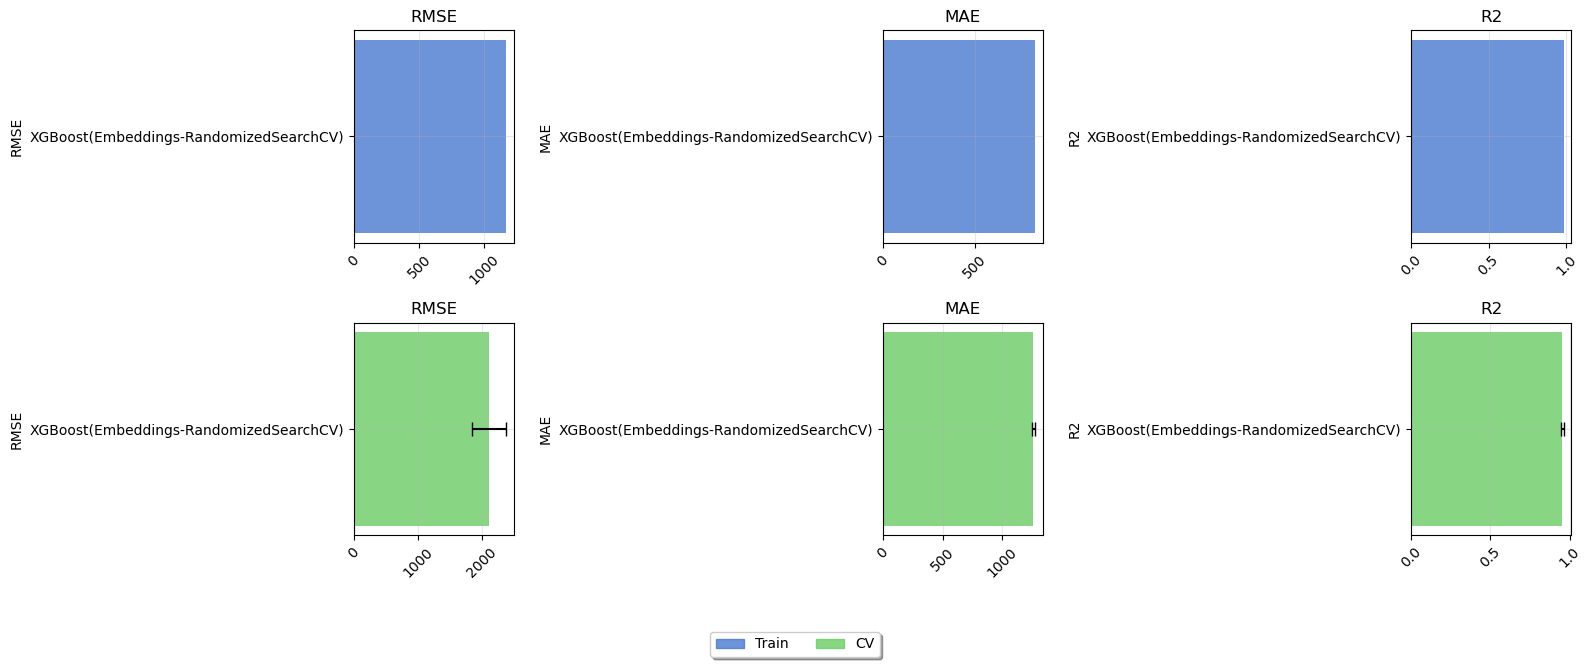

In [78]:
visualize_results(results3)

In [79]:
results3

,Model,Train_CV,RMSE,R2,MAE,CV_Train,RMSE (SD),MAE (SD),R2 (SD)
0,XGBoost(Embeddings-RandomizedSearchCV),NaN,1167.852914,0.985761,828.711631,Train,NaN,NaN,NaN
0,XGBoost(Embeddings-RandomizedSearchCV),NaN,2109.116708,0.953188,1257.447098,CV,271.228555,14.462228,0.010104


## Resultat 2:

In [80]:
X_test_processed.describe()

,mileage,tax,mpg,engineSize,age,transmission_Manual,transmission_Semi-Auto,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,...,model_emb_374,model_emb_375,model_emb_376,model_emb_377,model_emb_378,model_emb_379,model_emb_380,model_emb_381,model_emb_382,model_emb_383
count,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,...,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000,15896.000000
mean,0.002767,-0.007485,-0.003894,-0.001920,0.007967,0.378271,0.375818,0.011324,0.002139,0.423062,...,0.040321,0.005931,-0.005178,-0.019499,-0.064012,0.028392,0.044598,-0.009582,-0.005207,0.007772
std,1.018956,0.999998,0.954909,1.006100,0.989639,0.484971,0.484349,0.105812,0.046200,0.494061,...,0.042701,0.050621,0.035303,0.038255,0.026338,0.041184,0.056121,0.045027,0.034766,0.030596
min,-1.044188,-1.994525,-3.588396,-3.474039,-1.325889,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.063389,-0.090625,-0.048411,-0.097296,-0.113362,-0.078703,-0.077023,-0.106397,-0.092062,-0.073791
25%,-0.775337,0.069136,-0.547426,-0.693059,-0.846910,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.023055,-0.031908,-0.038670,-0.039754,-0.082913,-0.003053,0.007900,-0.045265,-0.028544,-0.003249
50%,-0.284377,0.399322,-0.076480,0.233934,0.111048,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.051736,-0.002706,-0.010768,-0.030687,-0.060900,0.022317,0.052842,-0.006538,-0.005207,0.008233
75%,0.466201,0.399322,0.468473,0.233934,0.590028,1.000000,1.000000,0.000000,0.000000,1.000000,...,0.060211,0.035853,0.015114,0.001424,-0.046423,0.068136,0.074788,0.032075,0.005064,0.027236
max,13.431332,7.415770,10.957127,8.020677,9.211654,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.117799,0.095291,0.102617,0.086260,0.005993,0.092649,0.146708,0.074608,0.077304,0.071900


In [81]:
# Beste Hyperparameter aus RandomizedSearchCV
best_params = {
    'subsample': 0.85,
    'reg_lambda': 1e-05,
    'reg_alpha': 1.4888314207131574,
    'n_estimators': 937,
    'min_child_weight': 3,
    'max_depth': 8,
    'learning_rate': 0.02779402880552314,
    'gamma': 4.999999999999999,
    'colsample_bytree': 0.6,
}


# Definiere das XGBoost-Modell mit den besten Hyperparametern
xgb_model_best2 = xgb.XGBRegressor(
    objective='reg:squarederror', 
    random_state=42,
    **best_params  # Füge die besten Hyperparameter hinzu
)

In [82]:
xgb_scores2 = compute_metrics(xgb_model_best2, X_p, y, scorer=scorer, model_name="XGBoost(Embeddings-BayesSearchCV)")

In [83]:
results3 = pd.concat([results3, xgb_scores2], axis=0)

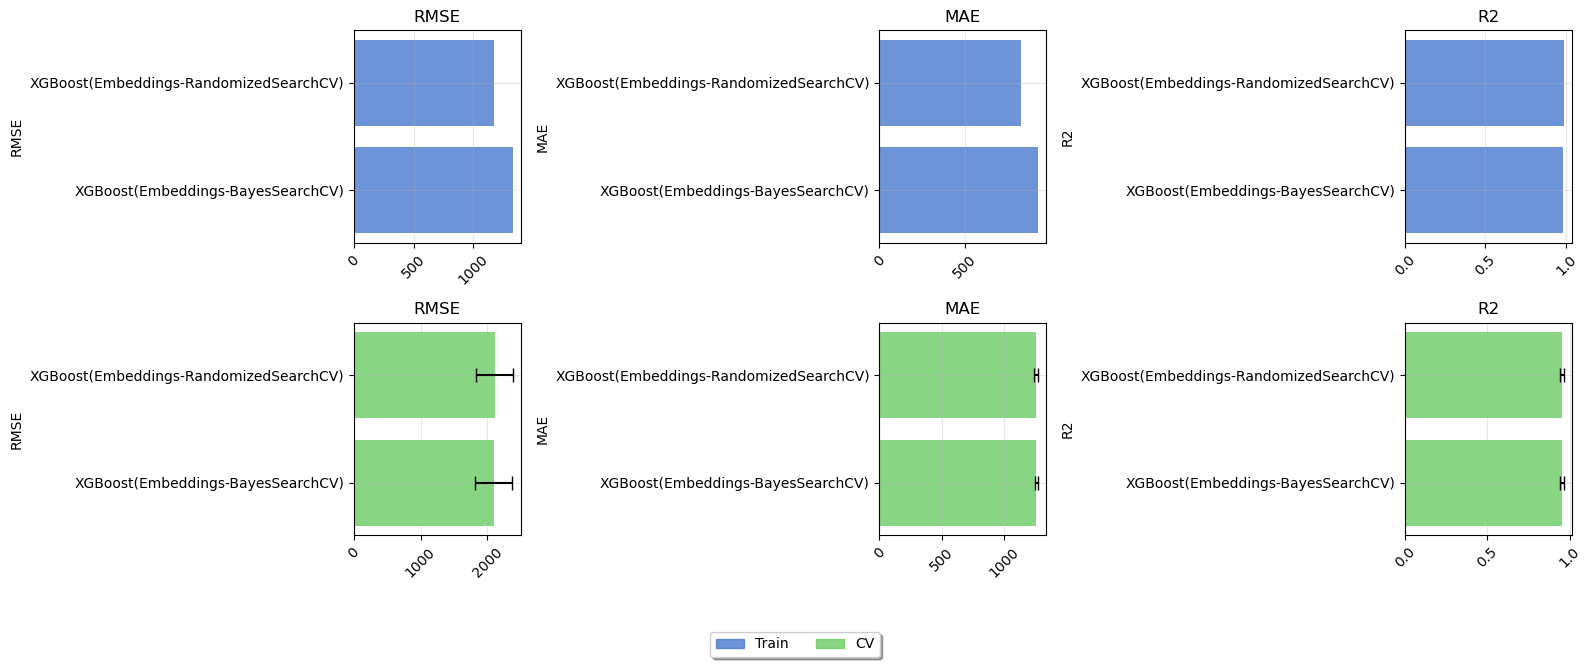

In [84]:
visualize_results(results3)

In [85]:
results3

,Model,Train_CV,RMSE,R2,MAE,CV_Train,RMSE (SD),MAE (SD),R2 (SD)
0,XGBoost(Embeddings-RandomizedSearchCV),NaN,1167.852914,0.985761,828.711631,Train,NaN,NaN,NaN
0,XGBoost(Embeddings-RandomizedSearchCV),NaN,2109.116708,0.953188,1257.447098,CV,271.228555,14.462228,0.010104
0,XGBoost(Embeddings-BayesSearchCV),NaN,1327.409737,0.981604,928.944834,Train,NaN,NaN,NaN
0,XGBoost(Embeddings-BayesSearchCV),NaN,2098.127627,0.953655,1259.736624,CV,277.841448,14.057816,0.010329


In [453]:
# Vorhersagen auf den Testdaten treffen
y_pred2 = xgb_model_best2.predict(X_test_processed)

# Optional: Ergebnisse anzeigen
print("Vorhersageergebnisse:", y_pred2)

Vorhersageergebnisse: [17386.508 21063.752 13702.15  ... 12143.17  20369.512  9651.206]


---

# Resultat 4 (mit komplexerem Embedding ohne UMAP):

In [132]:
# Beste Hyperparameter aus RandomizedSearchCV
best_params = {
    'subsample': 0.85,
    'reg_lambda': 1e-05,
    'reg_alpha': 1.4888314207131574,
    'n_estimators': 937,
    'min_child_weight': 3,
    'max_depth': 8,
    'learning_rate': 0.02779402880552314,
    'gamma': 4.999999999999999,
    'colsample_bytree': 0.6,
}


# Definiere das XGBoost-Modell mit den besten Hyperparametern
xgb_model_best4 = xgb.XGBRegressor(
    objective='reg:squarederror', 
    random_state=42,
    **best_params  # Füge die besten Hyperparameter hinzu
)

In [133]:
xgb_scores4 = compute_metrics(xgb_model_best4, X_p, y, scorer=scorer, model_name="XGBoost(Complex Embeddings - BayesSearchCV)")

In [134]:
results3 = pd.concat([results3, xgb_scores4], axis=0)

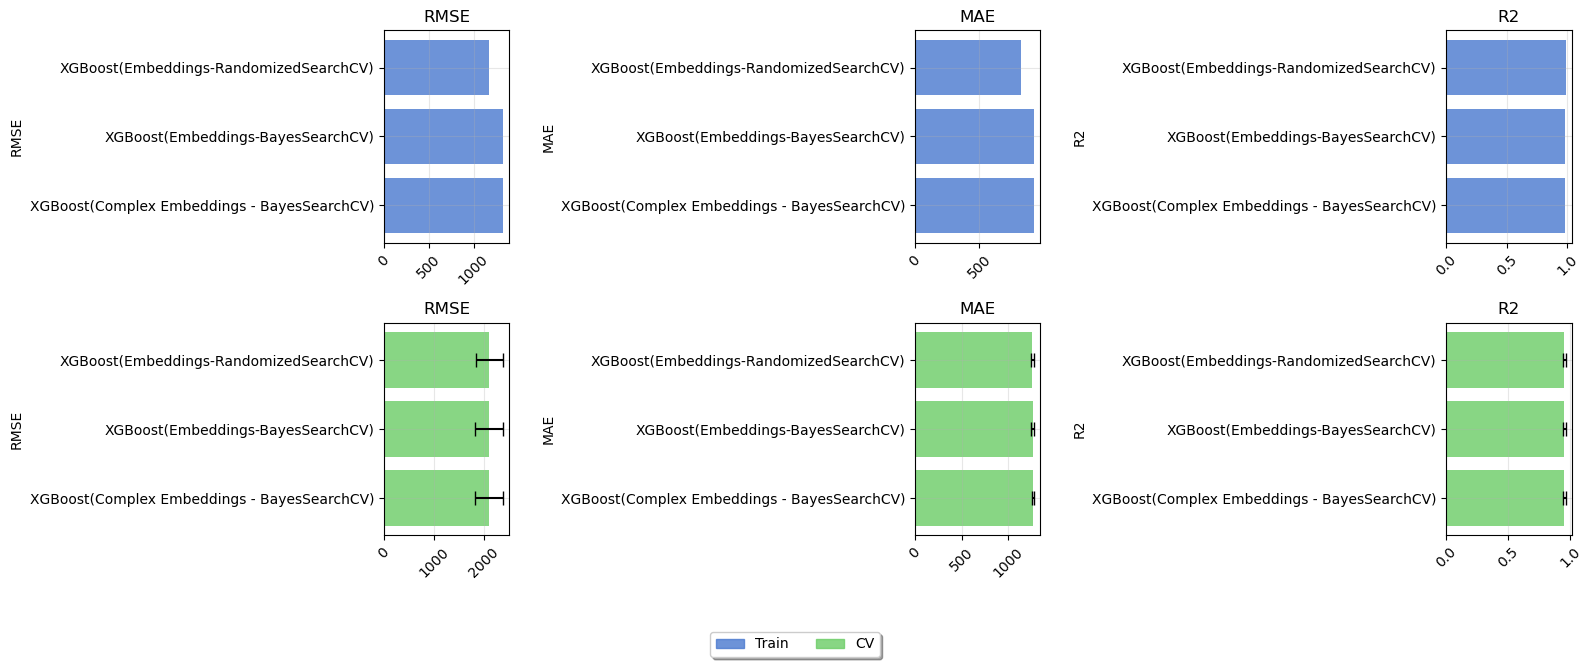

In [135]:
visualize_results(results3)

In [136]:
results3

,Model,Train_CV,RMSE,R2,MAE,CV_Train,RMSE (SD),MAE (SD),R2 (SD)
0,XGBoost(Embeddings-RandomizedSearchCV),NaN,1167.852914,0.985761,828.711631,Train,NaN,NaN,NaN
0,XGBoost(Embeddings-RandomizedSearchCV),NaN,2109.116708,0.953188,1257.447098,CV,271.228555,14.462228,0.010104
0,XGBoost(Embeddings-BayesSearchCV),NaN,1327.409737,0.981604,928.944834,Train,NaN,NaN,NaN
0,XGBoost(Embeddings-BayesSearchCV),NaN,2098.127627,0.953655,1259.736624,CV,277.841448,14.057816,0.010329
0,XGBoost(Complex Embeddings - BayesSearchCV),NaN,1330.609672,0.981515,930.470706,Train,NaN,NaN,NaN
0,XGBoost(Complex Embeddings - BayesSearchCV),NaN,2103.587882,0.953395,1263.979784,CV,281.856703,15.828304,0.010575


In [137]:
# Vorhersagen auf den Testdaten treffen
y_pred4 = xgb_model_best4.predict(X_test_processed)

# Optional: Ergebnisse anzeigen
print("Vorhersageergebnisse:", y_pred4)

Vorhersageergebnisse: [17313.04  21777.377 13511.278 ... 12085.903 20699.24   9488.712]


# Resultat 5 (mit complex Model und RandomizedSearchCV):

In [138]:
# Beste Hyperparameter aus RandomizedSearchCV
best_params = {
    'subsample': 0.85,
    'reg_lambda': 1e-05,
    'reg_alpha': 1.0703295275853675e-05,
    'n_estimators': 1000,
    'min_child_weight': 2,
    'max_depth': 8,
    'learning_rate': 0.03359235846101312,
    'gamma': 0.36227632834500056,
    'colsample_bytree': 0.6,
}



# Definiere das XGBoost-Modell mit den besten Hyperparametern
xgb_model_best5 = xgb.XGBRegressor(
    objective='reg:squarederror', 
    random_state=42,
    **best_params  # Füge die besten Hyperparameter hinzu
)

In [139]:
xgb_scores5 = compute_metrics(xgb_model_best5, X_p, y, scorer=scorer, model_name="XGBoost(Complex Embeddings - RandomizedSearchCV)")

In [140]:
results3 = pd.concat([results3, xgb_scores5], axis=0)

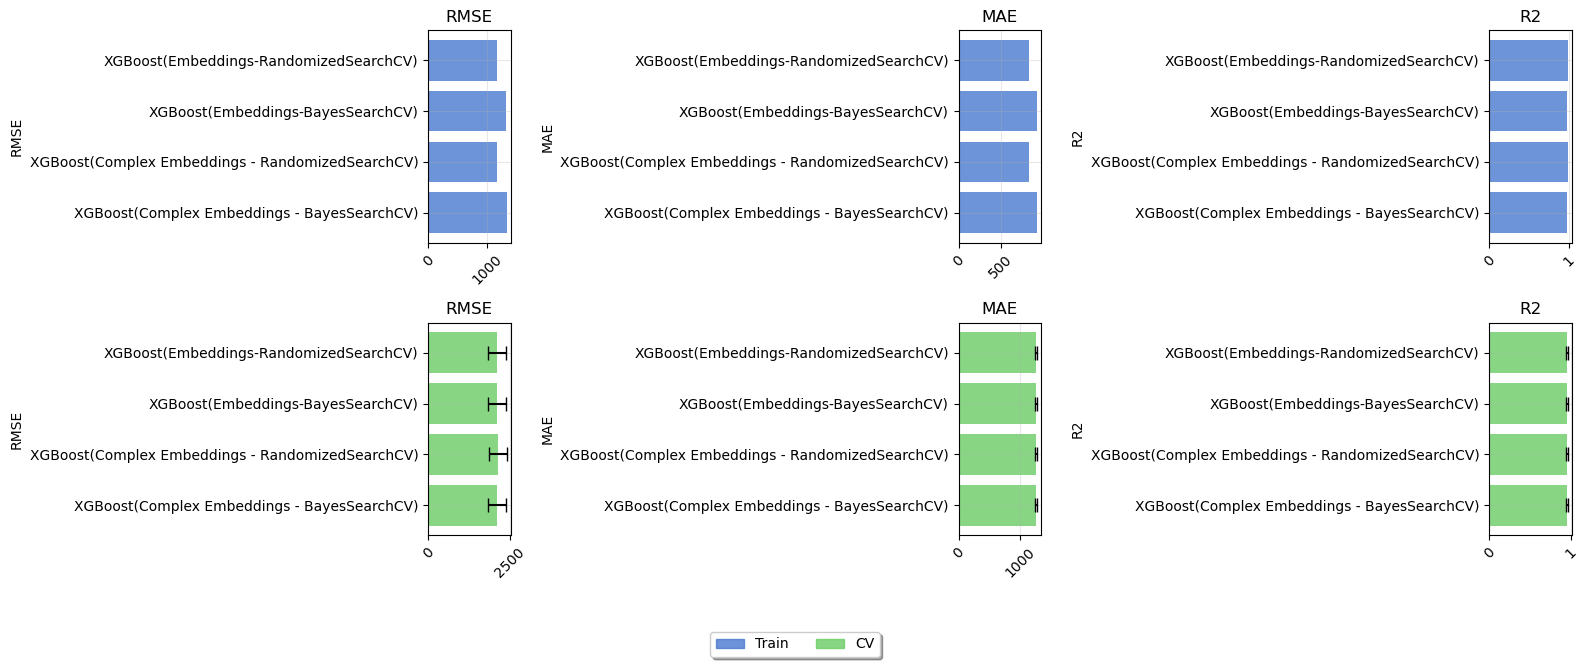

In [141]:
visualize_results(results3)

In [142]:
results3

,Model,Train_CV,RMSE,R2,MAE,CV_Train,RMSE (SD),MAE (SD),R2 (SD)
0,XGBoost(Embeddings-RandomizedSearchCV),NaN,1167.852914,0.985761,828.711631,Train,NaN,NaN,NaN
0,XGBoost(Embeddings-RandomizedSearchCV),NaN,2109.116708,0.953188,1257.447098,CV,271.228555,14.462228,0.010104
0,XGBoost(Embeddings-BayesSearchCV),NaN,1327.409737,0.981604,928.944834,Train,NaN,NaN,NaN
0,XGBoost(Embeddings-BayesSearchCV),NaN,2098.127627,0.953655,1259.736624,CV,277.841448,14.057816,0.010329
0,XGBoost(Complex Embeddings - BayesSearchCV),NaN,1330.609672,0.981515,930.470706,Train,NaN,NaN,NaN
0,XGBoost(Complex Embeddings - BayesSearchCV),NaN,2103.587882,0.953395,1263.979784,CV,281.856703,15.828304,0.010575
0,XGBoost(Complex Embeddings - RandomizedSearchCV),NaN,1167.251058,0.985775,828.137282,Train,NaN,NaN,NaN
0,XGBoost(Complex Embeddings - RandomizedSearchCV),NaN,2121.089030,0.952640,1260.045046,CV,276.554497,15.809991,0.010421


In [160]:
# Ersetze "BayesSearchCV" durch "BSCV" in der Spalte 'Model'
results3['Model'] = results3['Model'].str.replace('BayesSearchCV', 'BSCV')

# Ersetze "RandomizedSearchCV" durch "RSCV" in der Spalte 'Model'
results3['Model'] = results3['Model'].str.replace('RandomizedSearchCV', 'RSCV')

# Überprüfe das Ergebnis
results3


,Model,Train_CV,RMSE,R2,MAE,CV_Train,RMSE (SD),MAE (SD),R2 (SD)
0,XGBoost(Embeddings-RSCV),NaN,1167.852914,0.985761,828.711631,Train,NaN,NaN,NaN
0,XGBoost(Embeddings-RSCV),NaN,2109.116708,0.953188,1257.447098,CV,271.228555,14.462228,0.010104
0,XGBoost(Embeddings-BSCV),NaN,1327.409737,0.981604,928.944834,Train,NaN,NaN,NaN
0,XGBoost(Embeddings-BSCV),NaN,2098.127627,0.953655,1259.736624,CV,277.841448,14.057816,0.010329
0,XGBoost(Complex Embeddings - BSCV),NaN,1330.609672,0.981515,930.470706,Train,NaN,NaN,NaN
0,XGBoost(Complex Embeddings - BSCV),NaN,2103.587882,0.953395,1263.979784,CV,281.856703,15.828304,0.010575
0,XGBoost(Complex Embeddings - RSCV),NaN,1167.251058,0.985775,828.137282,Train,NaN,NaN,NaN
0,XGBoost(Complex Embeddings - RSCV),NaN,2121.089030,0.952640,1260.045046,CV,276.554497,15.809991,0.010421


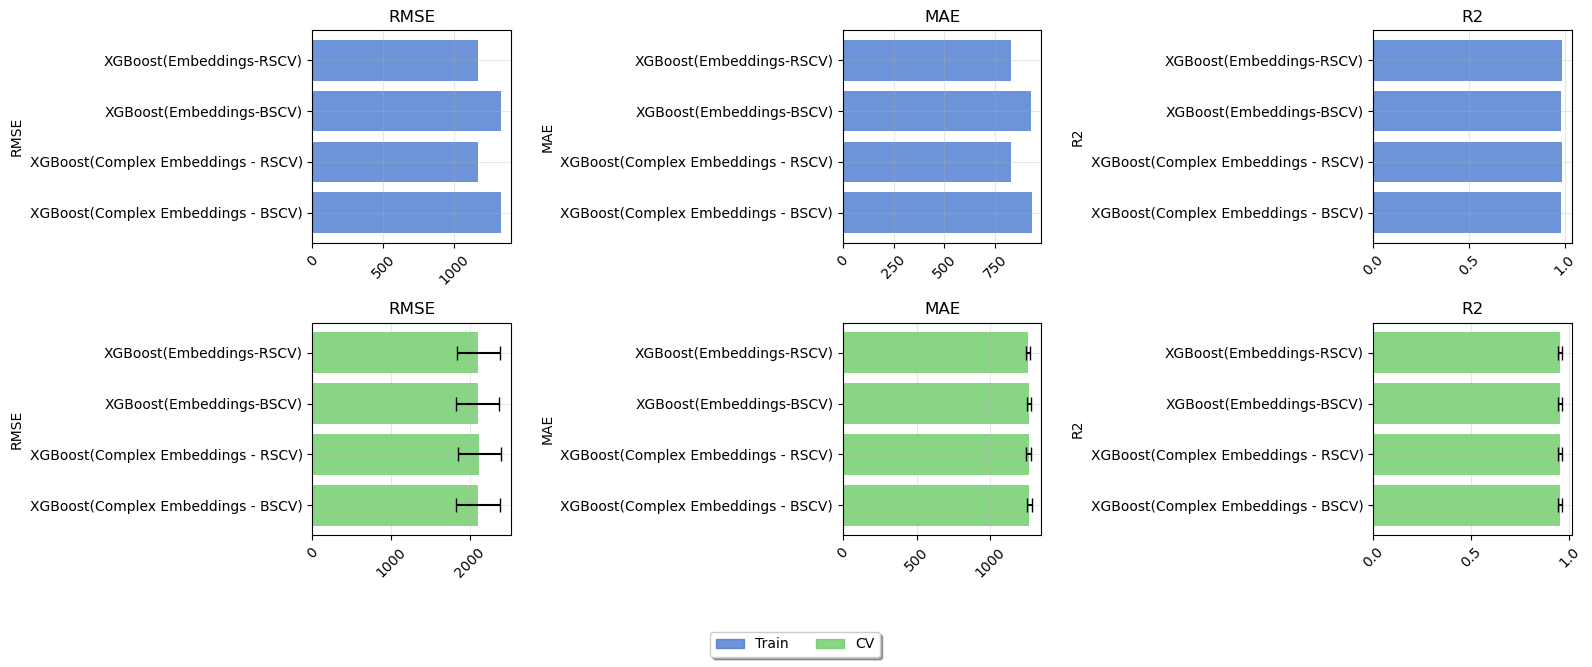

In [161]:
visualize_results(results3)

In [162]:
# Ersetze "Embeddings" durch "Emb" in der Spalte 'Model'
results3['Model'] = results3['Model'].str.replace('Embeddings', 'Emb')

# Ersetze "Complex" durch "compl" in der Spalte 'Model'
results3['Model'] = results3['Model'].str.replace('Complex', 'compl')

# Überprüfe das Ergebnis
print(results3)


                       Model  Train_CV         RMSE        R2          MAE  \
0          XGBoost(Emb-RSCV)       NaN  1167.852914  0.985761   828.711631   
0          XGBoost(Emb-RSCV)       NaN  2109.116708  0.953188  1257.447098   
0          XGBoost(Emb-BSCV)       NaN  1327.409737  0.981604   928.944834   
0          XGBoost(Emb-BSCV)       NaN  2098.127627  0.953655  1259.736624   
0  XGBoost(compl Emb - BSCV)       NaN  1330.609672  0.981515   930.470706   
0  XGBoost(compl Emb - BSCV)       NaN  2103.587882  0.953395  1263.979784   
0  XGBoost(compl Emb - RSCV)       NaN  1167.251058  0.985775   828.137282   
0  XGBoost(compl Emb - RSCV)       NaN  2121.089030  0.952640  1260.045046   

  CV_Train   RMSE (SD)   MAE (SD)   R2 (SD)  
0    Train         NaN        NaN       NaN  
0       CV  271.228555  14.462228  0.010104  
0    Train         NaN        NaN       NaN  
0       CV  277.841448  14.057816  0.010329  
0    Train         NaN        NaN       NaN  
0       CV  281.85670

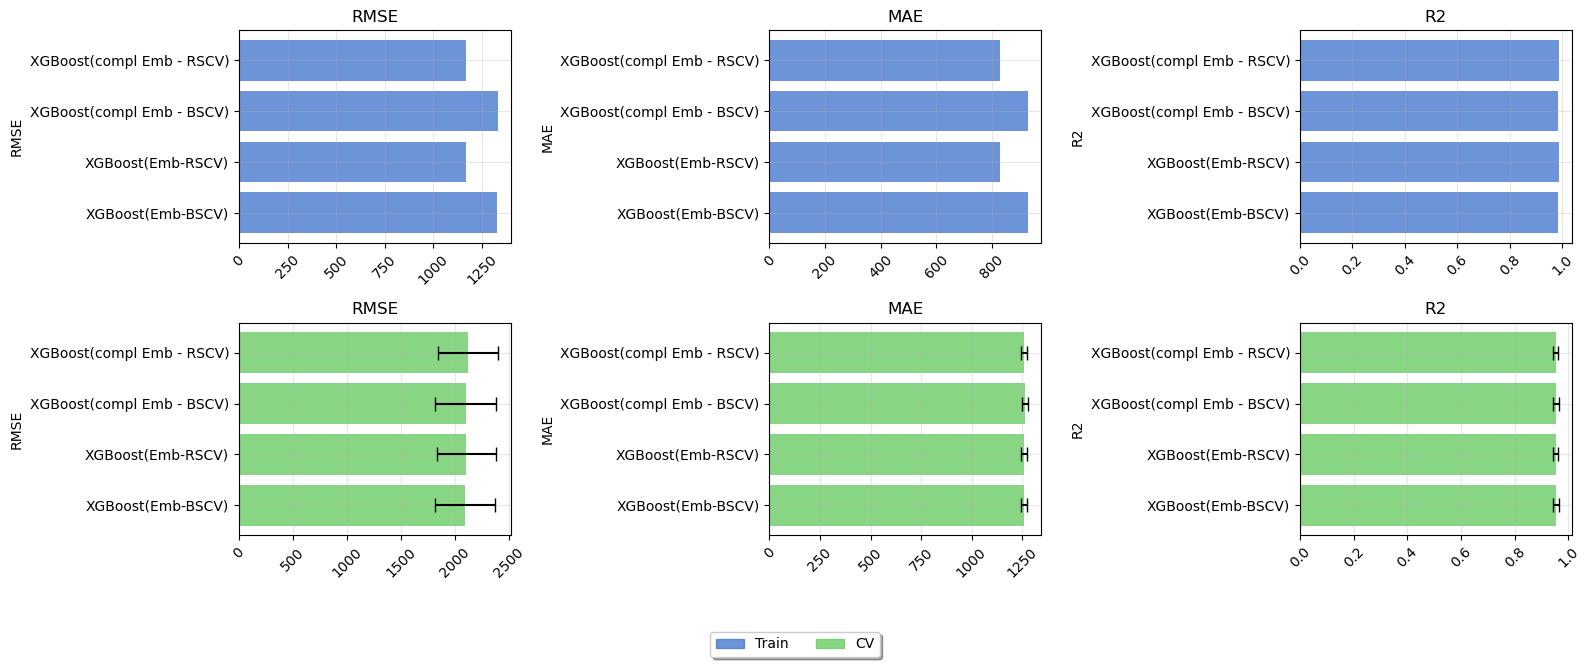

In [163]:
visualize_results(results3)

In [143]:
# Vorhersagen auf den Testdaten treffen
y_pred5 = xgb_model_best5.predict(X_test_processed)

# Optional: Ergebnisse anzeigen
print("Vorhersageergebnisse:", y_pred5)

Vorhersageergebnisse: [17464.629 21478.67  13903.292 ... 12189.481 19891.861  9574.513]


---

In [145]:
# Sort results by cross-validation MSE
cv_results = results3.loc[results3["CV_Train"] == "CV", ["Model", "RMSE", "RMSE (SD)", "MAE", "MAE (SD)", "R2", "R2 (SD)"]]
cv_results.sort_values(by="RMSE", ascending=True)

,Model,RMSE,RMSE (SD),MAE,MAE (SD),R2,R2 (SD)
0,XGBoost(Embeddings-BayesSearchCV),2098.127627,277.841448,1259.736624,14.057816,0.953655,0.010329
0,XGBoost(Complex Embeddings - BayesSearchCV),2103.587882,281.856703,1263.979784,15.828304,0.953395,0.010575
0,XGBoost(Embeddings-RandomizedSearchCV),2109.116708,271.228555,1257.447098,14.462228,0.953188,0.010104
0,XGBoost(Complex Embeddings - RandomizedSearchCV),2121.089030,276.554497,1260.045046,15.809991,0.952640,0.010421


In [1]:
# Entferne die Zeilen mit den Indizes 5 und 6
results_end = results3.drop(index=[4, 5])

# Optional: Überprüfe das Ergebnis
print(results_end)

NameError: name 'results3' is not defined

---
---

Beste Hyperparameter: 

```python

OrderedDict([(
- 'colsample_bytree', 0.70183606473409), 
- ('gamma', 0.3), 
- ('learning_rate', 0.29999999999999993), 
- ('max_delta_step', 2.0), 
- ('max_depth', 12), 
- ('min_child_weight', 5), 
- ('n_estimators', 850), 
- ('reg_alpha', 2.0), 
- ('reg_lambda', 4.205422414539256e-06), 
- ('subsample', 0.85)])
Niedrigstes RMSE: 9445.598169985267
```

# Build Model


In [ ]:
# Import Functions
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Instantiate Model
model = LinearRegression()

# Create Train Data
X = train.drop("price", axis=1)
y = train["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12)

# fit model
model.fit(X_train, y_train)

#make prediction
y_pred = model.predict(X_test)

# Evaluate Model Performance
mean_squared_error(y_test, y_pred, squared=False)

ValueError: could not convert string to float: ' Golf'

# Save Results for Submission


Make predictions on the competition data with your trained model


In [ ]:
comp_predictions= model.predict(comp_data)

In [ ]:
model_name = "TestSubmission.csv"

In [224]:
def save_submission_for_kaggle(path, model_name, comp_predictions, comp_data):
  submission_data = pd.DataFrame({"Id": comp_data["ID"], "Actual": comp_predictions})
  submission_data.to_csv(path + model_name, index=False)

In [225]:
save_submission_for_kaggle(path, model_name, comp_predictions4, comp_data)

In [ ]:
model_name = "Submission_10.csv"

In [ ]:
path= "/Assignment_3"

In [222]:
import pandas as pd
comp_data = pd.read_csv("test.csv")

In [223]:
comp_data

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,brand,ID
0,Golf,2015,Manual,40000,Petrol,205,39.8,2.0,VW,1
1,GLA Class,2017,Automatic,30112,Petrol,145,43.5,2.0,Mercedes,4
2,1 Series,2015,Semi-Auto,19168,Petrol,145,49.6,1.6,BMW,10
3,B Class,2019,Semi-Auto,14700,Petrol,145,45.6,1.3,Mercedes,13
4,A3,2010,Manual,64800,Petrol,200,40.9,1.6,Audi,16
...,...,...,...,...,...,...,...,...,...,...
15891,4 Series,2015,Automatic,73150,Diesel,160,50.4,3.0,BMW,46738
15892,Touareg,2011,Automatic,68686,Diesel,260,38.2,3.0,VW,46744
15893,A Class,2015,Manual,37883,Diesel,20,70.6,1.5,Mercedes,46746
15894,T-Roc,2020,Manual,501,Petrol,145,44.1,1.0,VW,46748


In [220]:
comp_predictions4 = y_pred6

In [221]:
comp_predictions4.shape

(15896,)

# How to get Going

- Try out other algorithms!
- Try out Cross Validation and Hyperparameter Tuning (see coding hint below)
- Try to understand why different models perform better or worse. Make Visualizations (Actual vs. Predicted Plots, Feature Importances, etc.)
- Try to make ensemble different predictions (average of multiple models
